# Init data

In [1]:
# %pip install numpy
# %pip install scipy
# %pip install astropy
# %pip install matplotlib
# %pip install pandas
# %pip install seaborn
# %pip install scienceplots
# %pip install numba
# %pip install -U "ray[default]"

In [2]:
import numpy as np
import scipy.integrate as integ
import scipy.interpolate as i2
import matplotlib.pyplot as plt
plt.rcParams.update(plt.rcParamsDefault)
from astropy import units as u
from astropy import constants as c

from shooting import *
import shootingres as shr
import shooting as sho

import scipy.optimize as o
try:
    import cPickle as pickle
except ImportError:
    import pickle
    
import seaborn as sns
sns.set_theme()
sns.set_style("white")
sns.set_style("ticks")
sns.set_style("ticks",{'axes.grid' : True})
sns.set_palette("colorblind")

import seaborn as sns
sns.set_theme()
sns.set_style("white")
sns.set_style("ticks")
sns.set_style("ticks",{'axes.grid' : True})
import scienceplots
plt.style.use('science')
f = 16

In [3]:
## SET CONSTANTS
rho = (1.0*10**19) * (2.0*1.6725*10**(-27))
mu_0 = 1.2566*10**(-6)

# Define Normalizations
r1 = 0.1

## Define OMEGA0:
bb = 10000
v0 = bb/np.sqrt(r1)
Omega0 = v0/r1

In [4]:
r1 = 0.1
r2 = 5
reso = 500
r = np.arange(1, 5, 24/reso)
q_mag = 14.75
zeros_arr = np.zeros(len(r))
zero_func = i2.CubicSpline(r, zeros_arr)
guess = 0.48434256060797676+0.020823911758309853j
VA_N = 0.578*8/10

guess = 0.12139623593331471+0.011912526084744524j
VA_N = 1*8/10
# guess = 0.10239262246216976+0.00903253109479077j
# VA_N = 0.019*8/10

VA_N = 1.157*8/10
guess = 0.09204491162436777+0.032459895655368304j
kn = 1
m = 1
k_z = kn*np.pi/(4)


Az = 0
B0 = VA_N*r1*Omega0*np.sqrt(rho*mu_0)*10000

B0 = 50
VA_N = B0/(r1*Omega0*np.sqrt(rho*mu_0)*10000)
guess = 0.10436174760424338+0.02516720144330583j



# y0 = [0.,(1.+1j)*1e-1]
# # y = integ.solve_ivp(shr.shoot_setup_krcomp_v2, [1,r2**2], y0, args=(guess,0, zero_func, zero_func, zero_func, zero_func, m,kz,B0,Az,True, 1), max_step=24./reso)
# # # print(y)
# # r = np.sqrt(y.t)
# # u = y.y[0]

# y = i.solve_ivp(sho.shoot, [1,r2**2], y0, args=(guess,m,kz, B0, Az, True, 1), max_step=24./500.)
# r = np.sqrt(y.t)
# u = y.y[0]

# # rp, rm, r0 = resonance(guessr, m, k, Az)

# ## PLOT ALL
# f=16

# elecd_str = "{:.0e}".format(0)
# print(f'u.real = {u.real[len(u.real)-1]}')
# print(f'u.imag = {u.imag[len(u.real)-1]}')
# plt.figure(figsize=(4,4))
# # plt.axvline(x=rp, color='green',ls='--', )
# # plt.axvline(x=rm, color='green',ls='--', label='Resonance')
# scale = 1000
# plt.plot(r,scale*(u/r).real, label='real')
# plt.plot(r,scale*(u/r).imag, label='imag')
# plt.plot(r,0*r, 'k--')
# plt.xlabel('$r/r_1$',fontsize=f)
# plt.ylabel(r'$\xi_r/r_1$',fontsize=f)
# plt.title(f'$m={m}$, $k={kn}k_1$,' + ' $V_{A} = ' + f'{round(VA_N,3)}r_1\Omega_0$,' '$D_\eta$ = ' + elecd_str,fontsize=f)
# plt.xlim(1,r2)
# plt.legend()
# plt.xticks(fontsize=f)
# plt.yticks(fontsize=f)
# plt.tight_layout()
# plt.show()

# LOAD AZIMUTHAL FIELD KEPLERIAN DATA

MCI 1k1

In [5]:
elecd_str = '0'
guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_guessesu_' + elecd_str + '-v5.pkl'
guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_guessesd_' + elecd_str + '-v5.pkl'
VA_u = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_VANDOWN_' + elecd_str + '-v5.pkl'
VA_d = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_VANUP_' + elecd_str + '-v5.pkl'
with open(VA_d, 'rb') as f:
    VA_l_MCI1 = pickle.load(f)    
with open(VA_u, 'rb') as f:
    VA_h_MCI1 = pickle.load(f)    
    
    
with open(guesses_str_d, 'rb') as f:
    guesses_1k1_MCI_l = pickle.load(f)    
with open(guesses_str_u, 'rb') as f:
    guesses_1k1_MCI_h = pickle.load(f)    

# VA_h_cut = []
gr_1k1_MCI_l = []
gr_1k1_MCI_h = []
for j in range(0,len(guesses_1k1_MCI_l) ):
    gr_1k1_MCI_l.append(guesses_1k1_MCI_l[j].imag)
    
for j in range(0,len(guesses_1k1_MCI_h)):
    gr_1k1_MCI_h.append(guesses_1k1_MCI_h[j].imag)   
     
freq_1k1_MCI_l = []
freq_1k1_MCI_h = []
for j in range(0,len(guesses_1k1_MCI_l) ):
    freq_1k1_MCI_l.append(guesses_1k1_MCI_l[j].real)
    
for j in range(0,len(guesses_1k1_MCI_h)):
    freq_1k1_MCI_h.append(guesses_1k1_MCI_h[j].real)    
    # VA_h_cut.append(VA_h_MRI1[j])

# VA_h_MRI1 = VA_h_cut
   

MCI 2k1

In [6]:
elecd_str = '0'
guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/MCI_2k1_guessesu_' + elecd_str + '-v5.pkl'
guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/MCI_2k1_guessesd_' + elecd_str + '-v5.pkl'
VA_u = f'Shooting-AlfvenSweep-Scaled-Data/MCI_2k1_VANDOWN_' + elecd_str + '-v5.pkl'
VA_d = f'Shooting-AlfvenSweep-Scaled-Data/MCI_2k1_VANUP_' + elecd_str + '-v5.pkl'
with open(VA_d, 'rb') as f:
    VA_l_MCI2 = pickle.load(f)    
with open(VA_u, 'rb') as f:
    VA_h_MCI2 = pickle.load(f)    
    
    
with open(guesses_str_d, 'rb') as f:
    guesses_2k1_MCI_l = pickle.load(f)    
with open(guesses_str_u, 'rb') as f:
    guesses_2k1_MCI_h = pickle.load(f)    

# VA_h_cut = []
gr_2k1_MCI_l = []
gr_2k1_MCI_h = []
for j in range(0,len(guesses_2k1_MCI_l) ):
    gr_2k1_MCI_l.append(guesses_2k1_MCI_l[j].imag)
    
for j in range(0,len(guesses_2k1_MCI_h)):
    gr_2k1_MCI_h.append(guesses_2k1_MCI_h[j].imag)   
     
freq_2k1_MCI_l = []
freq_2k1_MCI_h = []
for j in range(0,len(guesses_2k1_MCI_l) ):
    freq_2k1_MCI_l.append(guesses_2k1_MCI_l[j].real)
    
for j in range(0,len(guesses_2k1_MCI_h)):
    freq_2k1_MCI_h.append(guesses_2k1_MCI_h[j].real)    
    # VA_h_cut.append(VA_h_MRI1[j])

# VA_h_MRI1 = VA_h_cut

MCI 3k1

In [7]:
elecd_str = '0'
guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/MCI_3k1_guessesu_' + elecd_str + '-v5.pkl'
guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/MCI_3k1_guessesd_' + elecd_str + '-v5.pkl'
VA_u = f'Shooting-AlfvenSweep-Scaled-Data/MCI_3k1_VANDOWN_' + elecd_str + '-v5.pkl'
VA_d = f'Shooting-AlfvenSweep-Scaled-Data/MCI_3k1_VANUP_' + elecd_str + '-v5.pkl'
with open(VA_d, 'rb') as f:
    VA_l_MCI3 = pickle.load(f)    
with open(VA_u, 'rb') as f:
    VA_h_MCI3 = pickle.load(f)    
    
    
with open(guesses_str_d, 'rb') as f:
    guesses_3k1_MCI_l = pickle.load(f)    
with open(guesses_str_u, 'rb') as f:
    guesses_3k1_MCI_h = pickle.load(f)    

# VA_h_cut = []
gr_3k1_MCI_l = []
gr_3k1_MCI_h = []
for j in range(0,len(guesses_3k1_MCI_l) ):
    gr_3k1_MCI_l.append(guesses_3k1_MCI_l[j].imag)
    
for j in range(0,len(guesses_3k1_MCI_h)):
    gr_3k1_MCI_h.append(guesses_3k1_MCI_h[j].imag)   
     
freq_3k1_MCI_l = []
freq_3k1_MCI_h = []
for j in range(0,len(guesses_3k1_MCI_l) ):
    freq_3k1_MCI_l.append(guesses_3k1_MCI_l[j].real)
    
for j in range(0,len(guesses_3k1_MCI_h)):
    freq_3k1_MCI_h.append(guesses_3k1_MCI_h[j].real)    
    # VA_h_cut.append(VA_h_MRI1[j])

# VA_h_MRI1 = VA_h_cut

MRI 1k1

In [8]:
elecd_str = '0'
guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/MRI_1k1_guessesu_' + elecd_str + '.pkl'
guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/MRI_1k1_guessesd_' + elecd_str + '.pkl'
VA_u = f'Shooting-AlfvenSweep-Scaled-Data/MRI_1k1_VANDOWN_' + elecd_str + '.pkl'
VA_d = f'Shooting-AlfvenSweep-Scaled-Data/MRI_1k1_VANUP_' + elecd_str + '.pkl'
with open(VA_d, 'rb') as f:
    VA_l_MRI1 = pickle.load(f)    
with open(VA_u, 'rb') as f:
    VA_h_MRI1 = pickle.load(f)    
    
    
with open(guesses_str_d, 'rb') as f:
    guesses_1k1_MRI_l = pickle.load(f)    
with open(guesses_str_u, 'rb') as f:
    guesses_1k1_MRI_h = pickle.load(f)    

VA_h_cut = []
gr_1k1_MRI_l = []
gr_1k1_MRI_h = []
for j in range(0,len(guesses_1k1_MRI_l) ):
    gr_1k1_MRI_l.append(guesses_1k1_MRI_l[j].imag)
    
for j in range(0,len(guesses_1k1_MRI_h) -850):
    gr_1k1_MRI_h.append(guesses_1k1_MRI_h[j].imag)   
     
freq_1k1_MRI_l = []
freq_1k1_MRI_h = []
for j in range(0,len(guesses_1k1_MRI_l) ):
    freq_1k1_MRI_l.append(guesses_1k1_MRI_l[j].real)
    
for j in range(0,len(guesses_1k1_MRI_h) -850):
    freq_1k1_MRI_h.append(guesses_1k1_MRI_h[j].real)    
    VA_h_cut.append(VA_h_MRI1[j])

VA_h_MRI1 = VA_h_cut
   


MRI 2k1

In [9]:
elecd_str = '0'
guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/MRI_2k1_guessesu_' + elecd_str + '-v5.pkl'
guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/MRI_2k1_guessesd_' + elecd_str + '-v5.pkl'
VA_u = f'Shooting-AlfvenSweep-Scaled-Data/MRI_2k1_VANDOWN_' + elecd_str + '-v5.pkl'
VA_d = f'Shooting-AlfvenSweep-Scaled-Data/MRI_2k1_VANUP_' + elecd_str + '-v5.pkl'
with open(VA_d, 'rb') as f:
    VA_l_MRI2 = pickle.load(f)    
with open(VA_u, 'rb') as f:
    VA_h_MRI2 = pickle.load(f)    
    
    
with open(guesses_str_d, 'rb') as f:
    guesses_2k1_MRI_l = pickle.load(f)    
with open(guesses_str_u, 'rb') as f:
    guesses_2k1_MRI_h = pickle.load(f)    

# VA_h_cut = []
gr_2k1_MRI_l = []
gr_2k1_MRI_h = []
for j in range(0,len(guesses_2k1_MRI_l) ):
    gr_2k1_MRI_l.append(guesses_2k1_MRI_l[j].imag)
    
for j in range(0,len(guesses_2k1_MRI_h)):
    gr_2k1_MRI_h.append(guesses_2k1_MRI_h[j].imag)   
     
freq_2k1_MRI_l = []
freq_2k1_MRI_h = []
for j in range(0,len(guesses_2k1_MRI_l) ):
    freq_2k1_MRI_l.append(guesses_2k1_MRI_l[j].real)
    
for j in range(0,len(guesses_2k1_MRI_h)):
    freq_2k1_MRI_h.append(guesses_2k1_MRI_h[j].real)    
    # VA_h_cut.append(VA_h_MRI1[j])

# VA_h_MRI1 = VA_h_cut

MRI 3k1

In [10]:
elecd_str = '0'
guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/MRI_3k1_guessesu_' + elecd_str + '-v5.pkl'
guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/MRI_3k1_guessesd_' + elecd_str + '-v5.pkl'
VA_u = f'Shooting-AlfvenSweep-Scaled-Data/MRI_3k1_VANDOWN_' + elecd_str + '-v5.pkl'
VA_d = f'Shooting-AlfvenSweep-Scaled-Data/MRI_3k1_VANUP_' + elecd_str + '-v5.pkl'
with open(VA_d, 'rb') as f:
    VA_l_MRI3 = pickle.load(f)    
with open(VA_u, 'rb') as f:
    VA_h_MRI3 = pickle.load(f)    
    
    
with open(guesses_str_d, 'rb') as f:
    guesses_3k1_MRI_l = pickle.load(f)    
with open(guesses_str_u, 'rb') as f:
    guesses_3k1_MRI_h = pickle.load(f)    

# VA_h_cut = []
gr_3k1_MRI_l = []
gr_3k1_MRI_h = []
for j in range(0,len(guesses_3k1_MRI_l) ):
    gr_3k1_MRI_l.append(guesses_3k1_MRI_l[j].imag)
    
for j in range(0,len(guesses_3k1_MRI_h)):
    gr_3k1_MRI_h.append(guesses_3k1_MRI_h[j].imag)   
     
freq_3k1_MRI_l = []
freq_3k1_MRI_h = []
for j in range(0,len(guesses_3k1_MRI_l) ):
    freq_3k1_MRI_l.append(guesses_3k1_MRI_l[j].real)
    
for j in range(0,len(guesses_3k1_MRI_h)):
    freq_3k1_MRI_h.append(guesses_3k1_MRI_h[j].real)    
    # VA_h_cut.append(VA_h_MRI1[j])

# VA_h_MRI1 = VA_h_cut

MRI 6k1

In [11]:
elecd_str = '0'
guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/MRI_6k1_guessesu_' + elecd_str + '-kep-Az.pkl'
guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/MRI_6k1_guessesd_' + elecd_str + '-kep-Az.pkl'
VA_u = f'Shooting-AlfvenSweep-Scaled-Data/MRI_6k1_VANUP_' + elecd_str + '-kep-Az.pkl'
VA_d = f'Shooting-AlfvenSweep-Scaled-Data/MRI_6k1_VANDOWN_' + elecd_str + '-kep-Az.pkl'

with open(guesses_str_d, 'rb') as f:
    guesses_6k1_MRI_l = pickle.load(f)    
with open(guesses_str_u, 'rb') as f:
    guesses_6k1_MRI_h = pickle.load(f)   
     
with open(VA_d, 'rb') as f:
    VA_l_MRI6 = pickle.load(f)    
with open(VA_u, 'rb') as f:
    VA_h_MRI6 = pickle.load(f)  
    
gr_6k1_MRI_l = []
gr_6k1_MRI_h = []
for j in range(0,len(guesses_6k1_MRI_l) ):
    gr_6k1_MRI_l.append(guesses_6k1_MRI_l[j].imag)
    
for j in range(0,len(guesses_6k1_MRI_h)):
    gr_6k1_MRI_h.append(guesses_6k1_MRI_h[j].imag)    

freq_6k1_MRI_l = []
freq_6k1_MRI_h = []
for j in range(0,len(guesses_6k1_MRI_l) ):
    freq_6k1_MRI_l.append(guesses_6k1_MRI_l[j].real)
    
for j in range(0,len(guesses_6k1_MRI_h)):
    freq_6k1_MRI_h.append(guesses_6k1_MRI_h[j].real)    

MRI 10k1

In [12]:
elecd_str = '0'
guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/MRI_10k1_guessesu_' + elecd_str + '-kep-Az.pkl'
guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/MRI_10k1_guessesd_' + elecd_str + '-kep-Az.pkl'
VA_u = f'Shooting-AlfvenSweep-Scaled-Data/MRI_10k1_VANUP_' + elecd_str + '-kep-Az.pkl'
VA_d = f'Shooting-AlfvenSweep-Scaled-Data/MRI_10k1_VANDOWN_' + elecd_str + '-kep-Az.pkl'

with open(guesses_str_d, 'rb') as f:
    guesses_10k1_MRI_l = pickle.load(f)    
with open(guesses_str_u, 'rb') as f:
    guesses_10k1_MRI_h = pickle.load(f)    

with open(VA_d, 'rb') as f:
    VA_l_MRI10 = pickle.load(f)    
with open(VA_u, 'rb') as f:
    VA_h_MRI10 = pickle.load(f)    
    
gr_10k1_MRI_l = []
gr_10k1_MRI_h = []
for j in range(0,len(guesses_10k1_MRI_l) ):
    gr_10k1_MRI_l.append(guesses_10k1_MRI_l[j].imag)
    
for j in range(0,len(guesses_10k1_MRI_h)):
    gr_10k1_MRI_h.append(guesses_10k1_MRI_h[j].imag)    

freq_10k1_MRI_l = []
freq_10k1_MRI_h = []
for j in range(0,len(guesses_10k1_MRI_l) ):
    freq_10k1_MRI_l.append(guesses_10k1_MRI_l[j].real)
    
for j in range(0,len(guesses_10k1_MRI_h)):
    freq_10k1_MRI_h.append(guesses_10k1_MRI_h[j].real)    


MRI 20k1

In [13]:
elecd_str = '0'
guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/MRI_20k1_guessesu_' + elecd_str + '-kep-Az.pkl'
guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/MRI_20k1_guessesd_' + elecd_str + '-kep-Az.pkl'
VA_u = f'Shooting-AlfvenSweep-Scaled-Data/MRI_20k1_VANUP_' + elecd_str + '-kep-Az.pkl'
VA_d = f'Shooting-AlfvenSweep-Scaled-Data/MRI_20k1_VANDOWN_' + elecd_str + '-kep-Az.pkl'

with open(guesses_str_d, 'rb') as f:
    guesses_20k1_MRI_l = pickle.load(f)    
with open(guesses_str_u, 'rb') as f:
    guesses_20k1_MRI_h = pickle.load(f)    

gr_20k1_MRI_l = []
gr_20k1_MRI_h = []
for j in range(0,len(guesses_20k1_MRI_l) ):
    gr_20k1_MRI_l.append(guesses_20k1_MRI_l[j].imag)   
for j in range(0,len(guesses_20k1_MRI_h) ):
    gr_20k1_MRI_h.append(guesses_20k1_MRI_h[j].imag)    

freq_20k1_MRI_l = []
freq_20k1_MRI_h = []
for j in range(0,len(guesses_20k1_MRI_l) ):
    freq_20k1_MRI_l.append(guesses_20k1_MRI_l[j].real)   
for j in range(0,len(guesses_20k1_MRI_h) ):
    freq_20k1_MRI_h.append(guesses_20k1_MRI_h[j].real)    
    
    
with open(VA_d, 'rb') as f:
    VA_l_MRI20 = pickle.load(f)    
with open(VA_u, 'rb') as f:
    VA_h_MRI20 = pickle.load(f)   

# Data Match

Data Match Both

<>:26: SyntaxWarning: invalid escape sequence '\O'
<>:26: SyntaxWarning: invalid escape sequence '\O'
C:\Users\Alex\AppData\Local\Temp\ipykernel_207076\2117233632.py:26: SyntaxWarning: invalid escape sequence '\O'
  plt.xlabel('$V_A/(r_1 \Omega_0)$',fontsize=12)


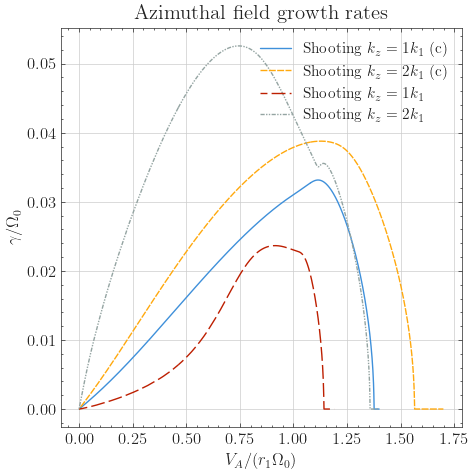

In [14]:
plt.figure(figsize=(5,5))
color_arr = ['#3F90DA', '#FFA90E', '#BD1F01', '#94A4A2', '#832DB6', '#A96B59', '#E76300', '#B9AC70', '#92DADD']

plt.plot(VA_h_MCI1,gr_1k1_MCI_l, color = color_arr[0], label =f'Shooting $k_z = 1k_1$ (c)')
plt.plot(VA_l_MCI1,gr_1k1_MCI_h, color = color_arr[0])    

plt.plot(VA_h_MCI2,gr_2k1_MCI_l, color = color_arr[1], label =f'Shooting $k_z = 2k_1$ (c)', linestyle = (0, (5, 1)))
plt.plot(VA_l_MCI2,gr_2k1_MCI_h, color = color_arr[1], linestyle =  (0, (5, 1)))

plt.plot(VA_l_MRI1,gr_1k1_MRI_l, color = color_arr[2], label =f'Shooting $k_z = 1k_1$', linestyle = (5, (10, 3)))
plt.plot(VA_h_MRI1,gr_1k1_MRI_h, color = color_arr[2], linestyle = (5, (10, 3)))    

plt.plot(VA_h_MRI2,gr_2k1_MRI_l, color = color_arr[3], label =f'Shooting $k_z = 2k_1$', linestyle = (0, (3, 1, 1, 1, 1, 1)))
plt.plot(VA_l_MRI2,gr_2k1_MRI_h, color = color_arr[3], linestyle = (0, (3, 1, 1, 1, 1, 1)))

# plt.plot(VA_l_MRI6,gr_6k1_MRI_l, color = color_arr[4], label =f'Shooting $k_z = 6k_1$', linestyle = '--')
# plt.plot(VA_h_MRI6,gr_6k1_MRI_h, color = color_arr[4], linestyle = '--')    

# plt.plot(VA_l_MRI10,gr_10k1_MRI_l, color = color_arr[5], label =f'Shooting $k_z = 10k_1$', linestyle = '-.')
# plt.plot(VA_h_MRI10,gr_10k1_MRI_h, color = color_arr[5], linestyle = '-.')    

# plt.plot(VA_l_MRI20,gr_20k1_MRI_l, color = color_arr[6], label =f'Shooting $k_z = 20k_1$', linestyle = ':')  
# plt.plot(VA_h_MRI20,gr_20k1_MRI_h, color = color_arr[6], linestyle = ':')  


plt.xlabel('$V_A/(r_1 \Omega_0)$',fontsize=12)
plt.ylabel(r'$\gamma/\Omega_0$',fontsize=12)
plt.title(f'Azimuthal field growth rates',fontsize=15)
# plt.xlim(0,0.7)
# plt.ylim(0,0.4)
plt.legend()
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
# plt.savefig('GRvsAlfvenSpeed-Az-w-v3.png', bbox_inches='tight')
plt.show()
plt.close()


<>:26: SyntaxWarning: invalid escape sequence '\O'
<>:26: SyntaxWarning: invalid escape sequence '\O'
C:\Users\Alex\AppData\Local\Temp\ipykernel_207076\3924542070.py:26: SyntaxWarning: invalid escape sequence '\O'
  plt.xlabel('$V_A/(r_1 \Omega_0)$',fontsize=12)


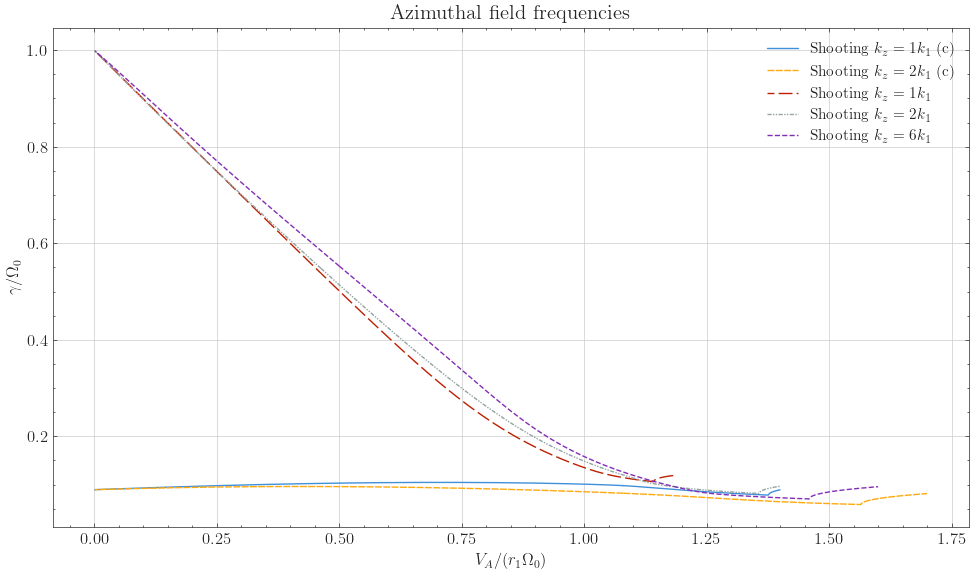

In [15]:
plt.figure(figsize=(10,6))
color_arr = ['#3F90DA', '#FFA90E', '#BD1F01', '#94A4A2', '#832DB6', '#A96B59', '#E76300', '#B9AC70', '#92DADD']

plt.plot(VA_h_MCI1,freq_1k1_MCI_l, color = color_arr[0], label =f'Shooting $k_z = 1k_1$ (c)')
plt.plot(VA_l_MCI1,freq_1k1_MCI_h, color = color_arr[0])    

plt.plot(VA_h_MCI2,freq_2k1_MCI_l, color = color_arr[1], label =f'Shooting $k_z = 2k_1$ (c)', linestyle = (0, (5, 1)))
plt.plot(VA_l_MCI2,freq_2k1_MCI_h, color = color_arr[1], linestyle =  (0, (5, 1)))

plt.plot(VA_l_MRI1,freq_1k1_MRI_l, color = color_arr[2], label =f'Shooting $k_z = 1k_1$', linestyle = (5, (10, 3)))
plt.plot(VA_h_MRI1,freq_1k1_MRI_h, color = color_arr[2], linestyle = (5, (10, 3)))    

plt.plot(VA_h_MRI2,freq_2k1_MRI_l, color = color_arr[3], label =f'Shooting $k_z = 2k_1$', linestyle = (0, (3, 1, 1, 1, 1, 1)))
plt.plot(VA_l_MRI2,freq_2k1_MRI_h, color = color_arr[3], linestyle = (0, (3, 1, 1, 1, 1, 1)))

plt.plot(VA_l_MRI6,freq_6k1_MRI_l, color = color_arr[4], label =f'Shooting $k_z = 6k_1$', linestyle = '--')
plt.plot(VA_h_MRI6,freq_6k1_MRI_h, color = color_arr[4], linestyle = '--')    

# plt.plot(VA_l_MRI10,freq_10k1_MRI_l, color = color_arr[5], label =f'Shooting $k_z = 10k_1$', linestyle = '-.')
# plt.plot(VA_h_MRI10,freq_10k1_MRI_h, color = color_arr[5], linestyle = '-.')    

# plt.plot(VA_l_MRI20, freq_20k1_MRI_l, color = color_arr[6], label =f'Shooting $k_z = 20k_1$', linestyle = ':')  
# plt.plot(VA_h_MRI20, freq_20k1_MRI_h, color = color_arr[6], linestyle = ':')  


plt.xlabel('$V_A/(r_1 \Omega_0)$',fontsize=12)
plt.ylabel(r'$\gamma/\Omega_0$',fontsize=12)
plt.title(f'Azimuthal field frequencies',fontsize=15)
# plt.xlim(0,0.7)
# plt.ylim(0,0.4)
plt.legend()
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
# plt.savefig('FreqvsAlfvenSpeed-Az-w-v3.png', bbox_inches='tight')
plt.show()
plt.close()

[array([44016.9 , 75370.2 , 85609.5 , 77029.5 , 50007.  , 28348.8 ,
       10148.7 ,  8849.72,     0.  ]), array([28334.8 , 57125.3 , 67360.8 , 61718.3 , 42576.1 , 25225.8 ,
       10339.7 ,  8520.59,     0.  ]), array([19181.1 , 46733.3 , 57130.9 , 53070.  , 37846.  , 23233.5 ,
       10378.7 ,  8737.85,     0.  ]), array([ 8262.29, 34777.3 , 45215.5 , 43300.4 , 32054.6 , 20705.8 ,
       10362.  ,  8353.78,     0.  ]), array([    0.  , 16046.7 , 26877.8 , 28089.2 , 22632.4 ,  9544.  ,
       10150.5 ,  8098.38,     0.  ]), array([   0.  ,    0.  , 2088.13, 4607.29, 6674.49, 8632.65, 9701.79,
       6897.13,    0.  ]), array([   0.   ,    0.   ,    0.   ,    0.   ,  695.382, 3878.04 ,
       4383.83 ,    0.   ,    0.   ]), array([0., 0., 0., 0., 0., 0., 0., 0., 0.])]


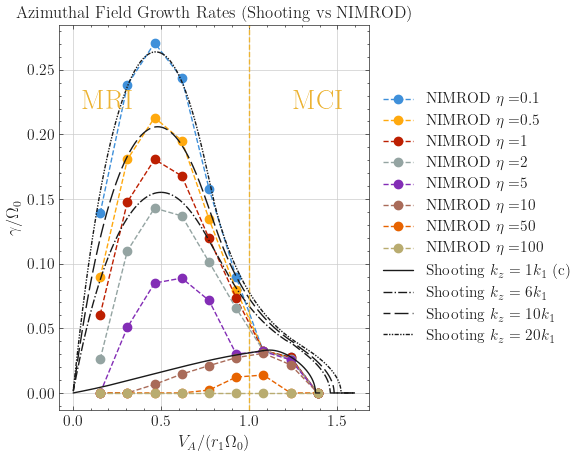

In [16]:
# %%
smrm = 1/2.0510130839719898e-07/10000/25298.2
# smrm=1
W0 = 252982
# Bs = np.asarray([   0 ,    5 ,   10 ,   15 ,   20 ,   25 ,   30 ,   35 ,   40 ,   45 ,   50 ,   55 ,   60 ,   65 ,   70 ,   75 ,   80 ])*smrm
Bs = np.asarray([   0 ,    5 ,   10 ,   15 ,   20 ,   25 ,   30 ,   35 ,   40 ,   45 ,   50 ,   55 ,   60 ,   65 ,   70 ,   75 ,   80 ])/(r1*Omega0*np.sqrt(rho*mu_0)*10000)

gs = [   0 ,    0 ,1.02e4,2.24e4,2.99e4,3.32e4,3.28e4,2.93e4,2.40e4,1.85e4,0.76e4,0.82e4,0.80e4,0.61e4,0.25e4,    0 ,    0 ]

### IMPORT MY DATA
r1_AR1 = 0.1
r2_AR1 = 0.5

## Get Alfven via input data
magB = [10, 20, 30, 40, 50, 60, 70, 80, 90]
vA = magB/np.sqrt(rho*mu_0)/10000

## AR1 Data
eta = ['0.1', '0.5', '1', '2', '5']
eta = ['0.1', '0.5', '1', '2', '5', '10', '50', '100']

# gr_10g = [44016.9, 28334.8, 19181.1,8262.29, 0] ## WAITING ON 10 ETA 5
# gr_20g = [75370.2, 57125.3, 46733.3,34777.3, 16046.7]
# gr_30g = [85609.5, 67360.8, 57130.9,45215.5, 26877.8]
# gr_40g = [77029.5, 61718.3, 53070,43300.4, 28089.2]
# gr_50g = [50007, 42576.1, 37846,32054.6, 22632.4]
# gr_60g = [28348.8, 25225.8, 23233.5,20705.8, 9544]
# gr_70g = [10148.7, 10339.7, 10378.7,10362, 10150.5] ### OTHER ETA0.1 is 18002.2
# gr_80g = [8849.72, 8520.59, 8737.85,8353.78, 8098.38]
# # gr_90g = [10127.7, 9613.43, 9315.53,8896.36, 9541.62]

# gr_10g = [44016.9, 28334.8, 19181.1,8262.29, 0, 0, 0, 0] ## WAITING ON 10 ETA 5
# gr_20g = [75370.2, 57125.3, 46733.3,34777.3, 16046.7, 0, 0,0 ]
# gr_30g = [85609.5, 67360.8, 57130.9,45215.5, 26877.8, 3334.81, 0,0]
# gr_40g = [77029.5, 61718.3, 53070,43300.4, 28089.2, 14844.2, 0,0]
# gr_50g = [50007, 42576.1, 37846,32054.6, 22632.4, 14041.2, 695.382, 0]
# gr_60g = [28348.8, 25225.8, 23233.5,20705.8, 9544, 8272.74, 3878.04, 0]
# gr_70g = [10148.7, 10339.7, 10378.7,10362, 10150.5, 9703.32, 4383.83, 0] ### OTHER ETA0.1 is 18002.2
# gr_80g = [8849.72, 8520.59, 8737.85,8353.78, 8098.38, 6852.25, 0, 0]
# gr_90g = [10127.7, 9613.43, 9315.53,8896.36, 9541.62, 5301.02, 0, 0]

### REVISION 3 WITH DTMS DATA
gr_10g = [44016.9, 28334.8, 19181.1,8262.29, 0, 0, 0, 0] ## WAITING ON 10 ETA 5
gr_20g = [75370.2, 57125.3, 46733.3,34777.3, 16046.7, 0, 0,0 ]
gr_30g = [85609.5, 67360.8, 57130.9,45215.5, 26877.8, 2088.13, 0,0]
gr_40g = [77029.5, 61718.3, 53070,43300.4, 28089.2, 4607.29, 0,0]
gr_50g = [50007, 42576.1, 37846,32054.6, 22632.4, 6674.49, 695.382, 0]
gr_60g = [28348.8, 25225.8, 23233.5,20705.8, 9544, 8632.65, 3878.04, 0]
gr_70g = [10148.7, 10339.7, 10378.7,10362, 10150.5, 9701.79, 4383.83, 0] ### OTHER ETA0.1 is 18002.2
gr_80g = [8849.72, 8520.59, 8737.85,8353.78, 8098.38, 6897.13, 0, 0]
# gr_90g = [10127.7, 9613.43, 9315.53,8896.36, 9541.62, 0, 0, 0]
gr_90g = [0, 0,0,0, 0, 0, 0, 0]

magB = [10, 20, 30, 40, 50, 60, 70, 80,90]
vA = magB/np.sqrt(rho*mu_0)/10000

gr_tot = [gr_10g, gr_20g, gr_30g, gr_40g, gr_50g, gr_60g, gr_70g, gr_80g,gr_90g]

etaplot_AR1 = []
for i in range(0, len(eta)):
    etai = np.zeros(len(gr_tot))
    for j in range(0, len(gr_tot)):
        etai[j] = gr_tot[j][i]
    etaplot_AR1.append(etai)

# fig = plt.figure()
fig = plt.figure(figsize=(5,5))
ax = plt.subplot(111)

## Now compare different resisitivites versus the shooting curvature mode.
## PLOT SHOOTING DATA
# color_arr = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'navy', 'mediumvioletred', 'cadetblue', 'mediumseagreen']
# color_arr = [[63,144,218], [(255,169,14)], [(189, 31, 1)], [(148, 164, 162)], [(131, 45, 182)], [(169, 107, 89)], [(231, 99, 0)], [(185, 172, 112)], [(146, 218, 221)]]
color_arr = ['#3F90DA', '#FFA90E', '#BD1F01', '#94A4A2', '#832DB6', '#A96B59', '#E76300', '#B9AC70', '#92DADD']

for i in range(0, len(etaplot_AR1)):
    ## Note 8/10 because of scaling w/ bb of other sims
    plt.plot(vA/(r1_AR1*Omega0), etaplot_AR1[i]/(Omega0), 'o', linestyle = '--', label=r'NIMROD $\eta =$' + str(eta[i]), color = color_arr[i])
## PLOT SHOOTING DATA

print(etaplot_AR1)
# color_arr = ['dodgerblue', 'mediumorchid', 'midnightblue', 'springgreen', 'tomato', 'k']

plt.plot(VA_h_MCI1,gr_1k1_MCI_l, color = 'k', label=r'Shooting $k_z = 1k_1$ (c)')
plt.plot(VA_l_MCI1,gr_1k1_MCI_h, color = 'k')

# plt.plot(VA_l_MRI1,gr_1k1_MRI_l, label=r'Shooting $k_z = 1k_1$', color = 'k', linestyle = ':')
# plt.plot(VA_h_MRI1,gr_1k1_MRI_h, color = 'k', linestyle = ':')

# plt.plot(VA_l_MRI1,gr_1k1_MRI_l, label=r'Shooting $k_z = 1k_1$', color = 'k')
# plt.plot(VA_h_MRI1,gr_1k1_MRI_h, color = 'k')


plt.plot(VA_l_MRI6,gr_6k1_MRI_l, label=r'Shooting $k_z = 6k_1$', color = 'k', linestyle = '-.')
plt.plot(VA_h_MRI6,gr_6k1_MRI_h, color = 'k', linestyle = '-.')

plt.plot(VA_l_MRI10,gr_10k1_MRI_l, label=r'Shooting $k_z = 10k_1$', color = 'k', linestyle = (5, (10, 3)))
plt.plot(VA_h_MRI10,gr_10k1_MRI_h, color = 'k', linestyle = (5, (10, 3)))

# plt.plot(VA_l_MRI16,gr_16k1_MRI_l, label=r'Shooting $k_z = 16k_1$', color = 'k',linestyle = (0, (3, 1, 1, 1, 1, 1)))
# plt.plot(VA_h_MRI16,gr_16k1_MRI_h, color = 'k', linestyle = (0, (3, 1, 1, 1, 1, 1)))

plt.plot(VA_l_MRI20,gr_20k1_MRI_l, label=r'Shooting $k_z = 20k_1$', color = 'k',linestyle = (0, (3, 1, 1, 1, 1, 1)))
plt.plot(VA_h_MRI20,gr_20k1_MRI_h, color = 'k', linestyle = (0, (3, 1, 1, 1, 1, 1)))

# plt.plot(VA_l_MRI20,gr_20k1_MRI_l, label=r'Shooting $k_z = 20k_1$', color = 'k',linestyle = ':')
# plt.plot(VA_h_MRI20,gr_20k1_MRI_h, color = 'k', linestyle = ':')

VA_shoot = [1.157*8/10] ## ETA0.1
ETAp1 = [0.02283895391150039]
ETAp5 = [0.01718854743963384]
ETA1 = [0.01717910905775954]
ETA2 = [0.018524447015573035]
ETA5 = [0.020554535400139143]
plt.axvline(x=1, linestyle = '--', color = '#ecb333')
plt.text(1.3-0.05, 0.22, 'MCI', fontsize=20, color = '#ecb333')
plt.text(.05, 0.22, 'MRI', fontsize=20, color = '#ecb333')
# plt.plot(VA_shoot, ETAp1, 'o', label = 'Shooting $\eta = 0.1$')
# plt.plot(VA_shoot, ETAp5,  'o', label = 'Shooting $\eta = 0.5$')
# plt.plot(VA_shoot, ETA1,  'o', label = 'Shooting $\eta = 1$')
# plt.plot(VA_shoot, ETA2, 'o',  label = 'Shooting $\eta = 2$')
# plt.plot(VA_shoot, ETA5, 'o',  label = 'Shooting $\eta = 5$')
plt.plot()
plt.xlabel(r'${V_A}/(r_1\Omega_0)$')
plt.ylabel(r'$\gamma/\Omega_0$')
# plt.ylim(-0.01, 0.3)
# plt.legend(frameon=False)
plt.title('Azimuthal Field Growth Rates (Shooting vs NIMROD)')
# plt.savefig('plots/growthshooting_diffETA_AR1_curv.pdf')

box = ax.get_position()
ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])

# Put a legend to the right of the current axis
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
# ax.legend()
# plt.savefig('GRvsAlfvenSpeed-NIMROD-w.png', bbox_inches='tight')

plt.show()
plt.close()

MATCH WITH MCI 2022

<>:4: SyntaxWarning: invalid escape sequence '\;'
<>:5: SyntaxWarning: invalid escape sequence '\m'
<>:4: SyntaxWarning: invalid escape sequence '\;'
<>:5: SyntaxWarning: invalid escape sequence '\m'
C:\Users\Alex\AppData\Local\Temp\ipykernel_207076\3148061812.py:4: SyntaxWarning: invalid escape sequence '\;'
  plt.plot(Bs/(8/10),np.asarray(gs)/Omega0/(8/10),'o', color = 'r', label='NIMROD $(2022) \; (\mathrm{Rm} = 1581)$', markeredgecolor='black', markeredgewidth = 0.75)
C:\Users\Alex\AppData\Local\Temp\ipykernel_207076\3148061812.py:5: SyntaxWarning: invalid escape sequence '\m'
  plt.plot(vA/(r1_AR1*Omega0), etaplot_AR1[3]/(Omega0), 'o', label='NIMROD AR1 $(\mathrm{Rm} = 1581)$', markeredgecolor='black', markeredgewidth = 0.75)


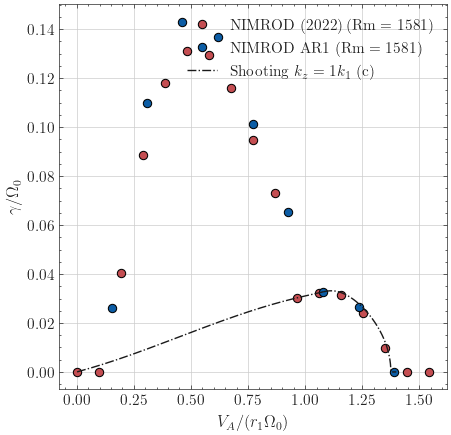

In [17]:
# ## PLOT RESIS SHOOTING DATA

plt.figure(figsize=(5,5))
plt.plot(Bs/(8/10),np.asarray(gs)/Omega0/(8/10),'o', color = 'r', label='NIMROD $(2022) \; (\mathrm{Rm} = 1581)$', markeredgecolor='black', markeredgewidth = 0.75)  
plt.plot(vA/(r1_AR1*Omega0), etaplot_AR1[3]/(Omega0), 'o', label='NIMROD AR1 $(\mathrm{Rm} = 1581)$', markeredgecolor='black', markeredgewidth = 0.75)  
plt.plot(VA_h_MCI1,gr_1k1_MCI_l, color = 'k', label=r'Shooting $k_z = 1k_1$ (c)', linestyle = '-.')
plt.plot(VA_l_MCI1,gr_1k1_MCI_h, color = 'k', linestyle = '-.')


plt.xlabel(r'${V_A}/(r_1\Omega_0)$')
plt.ylabel(r'$\gamma/\Omega_0$')
plt.legend(loc = 'upper right')
# plt.title('Shooting method curvature mode growth rates vs NIMROD points')
plt.savefig('GRvs2022p-w.png', bbox_inches='tight', dpi = 400)
plt.savefig('GRvs2022p-w.svg', bbox_inches='tight', format = 'svg')

# plt.savefig('plots/growthshooting_curv.pdf')
plt.show()
plt.close()

# Load Resistive data

qmag4

In [18]:
elecd_str = '50'


guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_guessesu_' + elecd_str + '-kep-Az-res-divr-q2mag16.pkl'
guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_guessesd_' + elecd_str + '-kep-Az-res-divr-q2mag16.pkl'
VA_u = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_VANUP_' + elecd_str + '-kep-Az-res-divr-q2mag16.pkl'
VA_d = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_VANDOWN_' + elecd_str + '-kep-Az-res-divr-q2mag16.pkl'

with open(guesses_str_d, 'rb') as f:
    guesses_1k1_MCI_l = pickle.load(f)    
with open(guesses_str_u, 'rb') as f:
    guesses_1k1_MCI_h = pickle.load(f)    

with open(VA_d, 'rb') as f:
    VA_l_MCI1_Az_ETA50_divr_q2mag16 = pickle.load(f)    
with open(VA_u, 'rb') as f:
    VA_h_MCI1_Az_ETA50_divr_q2mag16 = pickle.load(f)   
    
gr_1k1_MCI_l_Az_ETA50_divr_q2mag16= []
gr_1k1_MCI_h_Az_ETA50_divr_q2mag16 = []
for j in range(0,len(guesses_1k1_MCI_l)):
    gr_1k1_MCI_l_Az_ETA50_divr_q2mag16.append(guesses_1k1_MCI_l[j].imag)
for j in range(0,len(guesses_1k1_MCI_h) ):
    gr_1k1_MCI_h_Az_ETA50_divr_q2mag16.append(guesses_1k1_MCI_h[j].imag)    
freq_1k1_MCI_l_Az_ETA50_divr_q2mag16 = []
freq_1k1_MCI_h_Az_ETA50_divr_q2mag16 = []
for j in range(0,len(guesses_1k1_MCI_l)):
    freq_1k1_MCI_l_Az_ETA50_divr_q2mag16.append(guesses_1k1_MCI_l[j].real)
    
for j in range(0,len(guesses_1k1_MCI_h)):
    freq_1k1_MCI_h_Az_ETA50_divr_q2mag16.append(guesses_1k1_MCI_h[j].real)    

qmag3

In [19]:
elecd_str = '1'


guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_guessesu_' + elecd_str + '-kep-Az-res-divr-q2mag9.pkl'
guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_guessesd_' + elecd_str + '-kep-Az-res-divr-q2mag9.pkl'
VA_u = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_VANUP_' + elecd_str + '-kep-Az-res-divr-q2mag9.pkl'
VA_d = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_VANDOWN_' + elecd_str + '-kep-Az-res-divr-q2mag9.pkl'

with open(guesses_str_d, 'rb') as f:
    guesses_1k1_MCI_l = pickle.load(f)    
with open(guesses_str_u, 'rb') as f:
    guesses_1k1_MCI_h = pickle.load(f)    

with open(VA_d, 'rb') as f:
    VA_l_MCI1_Az_ETA1_divr_q2mag9 = pickle.load(f)    
with open(VA_u, 'rb') as f:
    VA_h_MCI1_Az_ETA1_divr_q2mag9 = pickle.load(f)   
    
gr_1k1_MCI_l_Az_ETA1_divr_q2mag9= []
gr_1k1_MCI_h_Az_ETA1_divr_q2mag9 = []
for j in range(0,len(guesses_1k1_MCI_l)):
    gr_1k1_MCI_l_Az_ETA1_divr_q2mag9.append(guesses_1k1_MCI_l[j].imag)
for j in range(0,len(guesses_1k1_MCI_h) ):
    gr_1k1_MCI_h_Az_ETA1_divr_q2mag9.append(guesses_1k1_MCI_h[j].imag)    
freq_1k1_MCI_l_Az_ETA1_divr_q2mag9 = []
freq_1k1_MCI_h_Az_ETA1_divr_q2mag9 = []
for j in range(0,len(guesses_1k1_MCI_l)):
    freq_1k1_MCI_l_Az_ETA1_divr_q2mag9.append(guesses_1k1_MCI_l[j].real)
    
for j in range(0,len(guesses_1k1_MCI_h)):
    freq_1k1_MCI_h_Az_ETA1_divr_q2mag9.append(guesses_1k1_MCI_h[j].real)    

In [20]:
elecd_str = '5'


guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_guessesu_' + elecd_str + '-kep-Az-res-divr-q2mag9.pkl'
guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_guessesd_' + elecd_str + '-kep-Az-res-divr-q2mag9.pkl'
VA_u = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_VANUP_' + elecd_str + '-kep-Az-res-divr-q2mag9.pkl'
VA_d = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_VANDOWN_' + elecd_str + '-kep-Az-res-divr-q2mag9.pkl'

with open(guesses_str_d, 'rb') as f:
    guesses_1k1_MCI_l = pickle.load(f)    
with open(guesses_str_u, 'rb') as f:
    guesses_1k1_MCI_h = pickle.load(f)    

with open(VA_d, 'rb') as f:
    VA_l_MCI1_Az_ETA5_divr_q2mag9 = pickle.load(f)    
with open(VA_u, 'rb') as f:
    VA_h_MCI1_Az_ETA5_divr_q2mag9 = pickle.load(f)   
    
gr_1k1_MCI_l_Az_ETA5_divr_q2mag9= []
gr_1k1_MCI_h_Az_ETA5_divr_q2mag9 = []
for j in range(0,len(guesses_1k1_MCI_l)):
    gr_1k1_MCI_l_Az_ETA5_divr_q2mag9.append(guesses_1k1_MCI_l[j].imag)
for j in range(0,len(guesses_1k1_MCI_h) ):
    gr_1k1_MCI_h_Az_ETA5_divr_q2mag9.append(guesses_1k1_MCI_h[j].imag)    
freq_1k1_MCI_l_Az_ETA5_divr_q2mag9 = []
freq_1k1_MCI_h_Az_ETA5_divr_q2mag9 = []
for j in range(0,len(guesses_1k1_MCI_l)):
    freq_1k1_MCI_l_Az_ETA5_divr_q2mag9.append(guesses_1k1_MCI_l[j].real)
    
for j in range(0,len(guesses_1k1_MCI_h)):
    freq_1k1_MCI_h_Az_ETA5_divr_q2mag9.append(guesses_1k1_MCI_h[j].real)    


In [21]:
elecd_str = '10'


guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_guessesu_' + elecd_str + '-kep-Az-res-divr-q2mag9.pkl'
guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_guessesd_' + elecd_str + '-kep-Az-res-divr-q2mag9.pkl'
VA_u = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_VANUP_' + elecd_str + '-kep-Az-res-divr-q2mag9.pkl'
VA_d = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_VANDOWN_' + elecd_str + '-kep-Az-res-divr-q2mag9.pkl'

with open(guesses_str_d, 'rb') as f:
    guesses_1k1_MCI_l = pickle.load(f)    
with open(guesses_str_u, 'rb') as f:
    guesses_1k1_MCI_h = pickle.load(f)    

with open(VA_d, 'rb') as f:
    VA_l_MCI1_Az_ETA10_divr_q2mag9 = pickle.load(f)    
with open(VA_u, 'rb') as f:
    VA_h_MCI1_Az_ETA10_divr_q2mag9 = pickle.load(f)   
    
gr_1k1_MCI_l_Az_ETA10_divr_q2mag9= []
gr_1k1_MCI_h_Az_ETA10_divr_q2mag9 = []
for j in range(0,len(guesses_1k1_MCI_l)):
    gr_1k1_MCI_l_Az_ETA10_divr_q2mag9.append(guesses_1k1_MCI_l[j].imag)
for j in range(0,len(guesses_1k1_MCI_h) ):
    gr_1k1_MCI_h_Az_ETA10_divr_q2mag9.append(guesses_1k1_MCI_h[j].imag)    
freq_1k1_MCI_l_Az_ETA10_divr_q2mag9 = []
freq_1k1_MCI_h_Az_ETA10_divr_q2mag9 = []
for j in range(0,len(guesses_1k1_MCI_l)):
    freq_1k1_MCI_l_Az_ETA10_divr_q2mag9.append(guesses_1k1_MCI_l[j].real)
    
for j in range(0,len(guesses_1k1_MCI_h)):
    freq_1k1_MCI_h_Az_ETA10_divr_q2mag9.append(guesses_1k1_MCI_h[j].real)    


In [22]:
elecd_str = '50'


guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_guessesu_' + elecd_str + '-kep-Az-res-divr-q2mag9.pkl'
guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_guessesd_' + elecd_str + '-kep-Az-res-divr-q2mag9.pkl'
VA_u = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_VANUP_' + elecd_str + '-kep-Az-res-divr-q2mag9.pkl'
VA_d = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_VANDOWN_' + elecd_str + '-kep-Az-res-divr-q2mag9.pkl'

with open(guesses_str_d, 'rb') as f:
    guesses_1k1_MCI_l = pickle.load(f)    
with open(guesses_str_u, 'rb') as f:
    guesses_1k1_MCI_h = pickle.load(f)    

with open(VA_d, 'rb') as f:
    VA_l_MCI1_Az_ETA50_divr_q2mag9 = pickle.load(f)    
with open(VA_u, 'rb') as f:
    VA_h_MCI1_Az_ETA50_divr_q2mag9 = pickle.load(f)   
    
gr_1k1_MCI_l_Az_ETA50_divr_q2mag9= []
gr_1k1_MCI_h_Az_ETA50_divr_q2mag9 = []
for j in range(0,len(guesses_1k1_MCI_l)):
    gr_1k1_MCI_l_Az_ETA50_divr_q2mag9.append(guesses_1k1_MCI_l[j].imag)
for j in range(0,len(guesses_1k1_MCI_h) ):
    gr_1k1_MCI_h_Az_ETA50_divr_q2mag9.append(guesses_1k1_MCI_h[j].imag)    
freq_1k1_MCI_l_Az_ETA50_divr_q2mag9 = []
freq_1k1_MCI_h_Az_ETA50_divr_q2mag9 = []
for j in range(0,len(guesses_1k1_MCI_l)):
    freq_1k1_MCI_l_Az_ETA50_divr_q2mag9.append(guesses_1k1_MCI_l[j].real)
    
for j in range(0,len(guesses_1k1_MCI_h)):
    freq_1k1_MCI_h_Az_ETA50_divr_q2mag9.append(guesses_1k1_MCI_h[j].real)    

qmagpi

# WKB div 4

In [23]:
elecd_str = '1'


guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_guessesu_' + elecd_str + '-kep-Az-res-divr--WKB-div4.pkl'
guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_guessesd_' + elecd_str + '-kep-Az-res-divr--WKB-div4.pkl'
VA_u = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_VANUP_' + elecd_str + '-kep-Az-res-divr--WKB-div4.pkl'
VA_d = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_VANDOWN_' + elecd_str + '-kep-Az-res-divr--WKB-div4.pkl'

with open(guesses_str_d, 'rb') as f:
    guesses_1k1_MCI_l = pickle.load(f)    
with open(guesses_str_u, 'rb') as f:
    guesses_1k1_MCI_h = pickle.load(f)    

with open(VA_d, 'rb') as f:
    VA_l_MCI1_Az_ETA1_divr_WKB_div4 = pickle.load(f)    
with open(VA_u, 'rb') as f:
    VA_h_MCI1_Az_ETA1_divr_WKB_div4 = pickle.load(f)   
    
gr_1k1_MCI_l_Az_ETA1_divr_WKB_div4= []
gr_1k1_MCI_h_Az_ETA1_divr_WKB_div4 = []
for j in range(0,len(guesses_1k1_MCI_l)):
    gr_1k1_MCI_l_Az_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_l[j].imag)
for j in range(0,len(guesses_1k1_MCI_h) ):
    gr_1k1_MCI_h_Az_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_h[j].imag)    
freq_1k1_MCI_l_Az_ETA1_divr_WKB_div4 = []
freq_1k1_MCI_h_Az_ETA1_divr_WKB_div4 = []
for j in range(0,len(guesses_1k1_MCI_l)):
    freq_1k1_MCI_l_Az_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_l[j].real)
    
for j in range(0,len(guesses_1k1_MCI_h)):
    freq_1k1_MCI_h_Az_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_h[j].real)   

In [24]:
elecd_str = '2'


guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_guessesu_' + elecd_str + '-kep-Az-res-divr--WKB-div4.pkl'
guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_guessesd_' + elecd_str + '-kep-Az-res-divr--WKB-div4.pkl'
VA_u = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_VANUP_' + elecd_str + '-kep-Az-res-divr--WKB-div4.pkl'
VA_d = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_VANDOWN_' + elecd_str + '-kep-Az-res-divr--WKB-div4.pkl'

with open(guesses_str_d, 'rb') as f:
    guesses_1k1_MCI_l = pickle.load(f)    
with open(guesses_str_u, 'rb') as f:
    guesses_1k1_MCI_h = pickle.load(f)    

with open(VA_d, 'rb') as f:
    VA_l_MCI1_Az_ETA2_divr_WKB_div4 = pickle.load(f)    
with open(VA_u, 'rb') as f:
    VA_h_MCI1_Az_ETA2_divr_WKB_div4 = pickle.load(f)   
    
gr_1k1_MCI_l_Az_ETA2_divr_WKB_div4= []
gr_1k1_MCI_h_Az_ETA2_divr_WKB_div4 = []
for j in range(0,len(guesses_1k1_MCI_l)):
    gr_1k1_MCI_l_Az_ETA2_divr_WKB_div4.append(guesses_1k1_MCI_l[j].imag)
for j in range(0,len(guesses_1k1_MCI_h) ):
    gr_1k1_MCI_h_Az_ETA2_divr_WKB_div4.append(guesses_1k1_MCI_h[j].imag)    
freq_1k1_MCI_l_Az_ETA2_divr_WKB_div4 = []
freq_1k1_MCI_h_Az_ETA2_divr_WKB_div4 = []
for j in range(0,len(guesses_1k1_MCI_l)):
    freq_1k1_MCI_l_Az_ETA2_divr_WKB_div4.append(guesses_1k1_MCI_l[j].real)
    
for j in range(0,len(guesses_1k1_MCI_h)):
    freq_1k1_MCI_h_Az_ETA2_divr_WKB_div4.append(guesses_1k1_MCI_h[j].real)   

In [25]:
elecd_str = '5'


guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_guessesu_' + elecd_str + '-kep-Az-res-divr--WKB-div4.pkl'
guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_guessesd_' + elecd_str + '-kep-Az-res-divr--WKB-div4.pkl'
VA_u = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_VANUP_' + elecd_str + '-kep-Az-res-divr--WKB-div4.pkl'
VA_d = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_VANDOWN_' + elecd_str + '-kep-Az-res-divr--WKB-div4.pkl'

with open(guesses_str_d, 'rb') as f:
    guesses_1k1_MCI_l = pickle.load(f)    
with open(guesses_str_u, 'rb') as f:
    guesses_1k1_MCI_h = pickle.load(f)    

with open(VA_d, 'rb') as f:
    VA_l_MCI1_Az_ETA5_divr_WKB_div4 = pickle.load(f)    
with open(VA_u, 'rb') as f:
    VA_h_MCI1_Az_ETA5_divr_WKB_div4 = pickle.load(f)   
    
gr_1k1_MCI_l_Az_ETA5_divr_WKB_div4= []
gr_1k1_MCI_h_Az_ETA5_divr_WKB_div4 = []
for j in range(0,len(guesses_1k1_MCI_l)):
    gr_1k1_MCI_l_Az_ETA5_divr_WKB_div4.append(guesses_1k1_MCI_l[j].imag)
for j in range(0,len(guesses_1k1_MCI_h) ):
    gr_1k1_MCI_h_Az_ETA5_divr_WKB_div4.append(guesses_1k1_MCI_h[j].imag)    
freq_1k1_MCI_l_Az_ETA5_divr_WKB_div4 = []
freq_1k1_MCI_h_Az_ETA5_divr_WKB_div4 = []
for j in range(0,len(guesses_1k1_MCI_l)):
    freq_1k1_MCI_l_Az_ETA5_divr_WKB_div4.append(guesses_1k1_MCI_l[j].real)
    
for j in range(0,len(guesses_1k1_MCI_h)):
    freq_1k1_MCI_h_Az_ETA5_divr_WKB_div4.append(guesses_1k1_MCI_h[j].real)   

In [26]:
elecd_str = '10'


guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_guessesu_' + elecd_str + '-kep-Az-res-divr--WKB-div4.pkl'
guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_guessesd_' + elecd_str + '-kep-Az-res-divr--WKB-div4.pkl'
VA_u = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_VANUP_' + elecd_str + '-kep-Az-res-divr--WKB-div4.pkl'
VA_d = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_VANDOWN_' + elecd_str + '-kep-Az-res-divr--WKB-div4.pkl'

with open(guesses_str_d, 'rb') as f:
    guesses_1k1_MCI_l = pickle.load(f)    
with open(guesses_str_u, 'rb') as f:
    guesses_1k1_MCI_h = pickle.load(f)    

with open(VA_d, 'rb') as f:
    VA_l_MCI1_Az_ETA10_divr_WKB_div4 = pickle.load(f)    
with open(VA_u, 'rb') as f:
    VA_h_MCI1_Az_ETA10_divr_WKB_div4 = pickle.load(f)   
    
gr_1k1_MCI_l_Az_ETA10_divr_WKB_div4= []
gr_1k1_MCI_h_Az_ETA10_divr_WKB_div4 = []
for j in range(0,len(guesses_1k1_MCI_l)):
    gr_1k1_MCI_l_Az_ETA10_divr_WKB_div4.append(guesses_1k1_MCI_l[j].imag)
for j in range(0,len(guesses_1k1_MCI_h) ):
    gr_1k1_MCI_h_Az_ETA10_divr_WKB_div4.append(guesses_1k1_MCI_h[j].imag)    
freq_1k1_MCI_l_Az_ETA10_divr_WKB_div4 = []
freq_1k1_MCI_h_Az_ETA10_divr_WKB_div4 = []
for j in range(0,len(guesses_1k1_MCI_l)):
    freq_1k1_MCI_l_Az_ETA10_divr_WKB_div4.append(guesses_1k1_MCI_l[j].real)
    
for j in range(0,len(guesses_1k1_MCI_h)):
    freq_1k1_MCI_h_Az_ETA10_divr_WKB_div4.append(guesses_1k1_MCI_h[j].real)   

In [27]:
elecd_str = '50'


guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_guessesu_' + elecd_str + '-kep-Az-res-divr--WKB-div4.pkl'
guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_guessesd_' + elecd_str + '-kep-Az-res-divr--WKB-div4.pkl'
VA_u = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_VANUP_' + elecd_str + '-kep-Az-res-divr--WKB-div4.pkl'
VA_d = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_VANDOWN_' + elecd_str + '-kep-Az-res-divr--WKB-div4.pkl'

with open(guesses_str_d, 'rb') as f:
    guesses_1k1_MCI_l = pickle.load(f)    
with open(guesses_str_u, 'rb') as f:
    guesses_1k1_MCI_h = pickle.load(f)    

with open(VA_d, 'rb') as f:
    VA_l_MCI1_Az_ETA50_divr_WKB_div4 = pickle.load(f)    
with open(VA_u, 'rb') as f:
    VA_h_MCI1_Az_ETA50_divr_WKB_div4 = pickle.load(f)   
    
gr_1k1_MCI_l_Az_ETA50_divr_WKB_div4= []
gr_1k1_MCI_h_Az_ETA50_divr_WKB_div4 = []
for j in range(0,len(guesses_1k1_MCI_l)):
    gr_1k1_MCI_l_Az_ETA50_divr_WKB_div4.append(guesses_1k1_MCI_l[j].imag)
for j in range(0,len(guesses_1k1_MCI_h) ):
    gr_1k1_MCI_h_Az_ETA50_divr_WKB_div4.append(guesses_1k1_MCI_h[j].imag)    
freq_1k1_MCI_l_Az_ETA50_divr_WKB_div4 = []
freq_1k1_MCI_h_Az_ETA50_divr_WKB_div4 = []
for j in range(0,len(guesses_1k1_MCI_l)):
    freq_1k1_MCI_l_Az_ETA50_divr_WKB_div4.append(guesses_1k1_MCI_l[j].real)
    
for j in range(0,len(guesses_1k1_MCI_h)):
    freq_1k1_MCI_h_Az_ETA50_divr_WKB_div4.append(guesses_1k1_MCI_h[j].real)    

MRI WKB

In [28]:
elecd_str = '1'


guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/MRI_6k1_guessesu_' + elecd_str + '-kep-Az-res-divr--WKB-div4.pkl'
guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/MRI_6k1_guessesd_' + elecd_str + '-kep-Az-res-divr--WKB-div4.pkl'
VA_u = f'Shooting-AlfvenSweep-Scaled-Data/MRI_6k1_VANUP_' + elecd_str + '-kep-Az-res-divr--WKB-div4.pkl'
VA_d = f'Shooting-AlfvenSweep-Scaled-Data/MRI_6k1_VANDOWN_' + elecd_str + '-kep-Az-res-divr--WKB-div4.pkl'

with open(guesses_str_d, 'rb') as f:
    guesses_1k1_MCI_l = pickle.load(f)    
with open(guesses_str_u, 'rb') as f:
    guesses_1k1_MCI_h = pickle.load(f)    

with open(VA_d, 'rb') as f:
    VA_l_MRI6_Az_ETA1_divr_WKB_div4 = pickle.load(f)    
with open(VA_u, 'rb') as f:
    VA_h_MRI6_Az_ETA1_divr_WKB_div4 = pickle.load(f)   
    
gr_6k1_MRI_l_Az_ETA1_divr_WKB_div4= []
gr_6k1_MRI_h_Az_ETA1_divr_WKB_div4 = []
for j in range(0,len(guesses_1k1_MCI_l)):
    gr_6k1_MRI_l_Az_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_l[j].imag)
for j in range(0,len(guesses_1k1_MCI_h) ):
    gr_6k1_MRI_h_Az_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_h[j].imag)    
freq_6k1_MRI_l_Az_ETA1_divr_WKB_div4 = []
freq_6k1_MRI_h_Az_ETA1_divr_WKB_div4 = []
for j in range(0,len(guesses_1k1_MCI_l)):
    freq_6k1_MRI_l_Az_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_l[j].real)
    
for j in range(0,len(guesses_1k1_MCI_h)):
    freq_6k1_MRI_h_Az_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_h[j].real)   

elecd_str = '2'


guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/MRI_6k1_guessesu_' + elecd_str + '-kep-Az-res-divr--WKB-div4.pkl'
guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/MRI_6k1_guessesd_' + elecd_str + '-kep-Az-res-divr--WKB-div4.pkl'
VA_u = f'Shooting-AlfvenSweep-Scaled-Data/MRI_6k1_VANUP_' + elecd_str + '-kep-Az-res-divr--WKB-div4.pkl'
VA_d = f'Shooting-AlfvenSweep-Scaled-Data/MRI_6k1_VANDOWN_' + elecd_str + '-kep-Az-res-divr--WKB-div4.pkl'

with open(guesses_str_d, 'rb') as f:
    guesses_1k1_MCI_l = pickle.load(f)    
with open(guesses_str_u, 'rb') as f:
    guesses_1k1_MCI_h = pickle.load(f)    

with open(VA_d, 'rb') as f:
    VA_l_MRI6_Az_ETA2_divr_WKB_div4 = pickle.load(f)    
with open(VA_u, 'rb') as f:
    VA_h_MRI6_Az_ETA2_divr_WKB_div4 = pickle.load(f)   
    
gr_6k1_MRI_l_Az_ETA2_divr_WKB_div4= []
gr_6k1_MRI_h_Az_ETA2_divr_WKB_div4 = []
for j in range(0,len(guesses_1k1_MCI_l)):
    gr_6k1_MRI_l_Az_ETA2_divr_WKB_div4.append(guesses_1k1_MCI_l[j].imag)
for j in range(0,len(guesses_1k1_MCI_h) ):
    gr_6k1_MRI_h_Az_ETA2_divr_WKB_div4.append(guesses_1k1_MCI_h[j].imag)    
freq_6k1_MRI_l_Az_ETA2_divr_WKB_div4 = []
freq_6k1_MRI_h_Az_ETA2_divr_WKB_div4 = []
for j in range(0,len(guesses_1k1_MCI_l)):
    freq_6k1_MRI_l_Az_ETA2_divr_WKB_div4.append(guesses_1k1_MCI_l[j].real)
    
for j in range(0,len(guesses_1k1_MCI_h)):
    freq_6k1_MRI_h_Az_ETA2_divr_WKB_div4.append(guesses_1k1_MCI_h[j].real)   

elecd_str = '5'


guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/MRI_6k1_guessesu_' + elecd_str + '-kep-Az-res-divr--WKB-div4.pkl'
guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/MRI_6k1_guessesd_' + elecd_str + '-kep-Az-res-divr--WKB-div4.pkl'
VA_u = f'Shooting-AlfvenSweep-Scaled-Data/MRI_6k1_VANUP_' + elecd_str + '-kep-Az-res-divr--WKB-div4.pkl'
VA_d = f'Shooting-AlfvenSweep-Scaled-Data/MRI_6k1_VANDOWN_' + elecd_str + '-kep-Az-res-divr--WKB-div4.pkl'

with open(guesses_str_d, 'rb') as f:
    guesses_1k1_MCI_l = pickle.load(f)    
with open(guesses_str_u, 'rb') as f:
    guesses_1k1_MCI_h = pickle.load(f)    

with open(VA_d, 'rb') as f:
    VA_l_MRI6_Az_ETA5_divr_WKB_div4 = pickle.load(f)    
with open(VA_u, 'rb') as f:
    VA_h_MRI6_Az_ETA5_divr_WKB_div4 = pickle.load(f)   
    
gr_6k1_MRI_l_Az_ETA5_divr_WKB_div4= []
gr_6k1_MRI_h_Az_ETA5_divr_WKB_div4 = []
for j in range(0,len(guesses_1k1_MCI_l)):
    gr_6k1_MRI_l_Az_ETA5_divr_WKB_div4.append(guesses_1k1_MCI_l[j].imag)
for j in range(0,len(guesses_1k1_MCI_h) ):
    gr_6k1_MRI_h_Az_ETA5_divr_WKB_div4.append(guesses_1k1_MCI_h[j].imag)    
freq_6k1_MRI_l_Az_ETA5_divr_WKB_div4 = []
freq_6k1_MRI_h_Az_ETA5_divr_WKB_div4 = []
for j in range(0,len(guesses_1k1_MCI_l)):
    freq_6k1_MRI_l_Az_ETA5_divr_WKB_div4.append(guesses_1k1_MCI_l[j].real)
    
for j in range(0,len(guesses_1k1_MCI_h)):
    freq_6k1_MRI_h_Az_ETA5_divr_WKB_div4.append(guesses_1k1_MCI_h[j].real)   

In [29]:
elecd_str = '1'


guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/MRI_10k1_guessesu_' + elecd_str + '-kep-Az-res-divr--WKB-div4.pkl'
guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/MRI_10k1_guessesd_' + elecd_str + '-kep-Az-res-divr--WKB-div4.pkl'
VA_u = f'Shooting-AlfvenSweep-Scaled-Data/MRI_10k1_VANUP_' + elecd_str + '-kep-Az-res-divr--WKB-div4.pkl'
VA_d = f'Shooting-AlfvenSweep-Scaled-Data/MRI_10k1_VANDOWN_' + elecd_str + '-kep-Az-res-divr--WKB-div4.pkl'

with open(guesses_str_d, 'rb') as f:
    guesses_1k1_MCI_l = pickle.load(f)    
with open(guesses_str_u, 'rb') as f:
    guesses_1k1_MCI_h = pickle.load(f)    

with open(VA_d, 'rb') as f:
    VA_l_MRI10_Az_ETA1_divr_WKB_div4 = pickle.load(f)    
with open(VA_u, 'rb') as f:
    VA_h_MRI10_Az_ETA1_divr_WKB_div4 = pickle.load(f)   
    
gr_10k1_MRI_l_Az_ETA1_divr_WKB_div4= []
gr_10k1_MRI_h_Az_ETA1_divr_WKB_div4 = []
for j in range(0,len(guesses_1k1_MCI_l)):
    gr_10k1_MRI_l_Az_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_l[j].imag)
for j in range(0,len(guesses_1k1_MCI_h) ):
    gr_10k1_MRI_h_Az_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_h[j].imag)    
freq_10k1_MRI_l_Az_ETA1_divr_WKB_div4 = []
freq_10k1_MRI_h_Az_ETA1_divr_WKB_div4 = []
for j in range(0,len(guesses_1k1_MCI_l)):
    freq_10k1_MRI_l_Az_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_l[j].real)
    
for j in range(0,len(guesses_1k1_MCI_h)):
    freq_10k1_MRI_h_Az_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_h[j].real)   

elecd_str = '2'


guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/MRI_10k1_guessesu_' + elecd_str + '-kep-Az-res-divr--WKB-div4.pkl'
guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/MRI_10k1_guessesd_' + elecd_str + '-kep-Az-res-divr--WKB-div4.pkl'
VA_u = f'Shooting-AlfvenSweep-Scaled-Data/MRI_10k1_VANUP_' + elecd_str + '-kep-Az-res-divr--WKB-div4.pkl'
VA_d = f'Shooting-AlfvenSweep-Scaled-Data/MRI_10k1_VANDOWN_' + elecd_str + '-kep-Az-res-divr--WKB-div4.pkl'

with open(guesses_str_d, 'rb') as f:
    guesses_1k1_MCI_l = pickle.load(f)    
with open(guesses_str_u, 'rb') as f:
    guesses_1k1_MCI_h = pickle.load(f)    

with open(VA_d, 'rb') as f:
    VA_l_MRI10_Az_ETA2_divr_WKB_div4 = pickle.load(f)    
with open(VA_u, 'rb') as f:
    VA_h_MRI10_Az_ETA2_divr_WKB_div4 = pickle.load(f)   
    
gr_10k1_MRI_l_Az_ETA2_divr_WKB_div4= []
gr_10k1_MRI_h_Az_ETA2_divr_WKB_div4 = []
for j in range(0,len(guesses_1k1_MCI_l)):
    gr_10k1_MRI_l_Az_ETA2_divr_WKB_div4.append(guesses_1k1_MCI_l[j].imag)
for j in range(0,len(guesses_1k1_MCI_h) ):
    gr_10k1_MRI_h_Az_ETA2_divr_WKB_div4.append(guesses_1k1_MCI_h[j].imag)    
freq_10k1_MRI_l_Az_ETA2_divr_WKB_div4 = []
freq_10k1_MRI_h_Az_ETA2_divr_WKB_div4 = []
for j in range(0,len(guesses_1k1_MCI_l)):
    freq_10k1_MRI_l_Az_ETA2_divr_WKB_div4.append(guesses_1k1_MCI_l[j].real)
    
for j in range(0,len(guesses_1k1_MCI_h)):
    freq_10k1_MRI_h_Az_ETA2_divr_WKB_div4.append(guesses_1k1_MCI_h[j].real)   

elecd_str = '5'


guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/MRI_10k1_guessesu_' + elecd_str + '-kep-Az-res-divr--WKB-div4.pkl'
guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/MRI_10k1_guessesd_' + elecd_str + '-kep-Az-res-divr--WKB-div4.pkl'
VA_u = f'Shooting-AlfvenSweep-Scaled-Data/MRI_10k1_VANUP_' + elecd_str + '-kep-Az-res-divr--WKB-div4.pkl'
VA_d = f'Shooting-AlfvenSweep-Scaled-Data/MRI_10k1_VANDOWN_' + elecd_str + '-kep-Az-res-divr--WKB-div4.pkl'

with open(guesses_str_d, 'rb') as f:
    guesses_1k1_MCI_l = pickle.load(f)    
with open(guesses_str_u, 'rb') as f:
    guesses_1k1_MCI_h = pickle.load(f)    

with open(VA_d, 'rb') as f:
    VA_l_MRI10_Az_ETA5_divr_WKB_div4 = pickle.load(f)    
with open(VA_u, 'rb') as f:
    VA_h_MRI10_Az_ETA5_divr_WKB_div4 = pickle.load(f)   
    
gr_10k1_MRI_l_Az_ETA5_divr_WKB_div4= []
gr_10k1_MRI_h_Az_ETA5_divr_WKB_div4 = []
for j in range(0,len(guesses_1k1_MCI_l)):
    gr_10k1_MRI_l_Az_ETA5_divr_WKB_div4.append(guesses_1k1_MCI_l[j].imag)
for j in range(0,len(guesses_1k1_MCI_h) ):
    gr_10k1_MRI_h_Az_ETA5_divr_WKB_div4.append(guesses_1k1_MCI_h[j].imag)    
freq_10k1_MRI_l_Az_ETA5_divr_WKB_div4 = []
freq_10k1_MRI_h_Az_ETA5_divr_WKB_div4 = []
for j in range(0,len(guesses_1k1_MCI_l)):
    freq_10k1_MRI_l_Az_ETA5_divr_WKB_div4.append(guesses_1k1_MCI_l[j].real)
    
for j in range(0,len(guesses_1k1_MCI_h)):
    freq_10k1_MRI_h_Az_ETA5_divr_WKB_div4.append(guesses_1k1_MCI_h[j].real)   

In [30]:
elecd_str = '1'


guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/MRI_20k1_guessesu_' + elecd_str + '-kep-Az-res-divr--WKB-div4.pkl'
guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/MRI_20k1_guessesd_' + elecd_str + '-kep-Az-res-divr--WKB-div4.pkl'
VA_u = f'Shooting-AlfvenSweep-Scaled-Data/MRI_20k1_VANUP_' + elecd_str + '-kep-Az-res-divr--WKB-div4.pkl'
VA_d = f'Shooting-AlfvenSweep-Scaled-Data/MRI_20k1_VANDOWN_' + elecd_str + '-kep-Az-res-divr--WKB-div4.pkl'

with open(guesses_str_d, 'rb') as f:
    guesses_1k1_MCI_l = pickle.load(f)    
with open(guesses_str_u, 'rb') as f:
    guesses_1k1_MCI_h = pickle.load(f)    

with open(VA_d, 'rb') as f:
    VA_l_MRI20_Az_ETA1_divr_WKB_div4 = pickle.load(f)    
with open(VA_u, 'rb') as f:
    VA_h_MRI20_Az_ETA1_divr_WKB_div4 = pickle.load(f)   
    
gr_20k1_MRI_l_Az_ETA1_divr_WKB_div4= []
gr_20k1_MRI_h_Az_ETA1_divr_WKB_div4 = []
for j in range(0,len(guesses_1k1_MCI_l)):
    gr_20k1_MRI_l_Az_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_l[j].imag)
for j in range(0,len(guesses_1k1_MCI_h) ):
    gr_20k1_MRI_h_Az_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_h[j].imag)    
freq_20k1_MRI_l_Az_ETA1_divr_WKB_div4 = []
freq_20k1_MRI_h_Az_ETA1_divr_WKB_div4 = []
for j in range(0,len(guesses_1k1_MCI_l)):
    freq_20k1_MRI_l_Az_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_l[j].real)
    
for j in range(0,len(guesses_1k1_MCI_h)):
    freq_20k1_MRI_h_Az_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_h[j].real)   

elecd_str = '2'


guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/MRI_20k1_guessesu_' + elecd_str + '-kep-Az-res-divr--WKB-div4.pkl'
guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/MRI_20k1_guessesd_' + elecd_str + '-kep-Az-res-divr--WKB-div4.pkl'
VA_u = f'Shooting-AlfvenSweep-Scaled-Data/MRI_20k1_VANUP_' + elecd_str + '-kep-Az-res-divr--WKB-div4.pkl'
VA_d = f'Shooting-AlfvenSweep-Scaled-Data/MRI_20k1_VANDOWN_' + elecd_str + '-kep-Az-res-divr--WKB-div4.pkl'

with open(guesses_str_d, 'rb') as f:
    guesses_1k1_MCI_l = pickle.load(f)    
with open(guesses_str_u, 'rb') as f:
    guesses_1k1_MCI_h = pickle.load(f)    

with open(VA_d, 'rb') as f:
    VA_l_MRI20_Az_ETA2_divr_WKB_div4 = pickle.load(f)    
with open(VA_u, 'rb') as f:
    VA_h_MRI20_Az_ETA2_divr_WKB_div4 = pickle.load(f)   
    
gr_20k1_MRI_l_Az_ETA2_divr_WKB_div4= []
gr_20k1_MRI_h_Az_ETA2_divr_WKB_div4 = []
for j in range(0,len(guesses_1k1_MCI_l)):
    gr_20k1_MRI_l_Az_ETA2_divr_WKB_div4.append(guesses_1k1_MCI_l[j].imag)
for j in range(0,len(guesses_1k1_MCI_h) ):
    gr_20k1_MRI_h_Az_ETA2_divr_WKB_div4.append(guesses_1k1_MCI_h[j].imag)    
freq_20k1_MRI_l_Az_ETA2_divr_WKB_div4 = []
freq_20k1_MRI_h_Az_ETA2_divr_WKB_div4 = []
for j in range(0,len(guesses_1k1_MCI_l)):
    freq_20k1_MRI_l_Az_ETA2_divr_WKB_div4.append(guesses_1k1_MCI_l[j].real)
    
for j in range(0,len(guesses_1k1_MCI_h)):
    freq_20k1_MRI_h_Az_ETA2_divr_WKB_div4.append(guesses_1k1_MCI_h[j].real)   

elecd_str = '5'


guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/MRI_20k1_guessesu_' + elecd_str + '-kep-Az-res-divr--WKB-div4.pkl'
guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/MRI_20k1_guessesd_' + elecd_str + '-kep-Az-res-divr--WKB-div4.pkl'
VA_u = f'Shooting-AlfvenSweep-Scaled-Data/MRI_20k1_VANUP_' + elecd_str + '-kep-Az-res-divr--WKB-div4.pkl'
VA_d = f'Shooting-AlfvenSweep-Scaled-Data/MRI_20k1_VANDOWN_' + elecd_str + '-kep-Az-res-divr--WKB-div4.pkl'

with open(guesses_str_d, 'rb') as f:
    guesses_1k1_MCI_l = pickle.load(f)    
with open(guesses_str_u, 'rb') as f:
    guesses_1k1_MCI_h = pickle.load(f)    

with open(VA_d, 'rb') as f:
    VA_l_MRI20_Az_ETA5_divr_WKB_div4 = pickle.load(f)    
with open(VA_u, 'rb') as f:
    VA_h_MRI20_Az_ETA5_divr_WKB_div4 = pickle.load(f)   
    
gr_20k1_MRI_l_Az_ETA5_divr_WKB_div4= []
gr_20k1_MRI_h_Az_ETA5_divr_WKB_div4 = []
for j in range(0,len(guesses_1k1_MCI_l)):
    gr_20k1_MRI_l_Az_ETA5_divr_WKB_div4.append(guesses_1k1_MCI_l[j].imag)
for j in range(0,len(guesses_1k1_MCI_h) ):
    gr_20k1_MRI_h_Az_ETA5_divr_WKB_div4.append(guesses_1k1_MCI_h[j].imag)    
freq_20k1_MRI_l_Az_ETA5_divr_WKB_div4 = []
freq_20k1_MRI_h_Az_ETA5_divr_WKB_div4 = []
for j in range(0,len(guesses_1k1_MCI_l)):
    freq_20k1_MRI_l_Az_ETA5_divr_WKB_div4.append(guesses_1k1_MCI_l[j].real)
    
for j in range(0,len(guesses_1k1_MCI_h)):
    freq_20k1_MRI_h_Az_ETA5_divr_WKB_div4.append(guesses_1k1_MCI_h[j].real)   

# Load q2magpi

In [31]:
elecd_str = '1'

guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_guessesu_' + elecd_str + '-kep-Az-res-divr-q2magpisq.pkl'
guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_guessesd_' + elecd_str + '-kep-Az-res-divr-q2magpisq.pkl'
VA_u = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_VANUP_' + elecd_str + '-kep-Az-res-divr-q2magpisq.pkl'
VA_d = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_VANDOWN_' + elecd_str + '-kep-Az-res-divr-q2magpisq.pkl'

with open(guesses_str_d, 'rb') as f:
    guesses_1k1_MCI_l = pickle.load(f)    
with open(guesses_str_u, 'rb') as f:
    guesses_1k1_MCI_h = pickle.load(f)    

with open(VA_d, 'rb') as f:
    VA_l_MCI1_Az_ETA1_divr_q2magpisq = pickle.load(f)    
with open(VA_u, 'rb') as f:
    VA_h_MCI1_Az_ETA1_divr_q2magpisq = pickle.load(f)   
    
gr_1k1_MCI_l_Az_ETA1_divr_q2magpisq= []
gr_1k1_MCI_h_Az_ETA1_divr_q2magpisq = []
for j in range(0,len(guesses_1k1_MCI_l)):
    gr_1k1_MCI_l_Az_ETA1_divr_q2magpisq.append(guesses_1k1_MCI_l[j].imag)
for j in range(0,len(guesses_1k1_MCI_h) ):
    gr_1k1_MCI_h_Az_ETA1_divr_q2magpisq.append(guesses_1k1_MCI_h[j].imag)    
freq_1k1_MCI_l_Az_ETA1_divr_q2magpisq = []
freq_1k1_MCI_h_Az_ETA1_divr_q2magpisq = []
for j in range(0,len(guesses_1k1_MCI_l)):
    freq_1k1_MCI_l_Az_ETA1_divr_q2magpisq.append(guesses_1k1_MCI_l[j].real)
    
for j in range(0,len(guesses_1k1_MCI_h)):
    freq_1k1_MCI_h_Az_ETA1_divr_q2magpisq.append(guesses_1k1_MCI_h[j].real)   

In [32]:
elecd_str = '2'

guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_guessesu_' + elecd_str + '-kep-Az-res-divr-q2magpisq.pkl'
guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_guessesd_' + elecd_str + '-kep-Az-res-divr-q2magpisq.pkl'
VA_u = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_VANUP_' + elecd_str + '-kep-Az-res-divr-q2magpisq.pkl'
VA_d = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_VANDOWN_' + elecd_str + '-kep-Az-res-divr-q2magpisq.pkl'

with open(guesses_str_d, 'rb') as f:
    guesses_1k1_MCI_l = pickle.load(f)    
with open(guesses_str_u, 'rb') as f:
    guesses_1k1_MCI_h = pickle.load(f)    

with open(VA_d, 'rb') as f:
    VA_l_MCI1_Az_ETA2_divr_q2magpisq = pickle.load(f)    
with open(VA_u, 'rb') as f:
    VA_h_MCI1_Az_ETA2_divr_q2magpisq = pickle.load(f)   
    
gr_1k1_MCI_l_Az_ETA2_divr_q2magpisq= []
gr_1k1_MCI_h_Az_ETA2_divr_q2magpisq = []
for j in range(0,len(guesses_1k1_MCI_l)):
    gr_1k1_MCI_l_Az_ETA2_divr_q2magpisq.append(guesses_1k1_MCI_l[j].imag)
for j in range(0,len(guesses_1k1_MCI_h) ):
    gr_1k1_MCI_h_Az_ETA2_divr_q2magpisq.append(guesses_1k1_MCI_h[j].imag)    
freq_1k1_MCI_l_Az_ETA2_divr_q2magpisq = []
freq_1k1_MCI_h_Az_ETA2_divr_q2magpisq = []
for j in range(0,len(guesses_1k1_MCI_l)):
    freq_1k1_MCI_l_Az_ETA2_divr_q2magpisq.append(guesses_1k1_MCI_l[j].real)
    
for j in range(0,len(guesses_1k1_MCI_h)):
    freq_1k1_MCI_h_Az_ETA2_divr_q2magpisq.append(guesses_1k1_MCI_h[j].real)    

In [33]:
elecd_str = '5'

guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_guessesu_' + elecd_str + '-kep-Az-res-divr-q2magpisq.pkl'
guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_guessesd_' + elecd_str + '-kep-Az-res-divr-q2magpisq.pkl'
VA_u = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_VANUP_' + elecd_str + '-kep-Az-res-divr-q2magpisq.pkl'
VA_d = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_VANDOWN_' + elecd_str + '-kep-Az-res-divr-q2magpisq.pkl'

with open(guesses_str_d, 'rb') as f:
    guesses_1k1_MCI_l = pickle.load(f)    
with open(guesses_str_u, 'rb') as f:
    guesses_1k1_MCI_h = pickle.load(f)    

with open(VA_d, 'rb') as f:
    VA_l_MCI1_Az_ETA5_divr_q2magpisq = pickle.load(f)    
with open(VA_u, 'rb') as f:
    VA_h_MCI1_Az_ETA5_divr_q2magpisq = pickle.load(f)   
    
gr_1k1_MCI_l_Az_ETA5_divr_q2magpisq= []
gr_1k1_MCI_h_Az_ETA5_divr_q2magpisq = []
for j in range(0,len(guesses_1k1_MCI_l)):
    gr_1k1_MCI_l_Az_ETA5_divr_q2magpisq.append(guesses_1k1_MCI_l[j].imag)
for j in range(0,len(guesses_1k1_MCI_h) ):
    gr_1k1_MCI_h_Az_ETA5_divr_q2magpisq.append(guesses_1k1_MCI_h[j].imag)    
freq_1k1_MCI_l_Az_ETA5_divr_q2magpisq = []
freq_1k1_MCI_h_Az_ETA5_divr_q2magpisq = []
for j in range(0,len(guesses_1k1_MCI_l)):
    freq_1k1_MCI_l_Az_ETA5_divr_q2magpisq.append(guesses_1k1_MCI_l[j].real)
    
for j in range(0,len(guesses_1k1_MCI_h)):
    freq_1k1_MCI_h_Az_ETA5_divr_q2magpisq.append(guesses_1k1_MCI_h[j].real)    

In [34]:
elecd_str = '10'

guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_guessesu_' + elecd_str + '-kep-Az-res-divr-q2magpisq.pkl'
guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_guessesd_' + elecd_str + '-kep-Az-res-divr-q2magpisq.pkl'
VA_u = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_VANUP_' + elecd_str + '-kep-Az-res-divr-q2magpisq.pkl'
VA_d = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_VANDOWN_' + elecd_str + '-kep-Az-res-divr-q2magpisq.pkl'

with open(guesses_str_d, 'rb') as f:
    guesses_1k1_MCI_l = pickle.load(f)    
with open(guesses_str_u, 'rb') as f:
    guesses_1k1_MCI_h = pickle.load(f)    

with open(VA_d, 'rb') as f:
    VA_l_MCI1_Az_ETA10_divr_q2magpisq = pickle.load(f)    
with open(VA_u, 'rb') as f:
    VA_h_MCI1_Az_ETA10_divr_q2magpisq = pickle.load(f)   
    
gr_1k1_MCI_l_Az_ETA10_divr_q2magpisq= []
gr_1k1_MCI_h_Az_ETA10_divr_q2magpisq = []
for j in range(0,len(guesses_1k1_MCI_l)):
    gr_1k1_MCI_l_Az_ETA10_divr_q2magpisq.append(guesses_1k1_MCI_l[j].imag)
for j in range(0,len(guesses_1k1_MCI_h) ):
    gr_1k1_MCI_h_Az_ETA10_divr_q2magpisq.append(guesses_1k1_MCI_h[j].imag)    
freq_1k1_MCI_l_Az_ETA10_divr_q2magpisq = []
freq_1k1_MCI_h_Az_ETA10_divr_q2magpisq = []
for j in range(0,len(guesses_1k1_MCI_l)):
    freq_1k1_MCI_l_Az_ETA10_divr_q2magpisq.append(guesses_1k1_MCI_l[j].real)
    
for j in range(0,len(guesses_1k1_MCI_h)):
    freq_1k1_MCI_h_Az_ETA10_divr_q2magpisq.append(guesses_1k1_MCI_h[j].real) 

In [35]:
elecd_str = '50'

guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_guessesu_' + elecd_str + '-kep-Az-res-divr-q2magpisq.pkl'
guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_guessesd_' + elecd_str + '-kep-Az-res-divr-q2magpisq.pkl'
VA_u = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_VANUP_' + elecd_str + '-kep-Az-res-divr-q2magpisq.pkl'
VA_d = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_VANDOWN_' + elecd_str + '-kep-Az-res-divr-q2magpisq.pkl'

with open(guesses_str_d, 'rb') as f:
    guesses_1k1_MCI_l = pickle.load(f)    
with open(guesses_str_u, 'rb') as f:
    guesses_1k1_MCI_h = pickle.load(f)    

with open(VA_d, 'rb') as f:
    VA_l_MCI1_Az_ETA50_divr_q2magpisq = pickle.load(f)    
with open(VA_u, 'rb') as f:
    VA_h_MCI1_Az_ETA50_divr_q2magpisq = pickle.load(f)   
    
gr_1k1_MCI_l_Az_ETA50_divr_q2magpisq= []
gr_1k1_MCI_h_Az_ETA50_divr_q2magpisq = []
for j in range(0,len(guesses_1k1_MCI_l)):
    gr_1k1_MCI_l_Az_ETA50_divr_q2magpisq.append(guesses_1k1_MCI_l[j].imag)
for j in range(0,len(guesses_1k1_MCI_h) ):
    gr_1k1_MCI_h_Az_ETA50_divr_q2magpisq.append(guesses_1k1_MCI_h[j].imag)    
freq_1k1_MCI_l_Az_ETA50_divr_q2magpisq = []
freq_1k1_MCI_h_Az_ETA50_divr_q2magpisq = []
for j in range(0,len(guesses_1k1_MCI_l)):
    freq_1k1_MCI_l_Az_ETA50_divr_q2magpisq.append(guesses_1k1_MCI_l[j].real)
    
for j in range(0,len(guesses_1k1_MCI_h)):
    freq_1k1_MCI_h_Az_ETA50_divr_q2magpisq.append(guesses_1k1_MCI_h[j].real)    

# Match for resistivity

[array([44016.9 , 75370.2 , 85609.5 , 77029.5 , 50007.  , 28348.8 ,
       10148.7 ,  8849.72,     0.  ]), array([28334.8 , 57125.3 , 67360.8 , 61718.3 , 42576.1 , 25225.8 ,
       10339.7 ,  8520.59,     0.  ]), array([19181.1 , 46733.3 , 57130.9 , 53070.  , 37846.  , 23233.5 ,
       10378.7 ,  8737.85,     0.  ]), array([ 8262.29, 34777.3 , 45215.5 , 43300.4 , 32054.6 , 20705.8 ,
       10362.  ,  8353.78,     0.  ]), array([    0.  , 16046.7 , 26877.8 , 28089.2 , 22632.4 ,  9544.  ,
       10150.5 ,  8098.38,     0.  ]), array([   0.  ,    0.  , 2088.13, 4607.29, 6674.49, 8632.65, 9701.79,
       6897.13,    0.  ]), array([   0.   ,    0.   ,    0.   ,    0.   ,  695.382, 3878.04 ,
       4383.83 ,    0.   ,    0.   ]), array([0., 0., 0., 0., 0., 0., 0., 0., 0.])]


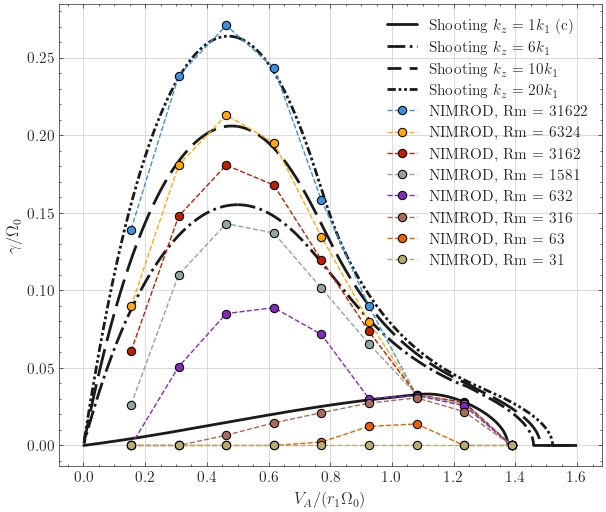

In [36]:
# %%
smrm = 1/2.0510130839719898e-07/10000/25298.2
# smrm=1
W0 = 252982
# Bs = np.asarray([   0 ,    5 ,   10 ,   15 ,   20 ,   25 ,   30 ,   35 ,   40 ,   45 ,   50 ,   55 ,   60 ,   65 ,   70 ,   75 ,   80 ])*smrm
Bs = np.asarray([   0 ,    5 ,   10 ,   15 ,   20 ,   25 ,   30 ,   35 ,   40 ,   45 ,   50 ,   55 ,   60 ,   65 ,   70 ,   75 ,   80 ])/(r1*Omega0*np.sqrt(rho*mu_0)*10000)

gs = [   0 ,    0 ,1.02e4,2.24e4,2.99e4,3.32e4,3.28e4,2.93e4,2.40e4,1.85e4,0.76e4,0.82e4,0.80e4,0.61e4,0.25e4,    0 ,    0 ]

### IMPORT MY DATA
r1_AR1 = 0.1
r2_AR1 = 0.5

## Get Alfven via input data
magB = [10, 20, 30, 40, 50, 60, 70, 80, 90]
vA = magB/np.sqrt(rho*mu_0)/10000

## AR1 Data
eta = ['0.1', '0.5', '1', '2', '5']
eta = ['0.1', '0.5', '1', '2', '5', '10', '50', '100']

### REVISION 3 WITH DTMS DATA
gr_10g = [44016.9, 28334.8, 19181.1,8262.29, 0, 0, 0, 0] ## WAITING ON 10 ETA 5
gr_20g = [75370.2, 57125.3, 46733.3,34777.3, 16046.7, 0, 0,0 ]
gr_30g = [85609.5, 67360.8, 57130.9,45215.5, 26877.8, 2088.13, 0,0]
gr_40g = [77029.5, 61718.3, 53070,43300.4, 28089.2, 4607.29, 0,0]
gr_50g = [50007, 42576.1, 37846,32054.6, 22632.4, 6674.49, 695.382, 0]
gr_60g = [28348.8, 25225.8, 23233.5,20705.8, 9544, 8632.65, 3878.04, 0]
gr_70g = [10148.7, 10339.7, 10378.7,10362, 10150.5, 9701.79, 4383.83, 0] ### OTHER ETA0.1 is 18002.2
gr_80g = [8849.72, 8520.59, 8737.85,8353.78, 8098.38, 6897.13, 0, 0]
# gr_90g = [10127.7, 9613.43, 9315.53,8896.36, 9541.62, 0, 0, 0]
gr_90g = [0, 0,0,0, 0, 0, 0, 0]

magB = [10, 20, 30, 40, 50, 60, 70, 80,90]
vA = magB/np.sqrt(rho*mu_0)/10000

gr_tot = [gr_10g, gr_20g, gr_30g, gr_40g, gr_50g, gr_60g, gr_70g, gr_80g,gr_90g]

etaplot_AR1 = []
for i in range(0, len(eta)):
    etai = np.zeros(len(gr_tot))
    for j in range(0, len(gr_tot)):
        etai[j] = gr_tot[j][i]
    etaplot_AR1.append(etai)

# fig = plt.figure()
fig = plt.figure(figsize=(7,6))
ax = plt.subplot(111)


### SHOOTING

### MCI 
plt.plot(VA_h_MCI1,gr_1k1_MCI_l, color = 'k', label=r'Shooting $k_z = 1k_1$ (c)', linewidth=2)
plt.plot(VA_l_MCI1,gr_1k1_MCI_h, color = 'k', linewidth=2)

# plt.plot(VA_l_MCI1_Az_ETA1_divr_q2mag9,gr_1k1_MCI_l_Az_ETA1_divr_q2mag9, 'k', label =f'Shooting $k_z = 1k_1$ (c), $\eta = 1, q^2 \sim 9$', linewidth=2)
# plt.plot(VA_h_MCI1_Az_ETA1_divr_q2mag9,gr_1k1_MCI_h_Az_ETA1_divr_q2mag9, 'k', linewidth=2)    

# plt.plot(VA_l_MCI1_Az_ETA5_divr_q2mag9,gr_1k1_MCI_l_Az_ETA5_divr_q2mag9, 'k', linestyle = '--', label =f'Shooting $k_z = 1k_1$ (c), $\eta = 5, q^2 \sim 9$', linewidth=2)
# plt.plot(VA_h_MCI1_Az_ETA5_divr_q2mag9,gr_1k1_MCI_h_Az_ETA5_divr_q2mag9, 'k', linestyle = '--', linewidth=2)    

# plt.plot(VA_l_MCI1_Az_ETA10_divr_q2mag9,gr_1k1_MCI_l_Az_ETA10_divr_q2mag9, 'k', linestyle = '--', label =f'Shooting $k_z = 1k_1$ (c), $\eta = 10, q^2 \sim 9$', linewidth=2)
# plt.plot(VA_h_MCI1_Az_ETA10_divr_q2mag9,gr_1k1_MCI_h_Az_ETA10_divr_q2mag9, 'k', linestyle = '--', linewidth=2)    

# plt.plot(VA_l_MCI1_Az_ETA50_divr_q2mag9,gr_1k1_MCI_l_Az_ETA50_divr_q2mag9, 'k', linestyle = ':', label =f'Shooting $k_z = 1k_1$ (c), $\eta = 50, q^2 \sim 9$', linewidth=2)
# plt.plot(VA_h_MCI1_Az_ETA50_divr_q2mag9,gr_1k1_MCI_h_Az_ETA50_divr_q2mag9, 'k', linestyle = ':', linewidth=2)    

# # qmag 4
# plt.plot(VA_l_MCI1_Az_ETA50_divr_q2mag16,gr_1k1_MCI_l_Az_ETA50_divr_q2mag16, 'k', linestyle = ':', label =f'Shooting $k_z = 1k_1$ (c), $\eta = 50, q^2 \sim 9$', linewidth=2)
# plt.plot(VA_h_MCI1_Az_ETA50_divr_q2mag16,gr_1k1_MCI_h_Az_ETA50_divr_q2mag16, 'k', linestyle = ':', linewidth=2)    


###### MRI

plt.plot(VA_l_MRI6,gr_6k1_MRI_l, label=r'Shooting $k_z = 6k_1$', color = 'k', linestyle = '-.', linewidth=2)
plt.plot(VA_h_MRI6,gr_6k1_MRI_h, color = 'k', linestyle = '-.', linewidth=2)

plt.plot(VA_l_MRI10,gr_10k1_MRI_l, label=r'Shooting $k_z = 10k_1$', color = 'k', linestyle = (5, (10, 3)), linewidth=2)
plt.plot(VA_h_MRI10,gr_10k1_MRI_h, color = 'k', linestyle = (5, (10, 3)), linewidth=2)

plt.plot(VA_l_MRI20,gr_20k1_MRI_l, label=r'Shooting $k_z = 20k_1$', color = 'k',linestyle = (0, (3, 1, 1, 1, 1, 1)), linewidth=2)
plt.plot(VA_h_MRI20,gr_20k1_MRI_h, color = 'k', linestyle = (0, (3, 1, 1, 1, 1, 1)), linewidth=2)

## Now compare different resisitivites versus the shooting curvature mode.
## PLOT SHOOTING DATA
# color_arr = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'navy', 'mediumvioletred', 'cadetblue', 'mediumseagreen']
# color_arr = [[63,144,218], [(255,169,14)], [(189, 31, 1)], [(148, 164, 162)], [(131, 45, 182)], [(169, 107, 89)], [(231, 99, 0)], [(185, 172, 112)], [(146, 218, 221)]]
color_arr = ['#3F90DA', '#FFA90E', '#BD1F01', '#94A4A2', '#832DB6', '#A96B59', '#E76300', '#B9AC70', '#92DADD']

V0 = r1*Omega0
eta_arr = [0.1,0.5,1,2,5,10, 50, 100]
Rm = r1*V0/np.array(eta_arr)
for i in range(0, len(etaplot_AR1)):
    ## Note 8/10 because of scaling w/ bb of other sims
    plt.plot(vA/(r1_AR1*Omega0), etaplot_AR1[i]/(Omega0), 'o', linestyle = '--', label=r'NIMROD, Rm = ' + str(int(Rm[i])), color = color_arr[i], markeredgecolor='black', markeredgewidth = 0.75)  
## PLOT SHOOTING DATA

print(etaplot_AR1)
# color_arr = ['dodgerblue', 'mediumorchid', 'midnightblue', 'springgreen', 'tomato', 'k']


VA_shoot = [1.157*8/10] ## ETA0.1
ETAp1 = [0.02283895391150039]
ETAp5 = [0.01718854743963384]
ETA1 = [0.01717910905775954]
ETA2 = [0.018524447015573035]
ETA5 = [0.020554535400139143]
# plt.axvline(x=1, linestyle = '--', color = '#ecb333')
# plt.text(1.3-0.05, 0.22, 'MCI', fontsize=20, color = '#ecb333')
# plt.text(.05, 0.22, 'MRI', fontsize=20, color = '#ecb333')
# plt.plot(VA_shoot, ETAp1, 'o', label = 'Shooting $\eta = 0.1$')
# plt.plot(VA_shoot, ETAp5,  'o', label = 'Shooting $\eta = 0.5$')
# plt.plot(VA_shoot, ETA1,  'o', label = 'Shooting $\eta = 1$')
# plt.plot(VA_shoot, ETA2, 'o',  label = 'Shooting $\eta = 2$')
# plt.plot(VA_shoot, ETA5, 'o',  label = 'Shooting $\eta = 5$')
plt.plot()
plt.xlabel(r'${V_A}/(r_1\Omega_0)$')
plt.ylabel(r'$\gamma/\Omega_0$')
# plt.ylim(-0.01, 0.3)
# plt.legend(frameon=False)
# plt.title('Azimuthal Field Growth Rates (Shooting vs NIMROD)',fontsize=15)
# plt.savefig('plots/growthshooting_diffETA_AR1_curv.pdf')
plt.legend()

# box = ax.get_position()
# ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])

# Put a legend to the right of the current axis
# ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
# ax.legend()
# plt.ylim(0,0.3)
plt.savefig('Shooting-NIMROD-comp/GRvsAlfvenSpeed-NIMROD-Az-w-v2.png', bbox_inches='tight', dpi = 400)
plt.savefig('Shooting-NIMROD-comp/GRvsAlfvenSpeed-NIMROD-Az-w-v2.svg', bbox_inches='tight', format = 'svg')

plt.show()
plt.close()

In [37]:
Vr3 = f'Contour-Data/Vr_contour_Eta5Bz80G-Az.pkl'
with open(Vr3, 'rb') as f:
    Vr_Eta5_20G = pickle.load(f)    

Vr3 = f'Contour-Data/Vr_contour_Eta5Bz40G-Az.pkl'
with open(Vr3, 'rb') as f:
    Vr_Eta5_10G = pickle.load(f)    

Vr5 = f'Contour-Data/rc-Az.pkl'
with open(Vr5, 'rb') as f:
    rc = pickle.load(f)    
    
Vr6 = f'Contour-Data/zc-Az.pkl'
with open(Vr6, 'rb') as f:
    zc = pickle.load(f)   
    

Vr3 = f'Contour-Data/Vr_contour_Eta1Bz80G-Az.pkl'
with open(Vr3, 'rb') as f:
    Vr_Eta1_80G = pickle.load(f)    

Vr3 = f'Contour-Data/Vr_contour_Eta1Bz40G-Az.pkl'
with open(Vr3, 'rb') as f:
    Vr_Eta1_40G = pickle.load(f)    
    
    
Vr3 = f'Contour-Data/Vr_contour_Eta10Bz80G-Az.pkl'
with open(Vr3, 'rb') as f:
    Vr_Eta10_80G = pickle.load(f)   
    
Vr3 = f'Contour-Data/Vr_contour_Eta10Bz40G-Az.pkl'
with open(Vr3, 'rb') as f:
    Vr_Eta10_40G = pickle.load(f)   
    

C:\Users\Alex\AppData\Local\Temp\ipykernel_207076\1174633865.py:225: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


[0.1, 0.5, 1, 2, 5, 10, 50, 100]
5


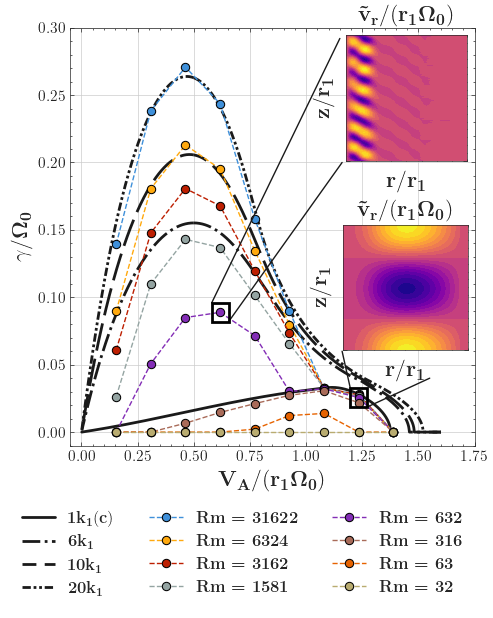

In [38]:
# %%
smrm = 1/2.0510130839719898e-07/10000/25298.2
# smrm=1
W0 = 252982
# Bs = np.asarray([   0 ,    5 ,   10 ,   15 ,   20 ,   25 ,   30 ,   35 ,   40 ,   45 ,   50 ,   55 ,   60 ,   65 ,   70 ,   75 ,   80 ])*smrm
Bs = np.asarray([   0 ,    5 ,   10 ,   15 ,   20 ,   25 ,   30 ,   35 ,   40 ,   45 ,   50 ,   55 ,   60 ,   65 ,   70 ,   75 ,   80 ])/(r1*Omega0*np.sqrt(rho*mu_0)*10000)

gs = [   0 ,    0 ,1.02e4,2.24e4,2.99e4,3.32e4,3.28e4,2.93e4,2.40e4,1.85e4,0.76e4,0.82e4,0.80e4,0.61e4,0.25e4,    0 ,    0 ]

### IMPORT MY DATA
r1_AR1 = 0.1
r2_AR1 = 0.5

## Get Alfven via input data
magB = [10, 20, 30, 40, 50, 60, 70, 80, 90]
vA = magB/np.sqrt(rho*mu_0)/10000

## AR1 Data
eta = ['0.1', '0.5', '1', '2', '5']
eta = ['0.1', '0.5', '1', '2', '5', '10', '50', '100']

### REVISION 3 WITH DTMS DATA
gr_10g = [44016.9, 28334.8, 19181.1,8262.29, 0, 0, 0, 0] ## WAITING ON 10 ETA 5
gr_20g = [75370.2, 57125.3, 46733.3,34777.3, 16046.7, 0, 0,0 ]
gr_30g = [85609.5, 67360.8, 57130.9,45215.5, 26877.8, 2088.13, 0,0]
gr_40g = [77029.5, 61718.3, 53070,43300.4, 28089.2, 4607.29, 0,0]
gr_50g = [50007, 42576.1, 37846,32054.6, 22632.4, 6674.49, 695.382, 0]
gr_60g = [28348.8, 25225.8, 23233.5,20705.8, 9544, 8632.65, 3878.04, 0]
gr_70g = [10148.7, 10339.7, 10378.7,10362, 10150.5, 9701.79, 4383.83, 0] ### OTHER ETA0.1 is 18002.2
gr_80g = [8849.72, 8520.59, 8737.85,8353.78, 8098.38, 6897.13, 0, 0]
gr_90g = [0, 0,0,0, 0, 0, 0, 0]

magB = [10, 20, 30, 40, 50, 60, 70, 80,90]
vA = magB/np.sqrt(rho*mu_0)/10000

gr_tot = [gr_10g, gr_20g, gr_30g, gr_40g, gr_50g, gr_60g, gr_70g, gr_80g,gr_90g]

etaplot_AR1 = []
for i in range(0, len(eta)):
    etai = np.zeros(len(gr_tot))
    for j in range(0, len(gr_tot)):
        etai[j] = gr_tot[j][i]
    etaplot_AR1.append(etai)

# fig = plt.figure()
fig = plt.figure(figsize=(5,5))
ax = plt.subplot(111)


### SHOOTING

### MCI 
plt.plot(VA_h_MCI1,gr_1k1_MCI_l, color = 'k', label=r'$\mathbf{1k_1 (c)}$', linewidth=2)
plt.plot(VA_l_MCI1,gr_1k1_MCI_h, color = 'k', linewidth=2)

###### MRI

plt.plot(VA_l_MRI6,gr_6k1_MRI_l, label=r'$\mathbf{6k_1}$', color = 'k', linestyle = '-.', linewidth=2)
plt.plot(VA_h_MRI6,gr_6k1_MRI_h, color = 'k', linestyle = '-.', linewidth=2)

plt.plot(VA_l_MRI10,gr_10k1_MRI_l, label=r'$\mathbf{10k_1}$', color = 'k', linestyle = (5, (10, 3)), linewidth=2)
plt.plot(VA_h_MRI10,gr_10k1_MRI_h, color = 'k', linestyle = (5, (10, 3)), linewidth=2)

plt.plot(VA_l_MRI20,gr_20k1_MRI_l, label=r'$\mathbf{20k_1}$', color = 'k',linestyle = (0, (3, 1, 1, 1, 1, 1)), linewidth=2)
plt.plot(VA_h_MRI20,gr_20k1_MRI_h, color = 'k', linestyle = (0, (3, 1, 1, 1, 1, 1)), linewidth=2)

## Now compare different resisitivites versus the shooting curvature mode.
## PLOT SHOOTING DATA
color_arr = ['#3F90DA', '#FFA90E', '#BD1F01', '#94A4A2', '#832DB6', '#A96B59', '#E76300', '#B9AC70', '#92DADD']

V0 = r1*Omega0
eta_arr = [0.1,0.5,1,2,5,10, 50, 100]
Rm = r1*V0/np.array(eta_arr)
for i in range(0, len(etaplot_AR1)):
    # plt.plot(vA/(r1_AR1*Omega0), etaplot_AR1[i]/(Omega0), 'o', linestyle = '--', label=r'\textbf{Rm = }' + str(int(Rm[i])), color = color_arr[i], markeredgecolor='black', markeredgewidth = 0.75)  
    if(i == 0):
        plt.plot(vA/(r1_AR1*Omega0), etaplot_AR1[i]/(Omega0), 'o', linestyle = '--', label=r'\textbf{Rm = 31622}', color = color_arr[i], markeredgecolor='black', markeredgewidth = 0.75)  
    elif(i == 1):
        plt.plot(vA/(r1_AR1*Omega0), etaplot_AR1[i]/(Omega0), 'o', linestyle = '--', label=r'\textbf{Rm = 6324}', color = color_arr[i], markeredgecolor='black', markeredgewidth = 0.75)  
    elif(i == 2):
        plt.plot(vA/(r1_AR1*Omega0), etaplot_AR1[i]/(Omega0), 'o', linestyle = '--', label=r'\textbf{Rm = 3162}', color = color_arr[i], markeredgecolor='black', markeredgewidth = 0.75)  
    elif(i == 3):
        plt.plot(vA/(r1_AR1*Omega0), etaplot_AR1[i]/(Omega0), 'o', linestyle = '--', label=r'\textbf{Rm = 1581}', color = color_arr[i], markeredgecolor='black', markeredgewidth = 0.75)  
    elif(i == 4):
        plt.plot(vA/(r1_AR1*Omega0), etaplot_AR1[i]/(Omega0), 'o', linestyle = '--', label=r'\textbf{Rm = 632}', color = color_arr[i], markeredgecolor='black', markeredgewidth = 0.75)  
    elif(i == 5):
        plt.plot(vA/(r1_AR1*Omega0), etaplot_AR1[i]/(Omega0), 'o', linestyle = '--', label=r'\textbf{Rm = 316}', color = color_arr[i], markeredgecolor='black', markeredgewidth = 0.75)  
    elif(i == 6):
        plt.plot(vA/(r1_AR1*Omega0), etaplot_AR1[i]/(Omega0), 'o', linestyle = '--', label=r'\textbf{Rm = 63}', color = color_arr[i], markeredgecolor='black', markeredgewidth = 0.75)  
    elif(i == 7):
        plt.plot(vA/(r1_AR1*Omega0), etaplot_AR1[i]/(Omega0), 'o', linestyle = '--', label=r'\textbf{Rm = 32}', color = color_arr[i], markeredgecolor='black', markeredgewidth = 0.75)  

## PLOT SHOOTING DATA

VA_shoot = [1.157*8/10] ## ETA0.1
ETAp1 = [0.02283895391150039]
ETAp5 = [0.01718854743963384]
ETA1 = [0.01717910905775954]
ETA2 = [0.018524447015573035]
ETA5 = [0.020554535400139143]
plt.xlabel(r'$\mathbf{{V_A}/(r_1\Omega_0)}$', fontsize = 16)
plt.ylabel(r'$\mathbf{\gamma/\Omega_0}$', fontsize = 16)

###################################
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from matplotlib.patches import Rectangle

# ax_inset = inset_axes(ax, width="30%", height="30%", loc='center right')
# ax_inset.axes.xaxis.set_ticklabels([])
# ax_inset.axes.yaxis.set_ticklabels([])
# ax_inset.set_xlabel(r'$\mathbf{r/r_1}$', fontsize = 16)
# ax_inset.set_ylabel(r'$\mathbf{z/r_1}$', fontsize = 16)
# cp2=ax_inset.contourf(rc/0.1,zc/0.1, Vr_Eta5_20G,50, cmap='plasma')
# ax_inset.set_title(r"$\mathbf{\tilde{v}_r/(r_1\Omega_0)}$", fontsize = 16)

# inset_top = fig.add_axes([0.7, 0.3, 0.25, 0.25])  # [left, bottom, width, height]
inset_top = fig.add_axes([0.7, 0.32, 0.25, 0.25])  # [left, bottom, width, height]

inset_top.axes.xaxis.set_ticklabels([])
inset_top.axes.yaxis.set_ticklabels([])
inset_top.set_xlabel(r'$\mathbf{r/r_1}$', fontsize = 16)
inset_top.set_ylabel(r'$\mathbf{z/r_1}$', fontsize = 16)
cp2=inset_top.contourf(rc/0.1,zc/0.1, Vr_Eta5_20G,20, cmap='plasma')
inset_top.set_title(r"$\mathbf{\tilde{v}_r/(r_1\Omega_0)}$", fontsize = 16)



ax_inset = inset_axes(ax, width="30%", height="30%", loc='upper right')
ax_inset.axes.xaxis.set_ticklabels([])
ax_inset.axes.yaxis.set_ticklabels([])
ax_inset.set_xlabel(r'$\mathbf{r/r_1}$', fontsize = 16)
ax_inset.set_ylabel(r'$\mathbf{z/r_1}$', fontsize = 16)
cp2=ax_inset.contourf(rc/0.1,zc/0.1, Vr_Eta5_10G,20, cmap='plasma')
ax_inset.set_title(r"$\mathbf{\tilde{v}_r/(r_1\Omega_0)}$", fontsize = 16, pad = 10)



highlight_x_MRI = (vA/(r1_AR1*Omega0))[3]
highlight_y_MRI = etaplot_AR1[4][3]/(Omega0)

highlight_x_MCI = (vA/(r1_AR1*Omega0))[len(vA/(r1_AR1*Omega0))-2]
highlight_y_MCI = (etaplot_AR1[4]/(Omega0))[len(etaplot_AR1[0]/(Omega0))-2]

# Define the center and size of the rectangle
width = 0.075  # Width of the rectangle
height = 0.02*0.7  # Height of the rectangle

# Calculate the bottom-left corner coordinates
x = highlight_x_MCI - width / 2
y = highlight_y_MCI - height / 2

rect_x = x
rect_y = y
rect_width = width 
rect_height = height

# Define the rectangle's corners in the main plot
main_rect_corners = [
    (rect_x, rect_y),  # Bottom-left corner
    (rect_x + rect_width, rect_y),  # Bottom-right corner
    (rect_x, rect_y + rect_height),  # Top-left corner
    (rect_x + rect_width, rect_y + rect_height)  # Top-right corner
]

# Create a rectangle
rect = Rectangle((x, y), width, height, linewidth=2, edgecolor='black', facecolor='none', zorder=3)
ax.add_patch(rect)

################### PLOT LINES
# pt2 = [1.15, 0.05]
pt2 = [1.55, 0.04]
pt3 = [1.16, 0.06]

line1X = [main_rect_corners[1][0], pt2[0]]
line1Y = [main_rect_corners[1][1],pt2[1]] 
line2X = [main_rect_corners[0][0], pt3[0]]
line2Y = [main_rect_corners[2][1],pt3[1]]
ax.plot(line1X, line1Y, color = 'k', zorder=2)
ax.plot(line2X, line2Y, color = 'k', zorder=2)

############### MRI
# Define the center and size of the rectangle
width = 0.075  # Width of the rectangle
height = 0.02*0.7  # Height of the rectangle

# Calculate the bottom-left corner coordinates
x = highlight_x_MRI - width / 2
y = highlight_y_MRI - height / 2

rect_x = x
rect_y = y
rect_width = width 
rect_height = height

# Define the rectangle's corners in the main plot
main_rect_corners = [
    (rect_x, rect_y),  # Bottom-left corner
    (rect_x + rect_width, rect_y),  # Bottom-right corner
    (rect_x, rect_y + rect_height),  # Top-left corner
    (rect_x + rect_width, rect_y + rect_height)  # Top-right corner
]

# Create a rectangle
rect = Rectangle((x, y), width, height, linewidth=2, edgecolor='black', facecolor='none', zorder=3)
ax.add_patch(rect)

################### PLOT LINES
pt2 = [1.16, 0.2]
pt3 = [1.15, 0.292]

line1X = [main_rect_corners[1][0], pt2[0]]
line1Y = [main_rect_corners[0][1],pt2[1]] 
line2X = [main_rect_corners[0][0], pt3[0]]
line2Y = [main_rect_corners[2][1],pt3[1]]
# line2X = [main_rect_corners[0][0], pt3[0]]
# line2Y = [main_rect_corners[2][1],pt3[1]]
ax.plot(line1X, line1Y, color = 'k', zorder=2)
ax.plot(line2X, line2Y, color = 'k', zorder=2)


box = ax.get_position()
# ax.legend()
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()

lines_labels = [ax.get_legend_handles_labels() for ax in fig.axes]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]

fig.legend(lines, labels, loc='lower center', ncol=3, 
           bbox_to_anchor=(0.5, -0.24),  # Position the legend below the plot
           frameon=False,  # Turn on the frame (border)
           edgecolor='black',  # Set the border color
           facecolor='white',  # Set the background color of the legend box
           borderpad=1,  # Padding between the legend text and the border
           borderaxespad=1, fontsize = 12)


print(eta_arr)
print(eta_arr[4])
ax.set_ylim(-0.01, 0.3)
ax.set_xlim(-0.05, 1.75)


plt.savefig('Shooting-NIMROD-comp/GRvsAlfvenSpeed-NIMROD-Az-w-v3.png', bbox_inches='tight', dpi = 400)
plt.savefig('Shooting-NIMROD-comp/GRvsAlfvenSpeed-NIMROD-Az-w-v3.pdf', bbox_inches='tight', dpi = 400)


plt.show()
plt.close()

### Combined

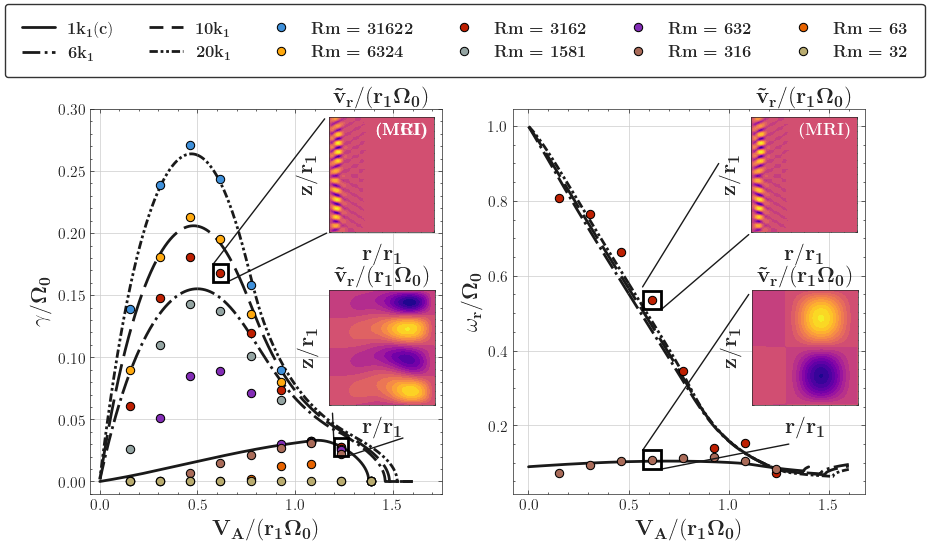

In [44]:
# %%
smrm = 1/2.0510130839719898e-07/10000/25298.2
# smrm=1
W0 = 252982
# Bs = np.asarray([   0 ,    5 ,   10 ,   15 ,   20 ,   25 ,   30 ,   35 ,   40 ,   45 ,   50 ,   55 ,   60 ,   65 ,   70 ,   75 ,   80 ])*smrm
Bs = np.asarray([   0 ,    5 ,   10 ,   15 ,   20 ,   25 ,   30 ,   35 ,   40 ,   45 ,   50 ,   55 ,   60 ,   65 ,   70 ,   75 ,   80 ])/(r1*Omega0*np.sqrt(rho*mu_0)*10000)

gs = [   0 ,    0 ,1.02e4,2.24e4,2.99e4,3.32e4,3.28e4,2.93e4,2.40e4,1.85e4,0.76e4,0.82e4,0.80e4,0.61e4,0.25e4,    0 ,    0 ]

### IMPORT MY DATA
r1_AR1 = 0.1
r2_AR1 = 0.5

## Get Alfven via input data
magB = [10, 20, 30, 40, 50, 60, 70, 80, 90]
vA = magB/np.sqrt(rho*mu_0)/10000

## AR1 Data
eta = ['0.1', '0.5', '1', '2', '5']
eta = ['0.1', '0.5', '1', '2', '5', '10', '50', '100']

### REVISION 3 WITH DTMS DATA
gr_10g = [44016.9, 28334.8, 19181.1,8262.29, 0, 0, 0, 0] ## WAITING ON 10 ETA 5
gr_20g = [75370.2, 57125.3, 46733.3,34777.3, 16046.7, 0, 0,0 ]
gr_30g = [85609.5, 67360.8, 57130.9,45215.5, 26877.8, 2088.13, 0,0]
gr_40g = [77029.5, 61718.3, 53070,43300.4, 28089.2, 4607.29, 0,0]
gr_50g = [50007, 42576.1, 37846,32054.6, 22632.4, 6674.49, 695.382, 0]
gr_60g = [28348.8, 25225.8, 23233.5,20705.8, 9544, 8632.65, 3878.04, 0]
gr_70g = [10148.7, 10339.7, 10378.7,10362, 10150.5, 9701.79, 4383.83, 0] ### OTHER ETA0.1 is 18002.2
gr_80g = [8849.72, 8520.59, 8737.85,8353.78, 8098.38, 6897.13, 0, 0]
gr_90g = [0, 0,0,0, 0, 0, 0, 0]

magB = [10, 20, 30, 40, 50, 60, 70, 80,90]
vA = magB/np.sqrt(rho*mu_0)/10000

gr_tot = [gr_10g, gr_20g, gr_30g, gr_40g, gr_50g, gr_60g, gr_70g, gr_80g,gr_90g]

etaplot_AR1 = []
for i in range(0, len(eta)):
    etai = np.zeros(len(gr_tot))
    for j in range(0, len(gr_tot)):
        etai[j] = gr_tot[j][i]
    etaplot_AR1.append(etai)

# fig = plt.figure()
fig, ax = plt.subplots(1,2)
fig.set_figheight(5)
fig.set_figwidth(10)

# ax = plt.subplot(111)


### SHOOTING

### MCI 
ax[0].plot(VA_h_MCI1,gr_1k1_MCI_l, color = 'k', label=r'$\mathbf{1k_1 (c)}$', linewidth=2)
ax[0].plot(VA_l_MCI1,gr_1k1_MCI_h, color = 'k', linewidth=2)

###### MRI

ax[0].plot(VA_l_MRI6,gr_6k1_MRI_l, label=r'$\mathbf{6k_1}$', color = 'k', linestyle = '-.', linewidth=2)
ax[0].plot(VA_h_MRI6,gr_6k1_MRI_h, color = 'k', linestyle = '-.', linewidth=2)

ax[0].plot(VA_l_MRI10,gr_10k1_MRI_l, label=r'$\mathbf{10k_1}$', color = 'k', linestyle = (5, (10, 3)), linewidth=2)
ax[0].plot(VA_h_MRI10,gr_10k1_MRI_h, color = 'k', linestyle = (5, (10, 3)), linewidth=2)
ax[0]
ax[0].plot(VA_l_MRI20,gr_20k1_MRI_l, label=r'$\mathbf{20k_1}$', color = 'k',linestyle = (0, (3, 1, 1, 1, 1, 1)), linewidth=2)
ax[0].plot(VA_h_MRI20,gr_20k1_MRI_h, color = 'k', linestyle = (0, (3, 1, 1, 1, 1, 1)), linewidth=2)

## Now compare different resisitivites versus the shooting curvature mode.
## PLOT SHOOTING DATA
color_arr = ['#3F90DA', '#FFA90E', '#BD1F01', '#94A4A2', '#832DB6', '#A96B59', '#E76300', '#B9AC70', '#92DADD']

V0 = r1*Omega0
eta_arr = [0.1,0.5,1,2,5,10, 50, 100]
Rm = r1*V0/np.array(eta_arr)
for i in range(0, len(etaplot_AR1)):
    # plt.plot(vA/(r1_AR1*Omega0), etaplot_AR1[i]/(Omega0), 'o', linestyle = '--', label=r'\textbf{Rm = }' + str(int(Rm[i])), color = color_arr[i], markeredgecolor='black', markeredgewidth = 0.75)  
    if(i == 0):
        ax[0].plot(vA/(r1_AR1*Omega0), etaplot_AR1[i]/(Omega0), 'o', label=r'\textbf{Rm = 31622}', color = color_arr[i], markeredgecolor='black', markeredgewidth = 0.75)  
    elif(i == 1):
        ax[0].plot(vA/(r1_AR1*Omega0), etaplot_AR1[i]/(Omega0), 'o', label=r'\textbf{Rm = 6324}', color = color_arr[i], markeredgecolor='black', markeredgewidth = 0.75)  
    elif(i == 2):
        ax[0].plot(vA/(r1_AR1*Omega0), etaplot_AR1[i]/(Omega0), 'o', label=r'\textbf{Rm = 3162}', color = color_arr[i], markeredgecolor='black', markeredgewidth = 0.75)  
    elif(i == 3):
        ax[0].plot(vA/(r1_AR1*Omega0), etaplot_AR1[i]/(Omega0), 'o', label=r'\textbf{Rm = 1581}', color = color_arr[i], markeredgecolor='black', markeredgewidth = 0.75)  
    elif(i == 4):
        ax[0].plot(vA/(r1_AR1*Omega0), etaplot_AR1[i]/(Omega0), 'o', label=r'\textbf{Rm = 632}', color = color_arr[i], markeredgecolor='black', markeredgewidth = 0.75)  
    elif(i == 5):
        ax[0].plot(vA/(r1_AR1*Omega0), etaplot_AR1[i]/(Omega0), 'o', label=r'\textbf{Rm = 316}', color = color_arr[i], markeredgecolor='black', markeredgewidth = 0.75)  
    elif(i == 6):
        ax[0].plot(vA/(r1_AR1*Omega0), etaplot_AR1[i]/(Omega0), 'o', label=r'\textbf{Rm = 63}', color = color_arr[i], markeredgecolor='black', markeredgewidth = 0.75)  
    elif(i == 7):
        ax[0].plot(vA/(r1_AR1*Omega0), etaplot_AR1[i]/(Omega0), 'o', label=r'\textbf{Rm = 32}', color = color_arr[i], markeredgecolor='black', markeredgewidth = 0.75)  

## PLOT SHOOTING DATA

VA_shoot = [1.157*8/10] ## ETA0.1
ETAp1 = [0.02283895391150039]
ETAp5 = [0.01718854743963384]
ETA1 = [0.01717910905775954]
ETA2 = [0.018524447015573035]
ETA5 = [0.020554535400139143]


###################################
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from matplotlib.patches import Rectangle

# ax_inset = inset_axes(ax, width="30%", height="30%", loc='center right')
# ax_inset.axes.xaxis.set_ticklabels([])
# ax_inset.axes.yaxis.set_ticklabels([])
# ax_inset.set_xlabel(r'$\mathbf{r/r_1}$', fontsize = 16)
# ax_inset.set_ylabel(r'$\mathbf{z/r_1}$', fontsize = 16)
# cp2=ax_inset.contourf(rc/0.1,zc/0.1, Vr_Eta5_20G,50, cmap='plasma')
# ax_inset.set_title(r"$\mathbf{\tilde{v}_r/(r_1\Omega_0)}$", fontsize = 16)

# inset_top = fig.add_axes([0.7, 0.3, 0.25, 0.25])  # [left, bottom, width, height]
# inset_top = fig.add_axes([0.7, 0.32, 0.25, 0.25])  # [left, bottom, width, height]

# Get subplot position
pos = ax[0].get_position()

# Define inset axes using figure.add_axes, relative to the subplot's position
inset_top = fig.add_axes([
    pos.x0 + 0.68 * pos.width,  # Left position relative to subplot
    pos.y0 + 0.23 * pos.height, # Bottom position relative to subplot
    0.3 * pos.width,          # Width relative to subplot
    0.3 * pos.height          # Height relative to subplot
])


inset_top.axes.xaxis.set_ticklabels([])
inset_top.axes.yaxis.set_ticklabels([])
inset_top.set_xlabel(r'$\mathbf{r/r_1}$', fontsize = 16)
inset_top.set_ylabel(r'$\mathbf{z/r_1}$', fontsize = 16)
cp2=inset_top.contourf(rc/0.1,zc/0.1, Vr_Eta1_80G,20, cmap='plasma')
inset_top.set_title(r"$\mathbf{\tilde{v}_r/(r_1\Omega_0)}$", fontsize = 16)
ax_inset.text(0.45, 0.96, r'\textbf{(MCI)}', transform=ax_inset.transAxes, fontsize=12, verticalalignment='top', horizontalalignment='left', color = 'white')



ax_inset = inset_axes(ax[0], width="30%", height="30%", loc='upper right')
ax_inset.axes.xaxis.set_ticklabels([])
ax_inset.axes.yaxis.set_ticklabels([])
ax_inset.set_xlabel(r'$\mathbf{r/r_1}$', fontsize = 16)
ax_inset.set_ylabel(r'$\mathbf{z/r_1}$', fontsize = 16)
cp2=ax_inset.contourf(rc/0.1,zc/0.1, Vr_Eta1_40G,20, cmap='plasma')
ax_inset.set_title(r"$\mathbf{\tilde{v}_r/(r_1\Omega_0)}$", fontsize = 16, pad = 10)
ax_inset.text(0.45, 0.96, r'\textbf{(MCI)}', transform=ax_inset.transAxes, fontsize=12, verticalalignment='top', horizontalalignment='left', color = 'white')


### ETA5
# highlight_x_MRI = (vA/(r1_AR1*Omega0))[3]
# highlight_y_MRI = etaplot_AR1[4][3]/(Omega0)

# highlight_x_MCI = (vA/(r1_AR1*Omega0))[len(vA/(r1_AR1*Omega0))-2]
# highlight_y_MCI = (etaplot_AR1[4]/(Omega0))[len(etaplot_AR1[0]/(Omega0))-2]

highlight_x_MRI = (vA/(r1_AR1*Omega0))[3]
highlight_y_MRI = etaplot_AR1[2][3]/(Omega0)

highlight_x_MCI = (vA/(r1_AR1*Omega0))[len(vA/(r1_AR1*Omega0))-2]
highlight_y_MCI = (etaplot_AR1[2]/(Omega0))[len(etaplot_AR1[0]/(Omega0))-2]


# Define the center and size of the rectangle
width = 0.075  # Width of the rectangle
height = 0.02*0.7  # Height of the rectangle

# Calculate the bottom-left corner coordinates
x = highlight_x_MCI - width / 2
y = highlight_y_MCI - height / 2

rect_x = x
rect_y = y
rect_width = width 
rect_height = height

# Define the rectangle's corners in the main plot
main_rect_corners = [
    (rect_x, rect_y),  # Bottom-left corner
    (rect_x + rect_width, rect_y),  # Bottom-right corner
    (rect_x, rect_y + rect_height),  # Top-left corner
    (rect_x + rect_width, rect_y + rect_height)  # Top-right corner
]

# Create a rectangle
rect = Rectangle((x, y), width, height, linewidth=2, edgecolor='black', facecolor='none', zorder=3)
ax[0].add_patch(rect)

################### PLOT LINES
# pt2 = [1.15, 0.05]
pt2 = [1.55, 0.035]
pt3 = [1.19, 0.055]

line1X = [main_rect_corners[1][0], pt2[0]]
line1Y = [main_rect_corners[1][1],pt2[1]] 
line2X = [main_rect_corners[0][0], pt3[0]]
line2Y = [main_rect_corners[2][1],pt3[1]]
ax[0].plot(line1X, line1Y, color = 'k', zorder=2)
ax[0].plot(line2X, line2Y, color = 'k', zorder=2)

############### MRI
# Define the center and size of the rectangle
width = 0.075  # Width of the rectangle
height = 0.02*0.7  # Height of the rectangle

# Calculate the bottom-left corner coordinates
x = highlight_x_MRI - width / 2
y = highlight_y_MRI - height / 2

rect_x = x
rect_y = y
rect_width = width 
rect_height = height

# Define the rectangle's corners in the main plot
main_rect_corners = [
    (rect_x, rect_y),  # Bottom-left corner
    (rect_x + rect_width, rect_y),  # Bottom-right corner
    (rect_x, rect_y + rect_height),  # Top-left corner
    (rect_x + rect_width, rect_y + rect_height)  # Top-right corner
]

# Create a rectangle
rect = Rectangle((x, y), width, height, linewidth=2, edgecolor='black', facecolor='none', zorder=3)
ax[0].add_patch(rect)

################### PLOT LINES
pt2 = [1.16, 0.2]
pt3 = [1.15, 0.292]

line1X = [main_rect_corners[1][0], pt2[0]]
line1Y = [main_rect_corners[0][1],pt2[1]] 
line2X = [main_rect_corners[0][0], pt3[0]]
line2Y = [main_rect_corners[2][1],pt3[1]]
# line2X = [main_rect_corners[0][0], pt3[0]]
# line2Y = [main_rect_corners[2][1],pt3[1]]
ax[0].plot(line1X, line1Y, color = 'k', zorder=2)
ax[0].plot(line2X, line2Y, color = 'k', zorder=2)

# print(eta_arr)
# print(eta_arr[4])
ax[0].set_ylim(-0.01, 0.3)
ax[0].set_xlim(-0.05, 1.75)
####################################### Frequency

### MCI 
ax[1].plot(VA_h_MCI1,freq_1k1_MCI_l, color = 'k', linewidth=2)
ax[1].plot(VA_l_MCI1,freq_1k1_MCI_h, color = 'k', linewidth=2)
### MRI

ax[1].plot(VA_l_MRI6,freq_6k1_MRI_l, color = 'k', linestyle = '-.', linewidth=2)
ax[1].plot(VA_h_MRI6,freq_6k1_MRI_h, color = 'k', linestyle = '-.', linewidth=2)

ax[1].plot(VA_l_MRI10,freq_10k1_MRI_l, color = 'k', linestyle = (5, (10, 3)), linewidth=2)
ax[1].plot(VA_h_MRI10,freq_10k1_MRI_h, color = 'k', linestyle = (5, (10, 3)), linewidth=2)

ax[1].plot(VA_l_MRI20,freq_20k1_MRI_l, color = 'k',linestyle = (0, (3, 1, 1, 1, 1, 1)), linewidth=2)
ax[1].plot(VA_h_MRI20,freq_20k1_MRI_h, color = 'k', linestyle = (0, (3, 1, 1, 1, 1, 1)), linewidth=2)

ETA1_freq = [0.7947670612636882, 0.6479079303780066,0.6891891490662979,0.5519215703220056, 0.3010481292665485, 0.2536490621054323,0.09645231326015632,0.10277160274961485 ]
ETA1_freq = [0.8221728219969188, 0.7012650540561954, 0.6623058843864067, 0.5259487905421465, 0.29803764797388305, 0.27094331633989366,0.10277160274961485 ,0.10277160274961485]
ETA1_freq = [0.8071852965959332, 0.7641990973689308, 0.6623058843864067, 0.5349393681582516, 0.34524455675461635, 0.13887058866166593,0.15255007574018656 ,0.07306577372234381]
ETA10_freq = [	0.07386310978287064, 0.0952958107030801, 0.10479523487126687, .10821991574941284, 0.11289304847495568, 0.11468500162535179, 0.10413614534377463, 0.08339633381570703] 
VA1 = np.array([10, 20, 30, 40, 50, 60, 70,80])/10000/ np.sqrt(rho*mu_0)/(r1*Omega0)

VA5 = np.array([20, 30, 40, 50, 60, 70,80])/10000/ np.sqrt(rho*mu_0)/(r1*Omega0)
ETA5_freq = [0.607429111108676, 0.5916923893599149, 0.32962689176834986, 0.2189664352461181, 0.09461512634091525, 0.08545882379179442, 0.0917038916842717]
ax[1].plot(VA1, ETA1_freq, marker = 'o', color = color_arr[2], markeredgecolor='black', markeredgewidth = 0.75, linestyle = '')   
ax[1].plot(VA1, ETA10_freq, marker = 'o', color = color_arr[5], markeredgecolor='black', markeredgewidth = 0.75, linestyle = '')  


# Get subplot position
pos = ax[1].get_position()

# Define inset axes using figure.add_axes, relative to the subplot's position
inset_top = fig.add_axes([
    pos.x0 + 0.68 * pos.width,  # Left position relative to subplot
    pos.y0 + 0.23 * pos.height, # Bottom position relative to subplot
    0.3 * pos.width,          # Width relative to subplot
    0.3 * pos.height          # Height relative to subplot
])


inset_top.axes.xaxis.set_ticklabels([])
inset_top.axes.yaxis.set_ticklabels([])
inset_top.set_xlabel(r'$\mathbf{r/r_1}$', fontsize = 16)
inset_top.set_ylabel(r'$\mathbf{z/r_1}$', fontsize = 16)
cp2=inset_top.contourf(rc/0.1,zc/0.1, Vr_Eta10_40G,20, cmap='plasma')
inset_top.set_title(r"$\mathbf{\tilde{v}_r/(r_1\Omega_0)}$", fontsize = 16)
ax_inset.text(0.45, 0.96, r'\textbf{(MRI)}', transform=ax_inset.transAxes, fontsize=12, verticalalignment='top', horizontalalignment='left', color = 'white')



ax_inset = inset_axes(ax[1], width="30%", height="30%", loc='upper right')
ax_inset.axes.xaxis.set_ticklabels([])
ax_inset.axes.yaxis.set_ticklabels([])
ax_inset.set_xlabel(r'$\mathbf{r/r_1}$', fontsize = 16)
ax_inset.set_ylabel(r'$\mathbf{z/r_1}$', fontsize = 16)
cp2=ax_inset.contourf(rc/0.1,zc/0.1, Vr_Eta1_40G,20, cmap='plasma')
ax_inset.set_title(r"$\mathbf{\tilde{v}_r/(r_1\Omega_0)}$", fontsize = 16, pad = 10)
ax_inset.text(0.45, 0.96, r'\textbf{(MRI)}', transform=ax_inset.transAxes, fontsize=12, verticalalignment='top', horizontalalignment='left', color = 'white')



ax[0].set_xlabel(r'$\mathbf{{V_A}/(r_1\Omega_0)}$', fontsize = 16)
ax[0].set_ylabel(r'$\mathbf{\gamma/\Omega_0}$', fontsize = 16)
ax[1].set_xlabel(r'$\mathbf{{V_A}/(r_1\Omega_0)}$', fontsize = 16)
ax[1].set_ylabel(r'$\mathbf{\omega_r/\Omega_0}$', fontsize = 16)

##############################################################
highlight_x_MRI = (vA/(r1_AR1*Omega0))[3]
highlight_y_MRI = ETA1_freq[3]

highlight_x_MCI = (vA/(r1_AR1*Omega0))[3]
highlight_y_MCI = ETA10_freq[3]


# Define the center and size of the rectangle
width = 0.075*1.25  # Width of the rectangle
height = 0.02*2*1.25  # Height of the rectangle

# Calculate the bottom-left corner coordinates
x = highlight_x_MCI - width / 2
y = highlight_y_MCI - height / 2

rect_x = x
rect_y = y
rect_width = width 
rect_height = height

# Define the rectangle's corners in the main plot
main_rect_corners = [
    (rect_x, rect_y),  # Bottom-left corner
    (rect_x + rect_width, rect_y),  # Bottom-right corner
    (rect_x, rect_y + rect_height),  # Top-left corner
    (rect_x + rect_width, rect_y + rect_height)  # Top-right corner
]

# Create a rectangle
rect = Rectangle((x, y), width, height, linewidth=2, edgecolor='black', facecolor='none', zorder=3)
ax[1].add_patch(rect)

################### PLOT LINES
# pt2 = [1.15, 0.05]
# pt2 = [1.55, 0.2]
pt2 = [1.3, 0.15]
# pt3 = [1., 0.5]
pt3 = [1.1, 0.55]

line1X = [main_rect_corners[1][0], pt2[0]]
line1Y = [main_rect_corners[1][1],pt2[1]] 
line2X = [main_rect_corners[0][0], pt3[0]]
line2Y = [main_rect_corners[2][1],pt3[1]]
ax[1].plot(line1X, line1Y, color = 'k', zorder=2)
ax[1].plot(line2X, line2Y, color = 'k', zorder=2)

############### MRI
# Define the center and size of the rectangle
width = 0.075*1.25  # Width of the rectangle
height = 0.02*2*1.25  # Height of the rectangle

# Calculate the bottom-left corner coordinates
x = highlight_x_MRI - width / 2
y = highlight_y_MRI - height / 2

rect_x = x
rect_y = y
rect_width = width 
rect_height = height

# Define the rectangle's corners in the main plot
main_rect_corners = [
    (rect_x, rect_y),  # Bottom-left corner
    (rect_x + rect_width, rect_y),  # Bottom-right corner
    (rect_x, rect_y + rect_height),  # Top-left corner
    (rect_x + rect_width, rect_y + rect_height)  # Top-right corner
]

# Create a rectangle
rect = Rectangle((x, y), width, height, linewidth=2, edgecolor='black', facecolor='none', zorder=3)
ax[1].add_patch(rect)

################### PLOT LINES
pt2 = [1.1, 1.16]
pt2 = [.95, .9]
pt3 = [1.1, 0.71]

line1X = [main_rect_corners[0][0], pt2[0]]
line1Y = [main_rect_corners[2][0],pt2[1]] 
line2X = [main_rect_corners[1][0], pt3[0]]
line2Y = [main_rect_corners[1][1],pt3[1]]
# line2X = [main_rect_corners[0][0], pt3[0]]
# line2Y = [main_rect_corners[2][1],pt3[1]]
ax[1].plot(line1X, line1Y, color = 'k', zorder=2)
ax[1].plot(line2X, line2Y, color = 'k', zorder=2)


############################################################################

box = ax[0].get_position()
lines_labels = [ax.get_legend_handles_labels() for ax in fig.axes]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]

# fig.legend(lines, labels, loc='lower center', ncol=6, 
#            bbox_to_anchor=(0.5, -0.15),  # Position the legend below the plot
#            frameon=False,  # Turn on the frame (border)
#            edgecolor='black',  # Set the border color
#            facecolor='white',  # Set the background color of the legend box
#            borderpad=1,  # Padding between the legend text and the border
#            borderaxespad=1, fontsize = 12)
fig.legend(lines, labels, loc='lower center', ncol=6, 
           bbox_to_anchor=(0.5, 0.91),  # Position the legend below the plot
           frameon=True,  # Turn on the frame (border)
           edgecolor='black',  # Set the border color
           facecolor='white',  # Set the background color of the legend box
           borderpad=1,  # Padding between the legend text and the border
           borderaxespad=1, fontsize = 12)


plt.savefig('Shooting-NIMROD-comp/GRvsAlfvenSpeed-NIMROD-Az-w-comb.png', bbox_inches='tight', dpi = 400)
plt.savefig('Shooting-NIMROD-comp/GRvsAlfvenSpeed-NIMROD-Az-w-comb.pdf', bbox_inches='tight', dpi = 400)

plt.show()
plt.close()

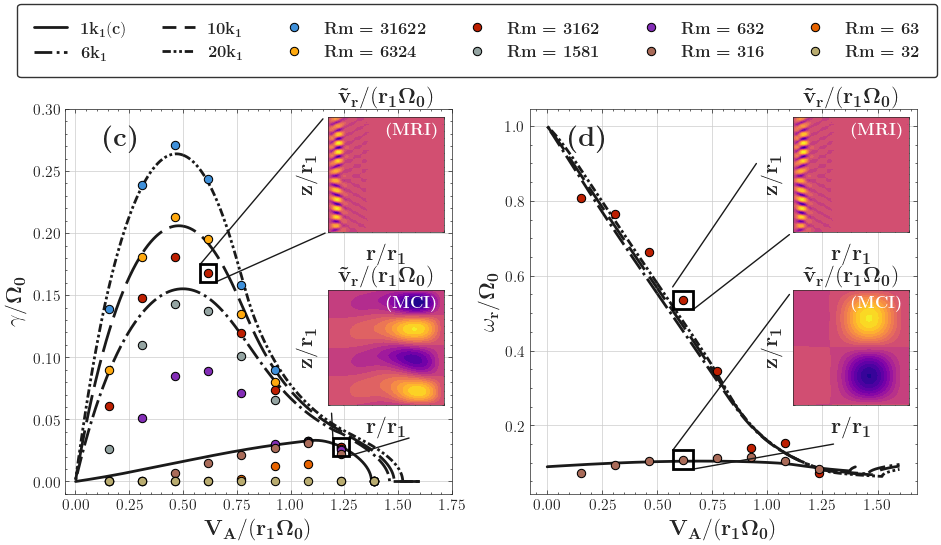

In [52]:
# %%
# fig = plt.figure()
fig, ax = plt.subplots(1,2)
fig.set_figheight(5)
fig.set_figwidth(11)

smrm = 1/2.0510130839719898e-07/10000/25298.2
# smrm=1
W0 = 252982
# Bs = np.asarray([   0 ,    5 ,   10 ,   15 ,   20 ,   25 ,   30 ,   35 ,   40 ,   45 ,   50 ,   55 ,   60 ,   65 ,   70 ,   75 ,   80 ])*smrm
Bs = np.asarray([   0 ,    5 ,   10 ,   15 ,   20 ,   25 ,   30 ,   35 ,   40 ,   45 ,   50 ,   55 ,   60 ,   65 ,   70 ,   75 ,   80 ])/(r1*Omega0*np.sqrt(rho*mu_0)*10000)

gs = [   0 ,    0 ,1.02e4,2.24e4,2.99e4,3.32e4,3.28e4,2.93e4,2.40e4,1.85e4,0.76e4,0.82e4,0.80e4,0.61e4,0.25e4,    0 ,    0 ]

### IMPORT MY DATA
r1_AR1 = 0.1
r2_AR1 = 0.5

## Get Alfven via input data
magB = [10, 20, 30, 40, 50, 60, 70, 80, 90]
vA = magB/np.sqrt(rho*mu_0)/10000

## AR1 Data
eta = ['0.1', '0.5', '1', '2', '5']
eta = ['0.1', '0.5', '1', '2', '5', '10', '50', '100']

### REVISION 3 WITH DTMS DATA
gr_10g = [44016.9, 28334.8, 19181.1,8262.29, 0, 0, 0, 0] ## WAITING ON 10 ETA 5
gr_20g = [75370.2, 57125.3, 46733.3,34777.3, 16046.7, 0, 0,0 ]
gr_30g = [85609.5, 67360.8, 57130.9,45215.5, 26877.8, 2088.13, 0,0]
gr_40g = [77029.5, 61718.3, 53070,43300.4, 28089.2, 4607.29, 0,0]
gr_50g = [50007, 42576.1, 37846,32054.6, 22632.4, 6674.49, 695.382, 0]
gr_60g = [28348.8, 25225.8, 23233.5,20705.8, 9544, 8632.65, 3878.04, 0]
gr_70g = [10148.7, 10339.7, 10378.7,10362, 10150.5, 9701.79, 4383.83, 0] ### OTHER ETA0.1 is 18002.2
gr_80g = [8849.72, 8520.59, 8737.85,8353.78, 8098.38, 6897.13, 0, 0]
gr_90g = [0, 0,0,0, 0, 0, 0, 0]

magB = [10, 20, 30, 40, 50, 60, 70, 80,90]
vA = magB/np.sqrt(rho*mu_0)/10000

gr_tot = [gr_10g, gr_20g, gr_30g, gr_40g, gr_50g, gr_60g, gr_70g, gr_80g,gr_90g]

etaplot_AR1 = []
for i in range(0, len(eta)):
    etai = np.zeros(len(gr_tot))
    for j in range(0, len(gr_tot)):
        etai[j] = gr_tot[j][i]
    etaplot_AR1.append(etai)



# ax = plt.subplot(111)


### SHOOTING

### MCI 
ax[0].plot(VA_h_MCI1,gr_1k1_MCI_l, color = 'k', label=r'$\mathbf{1k_1 (c)}$', linewidth=2)
ax[0].plot(VA_l_MCI1,gr_1k1_MCI_h, color = 'k', linewidth=2)

###### MRI

ax[0].plot(VA_l_MRI6,gr_6k1_MRI_l, label=r'$\mathbf{6k_1}$', color = 'k', linestyle = '-.', linewidth=2)
ax[0].plot(VA_h_MRI6,gr_6k1_MRI_h, color = 'k', linestyle = '-.', linewidth=2)

ax[0].plot(VA_l_MRI10,gr_10k1_MRI_l, label=r'$\mathbf{10k_1}$', color = 'k', linestyle = (5, (10, 3)), linewidth=2)
ax[0].plot(VA_h_MRI10,gr_10k1_MRI_h, color = 'k', linestyle = (5, (10, 3)), linewidth=2)
ax[0]
ax[0].plot(VA_l_MRI20,gr_20k1_MRI_l, label=r'$\mathbf{20k_1}$', color = 'k',linestyle = (0, (3, 1, 1, 1, 1, 1)), linewidth=2)
ax[0].plot(VA_h_MRI20,gr_20k1_MRI_h, color = 'k', linestyle = (0, (3, 1, 1, 1, 1, 1)), linewidth=2)

## Now compare different resisitivites versus the shooting curvature mode.
## PLOT SHOOTING DATA
color_arr = ['#3F90DA', '#FFA90E', '#BD1F01', '#94A4A2', '#832DB6', '#A96B59', '#E76300', '#B9AC70', '#92DADD']

V0 = r1*Omega0
eta_arr = [0.1,0.5,1,2,5,10, 50, 100]
Rm = r1*V0/np.array(eta_arr)
for i in range(0, len(etaplot_AR1)):
    # plt.plot(vA/(r1_AR1*Omega0), etaplot_AR1[i]/(Omega0), 'o', linestyle = '--', label=r'\textbf{Rm = }' + str(int(Rm[i])), color = color_arr[i], markeredgecolor='black', markeredgewidth = 0.75)  
    if(i == 0):
        ax[0].plot(vA/(r1_AR1*Omega0), etaplot_AR1[i]/(Omega0), 'o', label=r'\textbf{Rm = 31622}', color = color_arr[i], markeredgecolor='black', markeredgewidth = 0.75)  
    elif(i == 1):
        ax[0].plot(vA/(r1_AR1*Omega0), etaplot_AR1[i]/(Omega0), 'o', label=r'\textbf{Rm = 6324}', color = color_arr[i], markeredgecolor='black', markeredgewidth = 0.75)  
    elif(i == 2):
        ax[0].plot(vA/(r1_AR1*Omega0), etaplot_AR1[i]/(Omega0), 'o', label=r'\textbf{Rm = 3162}', color = color_arr[i], markeredgecolor='black', markeredgewidth = 0.75)  
    elif(i == 3):
        ax[0].plot(vA/(r1_AR1*Omega0), etaplot_AR1[i]/(Omega0), 'o', label=r'\textbf{Rm = 1581}', color = color_arr[i], markeredgecolor='black', markeredgewidth = 0.75)  
    elif(i == 4):
        ax[0].plot(vA/(r1_AR1*Omega0), etaplot_AR1[i]/(Omega0), 'o', label=r'\textbf{Rm = 632}', color = color_arr[i], markeredgecolor='black', markeredgewidth = 0.75)  
    elif(i == 5):
        ax[0].plot(vA/(r1_AR1*Omega0), etaplot_AR1[i]/(Omega0), 'o', label=r'\textbf{Rm = 316}', color = color_arr[i], markeredgecolor='black', markeredgewidth = 0.75)  
    elif(i == 6):
        ax[0].plot(vA/(r1_AR1*Omega0), etaplot_AR1[i]/(Omega0), 'o', label=r'\textbf{Rm = 63}', color = color_arr[i], markeredgecolor='black', markeredgewidth = 0.75)  
    elif(i == 7):
        ax[0].plot(vA/(r1_AR1*Omega0), etaplot_AR1[i]/(Omega0), 'o', label=r'\textbf{Rm = 32}', color = color_arr[i], markeredgecolor='black', markeredgewidth = 0.75)  

## PLOT SHOOTING DATA

VA_shoot = [1.157*8/10] ## ETA0.1
ETAp1 = [0.02283895391150039]
ETAp5 = [0.01718854743963384]
ETA1 = [0.01717910905775954]
ETA2 = [0.018524447015573035]
ETA5 = [0.020554535400139143]


###################################
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from matplotlib.patches import Rectangle

# ax_inset = inset_axes(ax, width="30%", height="30%", loc='center right')
# ax_inset.axes.xaxis.set_ticklabels([])
# ax_inset.axes.yaxis.set_ticklabels([])
# ax_inset.set_xlabel(r'$\mathbf{r/r_1}$', fontsize = 16)
# ax_inset.set_ylabel(r'$\mathbf{z/r_1}$', fontsize = 16)
# cp2=ax_inset.contourf(rc/0.1,zc/0.1, Vr_Eta5_20G,50, cmap='plasma')
# ax_inset.set_title(r"$\mathbf{\tilde{v}_r/(r_1\Omega_0)}$", fontsize = 16)

# inset_top = fig.add_axes([0.7, 0.3, 0.25, 0.25])  # [left, bottom, width, height]
# inset_top = fig.add_axes([0.7, 0.32, 0.25, 0.25])  # [left, bottom, width, height]

# Get subplot position
pos = ax[0].get_position()

# Define inset axes using figure.add_axes, relative to the subplot's position
inset_top = fig.add_axes([
    pos.x0 + 0.68 * pos.width,  # Left position relative to subplot
    pos.y0 + 0.23 * pos.height, # Bottom position relative to subplot
    0.3 * pos.width,          # Width relative to subplot
    0.3 * pos.height          # Height relative to subplot
])


inset_top.axes.xaxis.set_ticklabels([])
inset_top.axes.yaxis.set_ticklabels([])
inset_top.set_xlabel(r'$\mathbf{r/r_1}$', fontsize = 16)
inset_top.set_ylabel(r'$\mathbf{z/r_1}$', fontsize = 16)
cp2=inset_top.contourf(rc/0.1,zc/0.1, Vr_Eta1_80G,20, cmap='plasma')
inset_top.set_title(r"$\mathbf{\tilde{v}_r/(r_1\Omega_0)}$", fontsize = 16)
inset_top.text(0.5, 0.96, r'\textbf{(MCI)}', transform=inset_top.transAxes, fontsize=12, verticalalignment='top', horizontalalignment='left', color = 'white')



ax_inset = inset_axes(ax[0], width="30%", height="30%", loc='upper right')
ax_inset.axes.xaxis.set_ticklabels([])
ax_inset.axes.yaxis.set_ticklabels([])
ax_inset.set_xlabel(r'$\mathbf{r/r_1}$', fontsize = 16)
ax_inset.set_ylabel(r'$\mathbf{z/r_1}$', fontsize = 16)
cp2=ax_inset.contourf(rc/0.1,zc/0.1, Vr_Eta1_40G,20, cmap='plasma')
ax_inset.set_title(r"$\mathbf{\tilde{v}_r/(r_1\Omega_0)}$", fontsize = 16, pad = 10)
ax_inset.text(0.5, 0.96, r'\textbf{(MRI)}', transform=ax_inset.transAxes, fontsize=12, verticalalignment='top', horizontalalignment='left', color = 'white')


### ETA5
# highlight_x_MRI = (vA/(r1_AR1*Omega0))[3]
# highlight_y_MRI = etaplot_AR1[4][3]/(Omega0)

# highlight_x_MCI = (vA/(r1_AR1*Omega0))[len(vA/(r1_AR1*Omega0))-2]
# highlight_y_MCI = (etaplot_AR1[4]/(Omega0))[len(etaplot_AR1[0]/(Omega0))-2]

highlight_x_MRI = (vA/(r1_AR1*Omega0))[3]
highlight_y_MRI = etaplot_AR1[2][3]/(Omega0)

highlight_x_MCI = (vA/(r1_AR1*Omega0))[len(vA/(r1_AR1*Omega0))-2]
highlight_y_MCI = (etaplot_AR1[2]/(Omega0))[len(etaplot_AR1[0]/(Omega0))-2]


# Define the center and size of the rectangle
width = 0.075  # Width of the rectangle
height = 0.02*0.7  # Height of the rectangle

# Calculate the bottom-left corner coordinates
x = highlight_x_MCI - width / 2
y = highlight_y_MCI - height / 2

rect_x = x
rect_y = y
rect_width = width 
rect_height = height

# Define the rectangle's corners in the main plot
main_rect_corners = [
    (rect_x, rect_y),  # Bottom-left corner
    (rect_x + rect_width, rect_y),  # Bottom-right corner
    (rect_x, rect_y + rect_height),  # Top-left corner
    (rect_x + rect_width, rect_y + rect_height)  # Top-right corner
]

# Create a rectangle
rect = Rectangle((x, y), width, height, linewidth=2, edgecolor='black', facecolor='none', zorder=3)
ax[0].add_patch(rect)

################### PLOT LINES
# pt2 = [1.15, 0.05]
pt2 = [1.55, 0.035]
pt3 = [1.19, 0.055]

line1X = [main_rect_corners[1][0], pt2[0]]
line1Y = [main_rect_corners[1][1],pt2[1]] 
line2X = [main_rect_corners[0][0], pt3[0]]
line2Y = [main_rect_corners[2][1],pt3[1]]
ax[0].plot(line1X, line1Y, color = 'k', zorder=2)
ax[0].plot(line2X, line2Y, color = 'k', zorder=2)

############### MRI
# Define the center and size of the rectangle
width = 0.075  # Width of the rectangle
height = 0.02*0.7  # Height of the rectangle

# Calculate the bottom-left corner coordinates
x = highlight_x_MRI - width / 2
y = highlight_y_MRI - height / 2

rect_x = x
rect_y = y
rect_width = width 
rect_height = height

# Define the rectangle's corners in the main plot
main_rect_corners = [
    (rect_x, rect_y),  # Bottom-left corner
    (rect_x + rect_width, rect_y),  # Bottom-right corner
    (rect_x, rect_y + rect_height),  # Top-left corner
    (rect_x + rect_width, rect_y + rect_height)  # Top-right corner
]

# Create a rectangle
rect = Rectangle((x, y), width, height, linewidth=2, edgecolor='black', facecolor='none', zorder=3)
ax[0].add_patch(rect)

################### PLOT LINES
pt2 = [1.16, 0.2]
pt3 = [1.15, 0.292]

line1X = [main_rect_corners[1][0], pt2[0]]
line1Y = [main_rect_corners[0][1],pt2[1]] 
line2X = [main_rect_corners[0][0], pt3[0]]
line2Y = [main_rect_corners[2][1],pt3[1]]
# line2X = [main_rect_corners[0][0], pt3[0]]
# line2Y = [main_rect_corners[2][1],pt3[1]]
ax[0].plot(line1X, line1Y, color = 'k', zorder=2)
ax[0].plot(line2X, line2Y, color = 'k', zorder=2)

# print(eta_arr)
# print(eta_arr[4])
ax[0].set_ylim(-0.01, 0.3)
ax[0].set_xlim(-0.05, 1.75)
####################################### Frequency

### MCI 
ax[1].plot(VA_h_MCI1,freq_1k1_MCI_l, color = 'k', linewidth=2)
ax[1].plot(VA_l_MCI1,freq_1k1_MCI_h, color = 'k', linewidth=2)
### MRI

ax[1].plot(VA_l_MRI6,freq_6k1_MRI_l, color = 'k', linestyle = '-.', linewidth=2)
ax[1].plot(VA_h_MRI6,freq_6k1_MRI_h, color = 'k', linestyle = '-.', linewidth=2)

ax[1].plot(VA_l_MRI10,freq_10k1_MRI_l, color = 'k', linestyle = (5, (10, 3)), linewidth=2)
ax[1].plot(VA_h_MRI10,freq_10k1_MRI_h, color = 'k', linestyle = (5, (10, 3)), linewidth=2)

ax[1].plot(VA_l_MRI20,freq_20k1_MRI_l, color = 'k',linestyle = (0, (3, 1, 1, 1, 1, 1)), linewidth=2)
ax[1].plot(VA_h_MRI20,freq_20k1_MRI_h, color = 'k', linestyle = (0, (3, 1, 1, 1, 1, 1)), linewidth=2)

ETA1_freq = [0.7947670612636882, 0.6479079303780066,0.6891891490662979,0.5519215703220056, 0.3010481292665485, 0.2536490621054323,0.09645231326015632,0.10277160274961485 ]
ETA1_freq = [0.8221728219969188, 0.7012650540561954, 0.6623058843864067, 0.5259487905421465, 0.29803764797388305, 0.27094331633989366,0.10277160274961485 ,0.10277160274961485]
ETA1_freq = [0.8071852965959332, 0.7641990973689308, 0.6623058843864067, 0.5349393681582516, 0.34524455675461635, 0.13887058866166593,0.15255007574018656 ,0.07306577372234381]
ETA10_freq = [	0.07386310978287064, 0.0952958107030801, 0.10479523487126687, .10821991574941284, 0.11289304847495568, 0.11468500162535179, 0.10413614534377463, 0.08339633381570703] 
VA1 = np.array([10, 20, 30, 40, 50, 60, 70,80])/10000/ np.sqrt(rho*mu_0)/(r1*Omega0)

VA5 = np.array([20, 30, 40, 50, 60, 70,80])/10000/ np.sqrt(rho*mu_0)/(r1*Omega0)
ETA5_freq = [0.607429111108676, 0.5916923893599149, 0.32962689176834986, 0.2189664352461181, 0.09461512634091525, 0.08545882379179442, 0.0917038916842717]
ax[1].plot(VA1, ETA1_freq, marker = 'o', color = color_arr[2], markeredgecolor='black', markeredgewidth = 0.75, linestyle = '')  
ax[1].plot(VA1, ETA10_freq, marker = 'o', color = color_arr[5], markeredgecolor='black', markeredgewidth = 0.75, linestyle = '')


# Get subplot position
pos = ax[1].get_position()

# Define inset axes using figure.add_axes, relative to the subplot's position
inset_top = fig.add_axes([
    pos.x0 + 0.68 * pos.width,  # Left position relative to subplot
    pos.y0 + 0.23 * pos.height, # Bottom position relative to subplot
    0.3 * pos.width,          # Width relative to subplot
    0.3 * pos.height          # Height relative to subplot
])


inset_top.axes.xaxis.set_ticklabels([])
inset_top.axes.yaxis.set_ticklabels([])
inset_top.set_xlabel(r'$\mathbf{r/r_1}$', fontsize = 16)
inset_top.set_ylabel(r'$\mathbf{z/r_1}$', fontsize = 16)
cp2=inset_top.contourf(rc/0.1,zc/0.1, Vr_Eta10_40G,20, cmap='plasma')
inset_top.set_title(r"$\mathbf{\tilde{v}_r/(r_1\Omega_0)}$", fontsize = 16)
inset_top.text(0.5, 0.96, r'\textbf{(MCI)}', transform=inset_top.transAxes, fontsize=12, verticalalignment='top', horizontalalignment='left', color = 'white')



ax_inset = inset_axes(ax[1], width="30%", height="30%", loc='upper right')
ax_inset.axes.xaxis.set_ticklabels([])
ax_inset.axes.yaxis.set_ticklabels([])
ax_inset.set_xlabel(r'$\mathbf{r/r_1}$', fontsize = 16)
ax_inset.set_ylabel(r'$\mathbf{z/r_1}$', fontsize = 16)
cp2=ax_inset.contourf(rc/0.1,zc/0.1, Vr_Eta1_40G,20, cmap='plasma')
ax_inset.set_title(r"$\mathbf{\tilde{v}_r/(r_1\Omega_0)}$", fontsize = 16, pad = 10)
ax_inset.text(0.5, 0.96, r'\textbf{(MRI)}', transform=ax_inset.transAxes, fontsize=12, verticalalignment='top', horizontalalignment='left', color = 'white')



ax[0].set_xlabel(r'$\mathbf{{V_A}/(r_1\Omega_0)}$', fontsize = 16)
ax[0].set_ylabel(r'$\mathbf{\gamma/\Omega_0}$', fontsize = 16)
ax[1].set_xlabel(r'$\mathbf{{V_A}/(r_1\Omega_0)}$', fontsize = 16)
ax[1].set_ylabel(r'$\mathbf{\omega_r/\Omega_0}$', fontsize = 16)

##############################################################
highlight_x_MRI = (vA/(r1_AR1*Omega0))[3]
highlight_y_MRI = ETA1_freq[3]

highlight_x_MCI = (vA/(r1_AR1*Omega0))[3]
highlight_y_MCI = ETA10_freq[3]


# Define the center and size of the rectangle
width = 0.075*1.25  # Width of the rectangle
height = 0.02*2*1.25  # Height of the rectangle

# Calculate the bottom-left corner coordinates
x = highlight_x_MCI - width / 2
y = highlight_y_MCI - height / 2

rect_x = x
rect_y = y
rect_width = width 
rect_height = height

# Define the rectangle's corners in the main plot
main_rect_corners = [
    (rect_x, rect_y),  # Bottom-left corner
    (rect_x + rect_width, rect_y),  # Bottom-right corner
    (rect_x, rect_y + rect_height),  # Top-left corner
    (rect_x + rect_width, rect_y + rect_height)  # Top-right corner
]

# Create a rectangle
rect = Rectangle((x, y), width, height, linewidth=2, edgecolor='black', facecolor='none', zorder=3)
ax[1].add_patch(rect)

################### PLOT LINES
# pt2 = [1.15, 0.05]
# pt2 = [1.55, 0.2]
pt2 = [1.3, 0.15]
# pt3 = [1., 0.5]
pt3 = [1.1, 0.55]

line1X = [main_rect_corners[1][0], pt2[0]]
line1Y = [main_rect_corners[1][1],pt2[1]] 
line2X = [main_rect_corners[0][0], pt3[0]]
line2Y = [main_rect_corners[2][1],pt3[1]]
ax[1].plot(line1X, line1Y, color = 'k', zorder=2)
ax[1].plot(line2X, line2Y, color = 'k', zorder=2)

############### MRI
# Define the center and size of the rectangle
width = 0.075*1.25  # Width of the rectangle
height = 0.02*2*1.25  # Height of the rectangle

# Calculate the bottom-left corner coordinates
x = highlight_x_MRI - width / 2
y = highlight_y_MRI - height / 2

rect_x = x
rect_y = y
rect_width = width 
rect_height = height

# Define the rectangle's corners in the main plot
main_rect_corners = [
    (rect_x, rect_y),  # Bottom-left corner
    (rect_x + rect_width, rect_y),  # Bottom-right corner
    (rect_x, rect_y + rect_height),  # Top-left corner
    (rect_x + rect_width, rect_y + rect_height)  # Top-right corner
]

# Create a rectangle
rect = Rectangle((x, y), width, height, linewidth=2, edgecolor='black', facecolor='none', zorder=3)
ax[1].add_patch(rect)

################### PLOT LINES
pt2 = [1.1, 1.16]
pt2 = [.95, .9]
pt3 = [1.1, 0.71]

line1X = [main_rect_corners[0][0], pt2[0]]
line1Y = [main_rect_corners[2][0],pt2[1]] 
line2X = [main_rect_corners[1][0], pt3[0]]
line2Y = [main_rect_corners[1][1],pt3[1]]
# line2X = [main_rect_corners[0][0], pt3[0]]
# line2Y = [main_rect_corners[2][1],pt3[1]]
ax[1].plot(line1X, line1Y, color = 'k', zorder=2)
ax[1].plot(line2X, line2Y, color = 'k', zorder=2)


############################################################################

box = ax[0].get_position()
lines_labels = [ax.get_legend_handles_labels() for ax in fig.axes]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]

# fig.legend(lines, labels, loc='lower center', ncol=6, 
#            bbox_to_anchor=(0.5, -0.15),  # Position the legend below the plot
#            frameon=False,  # Turn on the frame (border)
#            edgecolor='black',  # Set the border color
#            facecolor='white',  # Set the background color of the legend box
#            borderpad=1,  # Padding between the legend text and the border
#            borderaxespad=1, fontsize = 12)

fig.legend(lines, labels, loc='lower center', ncol=6, 
           bbox_to_anchor=(0.5, 0.91),  # Position the legend below the plot
           frameon=True,  # Turn on the frame (border)
           edgecolor='black',  # Set the border color
           facecolor='white',  # Set the background color of the legend box
           borderpad=1,  # Padding between the legend text and the border
           borderaxespad=1, fontsize = 12)


ax[0].text(0.1, 0.96, r'\textbf{(c)}', transform=ax[0].transAxes, fontsize=20, verticalalignment='top', horizontalalignment='left')
ax[1].text(0.1, 0.96, r'\textbf{(d)}', transform=ax[1].transAxes, fontsize=20, verticalalignment='top', horizontalalignment='left')

plt.savefig('Shooting-NIMROD-comp/GRvsAlfvenSpeed-NIMROD-Az-w-comb.png', bbox_inches='tight', dpi = 400)
plt.savefig('Shooting-NIMROD-comp/GRvsAlfvenSpeed-NIMROD-Az-w-comb.pdf', bbox_inches='tight', dpi = 400)

plt.show()
plt.close()

# Plot Resistive Shooting

# Plot WKB

[array([44016.9 , 75370.2 , 85609.5 , 77029.5 , 50007.  , 28348.8 ,
       10148.7 ,  8849.72,     0.  ]), array([28334.8 , 57125.3 , 67360.8 , 61718.3 , 42576.1 , 25225.8 ,
       10339.7 ,  8520.59,     0.  ]), array([19181.1 , 46733.3 , 57130.9 , 53070.  , 37846.  , 23233.5 ,
       10378.7 ,  8737.85,     0.  ]), array([ 8262.29, 34777.3 , 45215.5 , 43300.4 , 32054.6 , 20705.8 ,
       10362.  ,  8353.78,     0.  ]), array([    0.  , 16046.7 , 26877.8 , 28089.2 , 22632.4 ,  9544.  ,
       10150.5 ,  8098.38,     0.  ]), array([   0.  ,    0.  , 2088.13, 4607.29, 6674.49, 8632.65, 9701.79,
       6897.13,    0.  ]), array([   0.   ,    0.   ,    0.   ,    0.   ,  695.382, 3878.04 ,
       4383.83 ,    0.   ,    0.   ]), array([0., 0., 0., 0., 0., 0., 0., 0., 0.])]


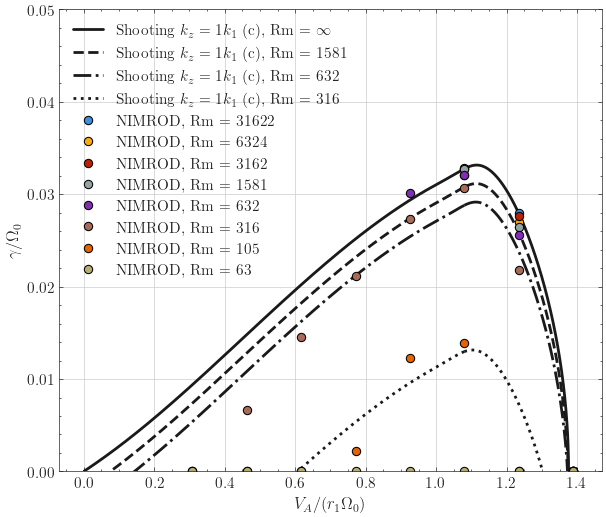

In [42]:
# %%
smrm = 1/2.0510130839719898e-07/10000/25298.2
# smrm=1
W0 = 252982
# Bs = np.asarray([   0 ,    5 ,   10 ,   15 ,   20 ,   25 ,   30 ,   35 ,   40 ,   45 ,   50 ,   55 ,   60 ,   65 ,   70 ,   75 ,   80 ])*smrm
Bs = np.asarray([   0 ,    5 ,   10 ,   15 ,   20 ,   25 ,   30 ,   35 ,   40 ,   45 ,   50 ,   55 ,   60 ,   65 ,   70 ,   75 ,   80 ])/(r1*Omega0*np.sqrt(rho*mu_0)*10000)

gs = [   0 ,    0 ,1.02e4,2.24e4,2.99e4,3.32e4,3.28e4,2.93e4,2.40e4,1.85e4,0.76e4,0.82e4,0.80e4,0.61e4,0.25e4,    0 ,    0 ]

### IMPORT MY DATA
r1_AR1 = 0.1
r2_AR1 = 0.5

## Get Alfven via input data
magB = [10, 20, 30, 40, 50, 60, 70, 80, 90]
vA = magB/np.sqrt(rho*mu_0)/10000

## AR1 Data
eta = ['0.1', '0.5', '1', '2', '5']
eta = ['0.1', '0.5', '1', '2', '5', '10', '50', '100']

### REVISION 3 WITH DTMS DATA
gr_10g = [44016.9, 28334.8, 19181.1,8262.29, 0, 0, 0, 0] ## WAITING ON 10 ETA 5
gr_20g = [75370.2, 57125.3, 46733.3,34777.3, 16046.7, 0, 0,0 ]
gr_30g = [85609.5, 67360.8, 57130.9,45215.5, 26877.8, 2088.13, 0,0]
gr_40g = [77029.5, 61718.3, 53070,43300.4, 28089.2, 4607.29, 0,0]
gr_50g = [50007, 42576.1, 37846,32054.6, 22632.4, 6674.49, 695.382, 0]
gr_60g = [28348.8, 25225.8, 23233.5,20705.8, 9544, 8632.65, 3878.04, 0]
gr_70g = [10148.7, 10339.7, 10378.7,10362, 10150.5, 9701.79, 4383.83, 0] ### OTHER ETA0.1 is 18002.2
gr_80g = [8849.72, 8520.59, 8737.85,8353.78, 8098.38, 6897.13, 0, 0]
# gr_90g = [10127.7, 9613.43, 9315.53,8896.36, 9541.62, 0, 0, 0]
gr_90g = [0, 0,0,0, 0, 0, 0, 0]

magB = [10, 20, 30, 40, 50, 60, 70, 80,90]
vA = magB/np.sqrt(rho*mu_0)/10000

gr_tot = [gr_10g, gr_20g, gr_30g, gr_40g, gr_50g, gr_60g, gr_70g, gr_80g,gr_90g]

etaplot_AR1 = []
for i in range(0, len(eta)):
    etai = np.zeros(len(gr_tot))
    for j in range(0, len(gr_tot)):
        etai[j] = gr_tot[j][i]
    etaplot_AR1.append(etai)

V0 = r1*Omega0
eta_arr = [0.1, 0.5, 1, 2,5, 10, 30, 50, 100]
Rm = r1*V0/np.array(eta_arr) 


# fig = plt.figure()
fig = plt.figure(figsize = (7,6))
color_arr = ['#3F90DA', '#FFA90E', '#BD1F01', '#94A4A2', '#832DB6', '#A96B59', '#E76300', '#B9AC70', '#92DADD']


### MCI 
plt.plot(VA_h_MCI1,gr_1k1_MCI_l, color = 'k', label=r'Shooting $k_z = 1k_1$ (c), Rm = $\infty$', linewidth=2) 
plt.plot(VA_l_MCI1,gr_1k1_MCI_h, color = 'k', linewidth=2) 

### WKB
plt.plot(VA_l_MCI1_Az_ETA5_divr_WKB_div4,gr_1k1_MCI_l_Az_ETA5_divr_WKB_div4, 'k', linestyle = '--', label =f'Shooting $k_z = 1k_1$ (c), Rm = {int(Rm[3])}', linewidth=2)
plt.plot(VA_h_MCI1_Az_ETA5_divr_WKB_div4,gr_1k1_MCI_h_Az_ETA5_divr_WKB_div4, 'k', linestyle = '--', linewidth=2)    

plt.plot(VA_l_MCI1_Az_ETA10_divr_WKB_div4,gr_1k1_MCI_l_Az_ETA10_divr_WKB_div4, 'k', linestyle = '-.', label =f'Shooting $k_z = 1k_1$ (c), Rm = {int(Rm[4])}', linewidth=2)
plt.plot(VA_h_MCI1_Az_ETA10_divr_WKB_div4,gr_1k1_MCI_h_Az_ETA10_divr_WKB_div4, 'k', linestyle = '-.', linewidth=2)    

plt.plot(VA_l_MCI1_Az_ETA50_divr_WKB_div4,gr_1k1_MCI_l_Az_ETA50_divr_WKB_div4, 'k', linestyle = ':', label =f'Shooting $k_z = 1k_1$ (c), Rm = {int(Rm[5])}', linewidth=2)
plt.plot(VA_h_MCI1_Az_ETA50_divr_WKB_div4,gr_1k1_MCI_h_Az_ETA50_divr_WKB_div4, 'k', linestyle = ':', linewidth=2)    

# for i in range(0, len(etaplot_AR1)):
#     ## Note 8/10 because of scaling w/ bb of other sims
#     plt.plot(vA[1:len(vA)]/(r1_AR1*Omega0), etaplot_AR1[i][1:len(vA)]/(Omega0), 'o', linestyle = '--', label=r'NIMROD $\eta =$' + str(eta[i]), color = color_arr[i])
# ## PLOT SHOOTING DATA

i = 0
plt.plot(vA[6:len(vA)]/(r1_AR1*Omega0), etaplot_AR1[i][6:len(vA)]/(Omega0), 'o', label=f'NIMROD, Rm = {np.round(int(Rm[0]),0)}', color = color_arr[i], markeredgecolor='black', markeredgewidth = 0.75)  
i = 1
plt.plot(vA[6:len(vA)]/(r1_AR1*Omega0), etaplot_AR1[i][6:len(vA)]/(Omega0), 'o', label=f'NIMROD, Rm = {np.round(int(Rm[1]),0)}', color = color_arr[i], markeredgecolor='black', markeredgewidth = 0.75)  
i = 2
plt.plot(vA[6:len(vA)]/(r1_AR1*Omega0), etaplot_AR1[i][6:len(vA)]/(Omega0), 'o', label=f'NIMROD, Rm = {np.round(int(Rm[2]),0)}', color = color_arr[i], markeredgecolor='black', markeredgewidth = 0.75)  
i = 3
plt.plot(vA[6:len(vA)]/(r1_AR1*Omega0), etaplot_AR1[i][6:len(vA)]/(Omega0), 'o', label=f'NIMROD, Rm = {np.round(int(Rm[3]),0)}', color = color_arr[i], markeredgecolor='black', markeredgewidth = 0.75)  
i = 4
plt.plot(vA[5:len(vA)]/(r1_AR1*Omega0), etaplot_AR1[i][5:len(vA)]/(Omega0), 'o', label=f'NIMROD, Rm = {np.round(int(Rm[4]),0)}', color = color_arr[i], markeredgecolor='black', markeredgewidth = 0.75)  
i = 5
plt.plot(vA[1:len(vA)]/(r1_AR1*Omega0), etaplot_AR1[i][1:len(vA)]/(Omega0), 'o', label=f'NIMROD, Rm = {np.round(int(Rm[5]),0)}', color = color_arr[i], markeredgecolor='black', markeredgewidth = 0.75)  
i = 6
plt.plot(vA[1:len(vA)]/(r1_AR1*Omega0), etaplot_AR1[i][1:len(vA)]/(Omega0), 'o', label=f'NIMROD, Rm = {np.round(int(Rm[6]),0)}', color = color_arr[i], markeredgecolor='black', markeredgewidth = 0.75)  
i = 7
plt.plot(vA[1:len(vA)]/(r1_AR1*Omega0), etaplot_AR1[i][1:len(vA)]/(Omega0), 'o', label=f'NIMROD, Rm = {np.round(int(Rm[7]),0)}', color = color_arr[i], markeredgecolor='black', markeredgewidth = 0.75)  


print(etaplot_AR1)
# color_arr = ['dodgerblue', 'mediumorchid', 'midnightblue', 'springgreen', 'tomato', 'k']


# plt.plot(VA_l_MCI1_Az_ETA1_divr_q2mag9,gr_1k1_MCI_l_Az_ETA1_divr_q2mag9, 'k', label =f'Shooting $k_z = 1k_1$ (c), $\eta = 1$', linewidth=2, linestyle = '--') 
# plt.plot(VA_h_MCI1_Az_ETA1_divr_q2mag9,gr_1k1_MCI_h_Az_ETA1_divr_q2mag9, 'k', linewidth=2, linestyle = '--')    

# plt.plot(VA_l_MCI1_Az_ETA5_divr_q2mag9,gr_1k1_MCI_l_Az_ETA5_divr_q2mag9, 'k', linestyle = '--', label =f'Shooting $k_z = 1k_1$ (c), $\eta = 5, q^2 \sim 9$', linewidth=2)
# plt.plot(VA_h_MCI1_Az_ETA5_divr_q2mag9,gr_1k1_MCI_h_Az_ETA5_divr_q2mag9, 'k', linestyle = '--', linewidth=2)    

# plt.plot(VA_l_MCI1_Az_ETA10_divr_q2mag9,gr_1k1_MCI_l_Az_ETA10_divr_q2mag9, 'k', linestyle = '-.', label =f'Shooting $k_z = 1k_1$ (c), $\eta = 10$', linewidth=2)
# plt.plot(VA_h_MCI1_Az_ETA10_divr_q2mag9,gr_1k1_MCI_h_Az_ETA10_divr_q2mag9, 'k', linestyle = '-.', linewidth=2)    

# plt.plot(VA_l_MCI1_Az_ETA50_divr_q2mag9,gr_1k1_MCI_l_Az_ETA50_divr_q2mag9, 'k', linestyle = ':', label =f'Shooting $k_z = 1k_1$ (c), $\eta = 50$', linewidth=2)
# plt.plot(VA_h_MCI1_Az_ETA50_divr_q2mag9,gr_1k1_MCI_h_Az_ETA50_divr_q2mag9, 'k', linestyle = ':', linewidth=2)    

# # qmag 4
# plt.plot(VA_l_MCI1_Az_ETA50_divr_q2mag16,gr_1k1_MCI_l_Az_ETA50_divr_q2mag16, 'k', linestyle = ':', label =f'Shooting $k_z = 1k_1$ (c), $\eta = 50, q^2 \sim 9$', linewidth=2)
# plt.plot(VA_h_MCI1_Az_ETA50_divr_q2mag16,gr_1k1_MCI_h_Az_ETA50_divr_q2mag16, 'k', linestyle = ':', linewidth=2)    

###### MRI

VA_shoot = [1.157*8/10] ## ETA0.1
ETAp1 = [0.02283895391150039]
ETAp5 = [0.01718854743963384]
ETA1 = [0.01717910905775954]
ETA2 = [0.018524447015573035]
ETA5 = [0.020554535400139143]

plt.plot()
plt.xlabel(r'${V_A}/(r_1\Omega_0)$')
plt.ylabel(r'$\gamma/\Omega_0$')
# plt.title('Azimuthal field growth rates (Resistive shooting vs NIMROD) \n' + r'$q^2(r) = (\pi/4)^2 - i(\pi/4)/r$',fontsize=15)
plt.legend()
# ax.legend()
plt.ylim(0,0.05)
plt.savefig('Shooting-NIMROD-comp/GRvsAlfvenSpeed-NIMROD-Az-WKB-v2.png', bbox_inches='tight')
plt.savefig('Shooting-NIMROD-comp/GRvsAlfvenSpeed-NIMROD-Az-WKB-v2.svg', bbox_inches='tight', format = 'svg')

plt.show()
plt.close()

# Plot q2magpisq 

[array([44016.9 , 75370.2 , 85609.5 , 77029.5 , 50007.  , 28348.8 ,
       10148.7 ,  8849.72,     0.  ]), array([28334.8 , 57125.3 , 67360.8 , 61718.3 , 42576.1 , 25225.8 ,
       10339.7 ,  8520.59,     0.  ]), array([19181.1 , 46733.3 , 57130.9 , 53070.  , 37846.  , 23233.5 ,
       10378.7 ,  8737.85,     0.  ]), array([ 8262.29, 34777.3 , 45215.5 , 43300.4 , 32054.6 , 20705.8 ,
       10362.  ,  8353.78,     0.  ]), array([    0.  , 16046.7 , 26877.8 , 28089.2 , 22632.4 ,  9544.  ,
       10150.5 ,  8098.38,     0.  ]), array([   0.  ,    0.  , 2088.13, 4607.29, 6674.49, 8632.65, 9701.79,
       6897.13,    0.  ]), array([   0.   ,    0.   ,    0.   ,    0.   ,  695.382, 3878.04 ,
       4383.83 ,    0.   ,    0.   ]), array([0., 0., 0., 0., 0., 0., 0., 0., 0.])]


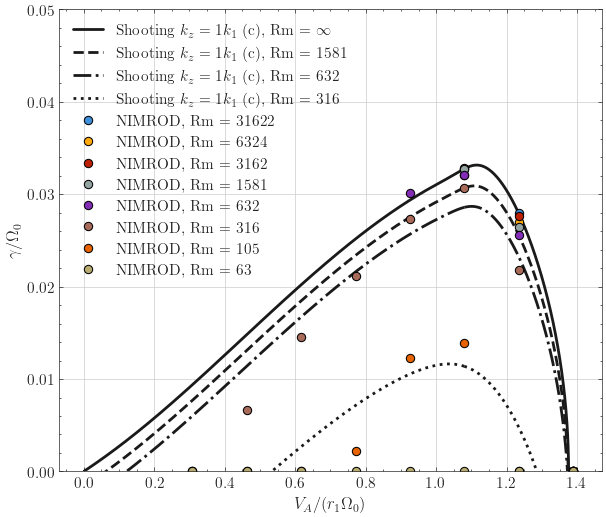

In [43]:
plt.close()
# %%
smrm = 1/2.0510130839719898e-07/10000/25298.2
# smrm=1
W0 = 252982
# Bs = np.asarray([   0 ,    5 ,   10 ,   15 ,   20 ,   25 ,   30 ,   35 ,   40 ,   45 ,   50 ,   55 ,   60 ,   65 ,   70 ,   75 ,   80 ])*smrm
Bs = np.asarray([   0 ,    5 ,   10 ,   15 ,   20 ,   25 ,   30 ,   35 ,   40 ,   45 ,   50 ,   55 ,   60 ,   65 ,   70 ,   75 ,   80 ])/(r1*Omega0*np.sqrt(rho*mu_0)*10000)

gs = [   0 ,    0 ,1.02e4,2.24e4,2.99e4,3.32e4,3.28e4,2.93e4,2.40e4,1.85e4,0.76e4,0.82e4,0.80e4,0.61e4,0.25e4,    0 ,    0 ]

### IMPORT MY DATA
r1_AR1 = 0.1
r2_AR1 = 0.5

## Get Alfven via input data
magB = [10, 20, 30, 40, 50, 60, 70, 80, 90]
vA = magB/np.sqrt(rho*mu_0)/10000

## AR1 Data
eta = ['0.1', '0.5', '1', '2', '5']
eta = ['0.1', '0.5', '1', '2', '5', '10', '50', '100']

### REVISION 3 WITH DTMS DATA
gr_10g = [44016.9, 28334.8, 19181.1,8262.29, 0, 0, 0, 0] ## WAITING ON 10 ETA 5
gr_20g = [75370.2, 57125.3, 46733.3,34777.3, 16046.7, 0, 0,0 ]
gr_30g = [85609.5, 67360.8, 57130.9,45215.5, 26877.8, 2088.13, 0,0]
gr_40g = [77029.5, 61718.3, 53070,43300.4, 28089.2, 4607.29, 0,0]
gr_50g = [50007, 42576.1, 37846,32054.6, 22632.4, 6674.49, 695.382, 0]
gr_60g = [28348.8, 25225.8, 23233.5,20705.8, 9544, 8632.65, 3878.04, 0]
gr_70g = [10148.7, 10339.7, 10378.7,10362, 10150.5, 9701.79, 4383.83, 0] ### OTHER ETA0.1 is 18002.2
gr_80g = [8849.72, 8520.59, 8737.85,8353.78, 8098.38, 6897.13, 0, 0]
# gr_90g = [10127.7, 9613.43, 9315.53,8896.36, 9541.62, 0, 0, 0]
gr_90g = [0, 0,0,0, 0, 0, 0, 0]

magB = [10, 20, 30, 40, 50, 60, 70, 80,90]
vA = magB/np.sqrt(rho*mu_0)/10000

gr_tot = [gr_10g, gr_20g, gr_30g, gr_40g, gr_50g, gr_60g, gr_70g, gr_80g,gr_90g]

etaplot_AR1 = []
for i in range(0, len(eta)):
    etai = np.zeros(len(gr_tot))
    for j in range(0, len(gr_tot)):
        etai[j] = gr_tot[j][i]
    etaplot_AR1.append(etai)

# fig = plt.figure()
fig = plt.figure(figsize = (7,6))
color_arr = ['#3F90DA', '#FFA90E', '#BD1F01', '#94A4A2', '#832DB6', '#A96B59', '#E76300', '#B9AC70', '#92DADD']

# for i in range(0, len(etaplot_AR1)):
#     ## Note 8/10 because of scaling w/ bb of other sims
#     plt.plot(vA[1:len(vA)]/(r1_AR1*Omega0), etaplot_AR1[i][1:len(vA)]/(Omega0), 'o', linestyle = '--', label=r'NIMROD $\eta =$' + str(eta[i]), color = color_arr[i])
### MCI 
plt.plot(VA_h_MCI1,gr_1k1_MCI_l, color = 'k', label=r'Shooting $k_z = 1k_1$ (c), Rm = $\infty$', linewidth=2) 
plt.plot(VA_l_MCI1,gr_1k1_MCI_h, color = 'k', linewidth=2) 

plt.plot(VA_l_MCI1_Az_ETA5_divr_q2magpisq,gr_1k1_MCI_l_Az_ETA5_divr_q2magpisq, 'k', linestyle = '--', label =f'Shooting $k_z = 1k_1$ (c), Rm = {int(Rm[3])}', linewidth=2)
plt.plot(VA_h_MCI1_Az_ETA5_divr_q2magpisq,gr_1k1_MCI_h_Az_ETA5_divr_q2magpisq, 'k', linestyle = '--', linewidth=2)    

plt.plot(VA_l_MCI1_Az_ETA10_divr_q2magpisq,gr_1k1_MCI_l_Az_ETA10_divr_q2magpisq, 'k', linestyle = '-.', label =f'Shooting $k_z = 1k_1$ (c), Rm = {int(Rm[4])}', linewidth=2)
plt.plot(VA_h_MCI1_Az_ETA10_divr_q2magpisq,gr_1k1_MCI_h_Az_ETA10_divr_q2magpisq, 'k', linestyle = '-.', linewidth=2)    

plt.plot(VA_l_MCI1_Az_ETA50_divr_q2magpisq,gr_1k1_MCI_l_Az_ETA50_divr_q2magpisq, 'k', linestyle = ':', label =f'Shooting $k_z = 1k_1$ (c), Rm = {int(Rm[5])}', linewidth=2)
plt.plot(VA_h_MCI1_Az_ETA50_divr_q2magpisq,gr_1k1_MCI_h_Az_ETA50_divr_q2magpisq, 'k', linestyle = ':', linewidth=2)    

i = 0
plt.plot(vA[6:len(vA)]/(r1_AR1*Omega0), etaplot_AR1[i][6:len(vA)]/(Omega0), 'o', label=f'NIMROD, Rm = {int(Rm[0])}', color = color_arr[i], markeredgecolor='black', markeredgewidth = 0.75)  
i = 1
plt.plot(vA[6:len(vA)]/(r1_AR1*Omega0), etaplot_AR1[i][6:len(vA)]/(Omega0), 'o', label=f'NIMROD, Rm = {int(Rm[1])}', color = color_arr[i], markeredgecolor='black', markeredgewidth = 0.75)  
i = 2
plt.plot(vA[6:len(vA)]/(r1_AR1*Omega0), etaplot_AR1[i][6:len(vA)]/(Omega0), 'o', label=f'NIMROD, Rm = {int(Rm[2])}', color = color_arr[i], markeredgecolor='black', markeredgewidth = 0.75)  
i = 3
plt.plot(vA[6:len(vA)]/(r1_AR1*Omega0), etaplot_AR1[i][6:len(vA)]/(Omega0), 'o', label=f'NIMROD, Rm = {int(Rm[3])}', color = color_arr[i], markeredgecolor='black', markeredgewidth = 0.75)  
i = 4
plt.plot(vA[5:len(vA)]/(r1_AR1*Omega0), etaplot_AR1[i][5:len(vA)]/(Omega0), 'o', label=f'NIMROD, Rm = {int(Rm[4])}', color = color_arr[i], markeredgecolor='black', markeredgewidth = 0.75)  
i = 5
plt.plot(vA[1:len(vA)]/(r1_AR1*Omega0), etaplot_AR1[i][1:len(vA)]/(Omega0), 'o', label=f'NIMROD, Rm = {int(Rm[5])}', color = color_arr[i], markeredgecolor='black', markeredgewidth = 0.75)  
i = 6
plt.plot(vA[1:len(vA)]/(r1_AR1*Omega0), etaplot_AR1[i][1:len(vA)]/(Omega0), 'o', label=f'NIMROD, Rm = {int(Rm[6])}', color = color_arr[i], markeredgecolor='black', markeredgewidth = 0.75)  
i = 7
plt.plot(vA[1:len(vA)]/(r1_AR1*Omega0), etaplot_AR1[i][1:len(vA)]/(Omega0), 'o', label=f'NIMROD, Rm = {int(Rm[7])}', color = color_arr[i], markeredgecolor='black', markeredgewidth = 0.75)  


## PLOT SHOOTING DATA

print(etaplot_AR1)
# color_arr = ['dodgerblue', 'mediumorchid', 'midnightblue', 'springgreen', 'tomato', 'k']


###### MRI

VA_shoot = [1.157*8/10] ## ETA0.1
ETAp1 = [0.02283895391150039]
ETAp5 = [0.01718854743963384]
ETA1 = [0.01717910905775954]
ETA2 = [0.018524447015573035]
ETA5 = [0.020554535400139143]

# plt.plot()
plt.xlabel(r'${V_A}/(r_1\Omega_0)$')
plt.ylabel(r'$\gamma/\Omega_0$')
# plt.title('Azimuthal field growth rates (Resistive shooting vs NIMROD) \n' + r'$q^2(r) = (\pi/r)^2$',fontsize=15)
plt.legend()
# ax.legend()
plt.ylim(0,0.05)
plt.savefig('Shooting-NIMROD-comp/GRvsAlfvenSpeed-NIMROD-Az-divrpi-v2.png', bbox_inches='tight')
plt.savefig('Shooting-NIMROD-comp/GRvsAlfvenSpeed-NIMROD-Az-divrpi-v2.svg', bbox_inches='tight', format = 'svg')

plt.show()
plt.close()

# Combined

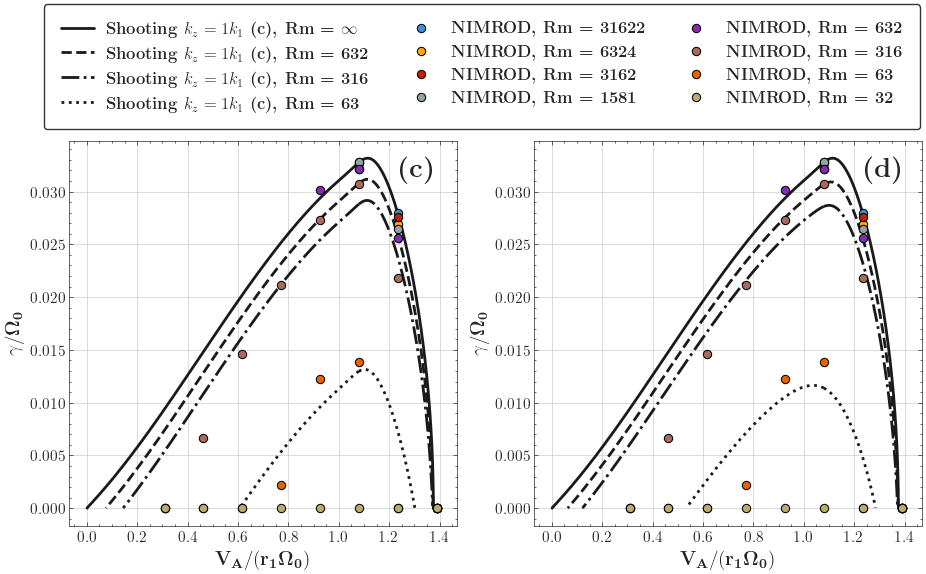

In [44]:
fig, ax = plt.subplots(1,2)
fig.set_figheight(5)
fig.set_figwidth(11)


########################################### PLotting 0
ii = np.where(np.array(gr_1k1_MCI_l_Az_ETA5_divr_q2magpisq) > 0)
VA_l_MCI1_Az_ETA5_divr_q2magpisq_c = np.array(VA_l_MCI1_Az_ETA5_divr_q2magpisq)[ii[:]]
gr_1k1_MCI_l_Az_ETA5_divr_q2magpisq_c = np.array(gr_1k1_MCI_l_Az_ETA5_divr_q2magpisq)[ii[:]]
ii = np.where(np.array(gr_1k1_MCI_h_Az_ETA5_divr_q2magpisq) > 0)
VA_h_MCI1_Az_ETA5_divr_q2magpisq_c = np.array(VA_h_MCI1_Az_ETA5_divr_q2magpisq)[ii[:]]
gr_1k1_MCI_h_Az_ETA5_divr_q2magpisq_c = np.array(gr_1k1_MCI_h_Az_ETA5_divr_q2magpisq)[ii[:]]

ii = np.where(np.array(gr_1k1_MCI_l_Az_ETA10_divr_q2magpisq) > 0)
VA_l_MCI1_Az_ETA10_divr_q2magpisq_c = np.array(VA_l_MCI1_Az_ETA10_divr_q2magpisq)[ii[:]]
gr_1k1_MCI_l_Az_ETA10_divr_q2magpisq_c = np.array(gr_1k1_MCI_l_Az_ETA10_divr_q2magpisq)[ii[:]]
ii = np.where(np.array(gr_1k1_MCI_h_Az_ETA10_divr_q2magpisq) > 0)
VA_h_MCI1_Az_ETA10_divr_q2magpisq_c = np.array(VA_h_MCI1_Az_ETA10_divr_q2magpisq)[ii[:]]
gr_1k1_MCI_h_Az_ETA10_divr_q2magpisq_c = np.array(gr_1k1_MCI_h_Az_ETA10_divr_q2magpisq)[ii[:]]

ii = np.where(np.array(gr_1k1_MCI_l_Az_ETA50_divr_q2magpisq) > 0)
VA_l_MCI1_Az_ETA50_divr_q2magpisq_c = np.array(VA_l_MCI1_Az_ETA50_divr_q2magpisq)[ii[:]]
gr_1k1_MCI_l_Az_ETA50_divr_q2magpisq_c = np.array(gr_1k1_MCI_l_Az_ETA50_divr_q2magpisq)[ii[:]]
ii = np.where(np.array(gr_1k1_MCI_h_Az_ETA50_divr_q2magpisq) > 0)
VA_h_MCI1_Az_ETA50_divr_q2magpisq_c = np.array(VA_h_MCI1_Az_ETA50_divr_q2magpisq)[ii[:]]
gr_1k1_MCI_h_Az_ETA50_divr_q2magpisq_c = np.array(gr_1k1_MCI_h_Az_ETA50_divr_q2magpisq)[ii[:]]

### MCI 
ax[1].plot(VA_h_MCI1,gr_1k1_MCI_l, color = 'k', label=r'\textbf{Shooting $k_z = 1k_1$ (c), Rm = }$\mathbf{\infty}$', linewidth=2) 
ax[1].plot(VA_l_MCI1,gr_1k1_MCI_h, color = 'k', linewidth=2) 
ax[1].plot(VA_l_MCI1_Az_ETA5_divr_q2magpisq_c,gr_1k1_MCI_l_Az_ETA5_divr_q2magpisq_c, 'k', linestyle = '--', label =r'\textbf{Shooting $k_z = 1k_1$ (c), Rm = 632}', linewidth=2)
ax[1].plot(VA_h_MCI1_Az_ETA5_divr_q2magpisq_c,gr_1k1_MCI_h_Az_ETA5_divr_q2magpisq_c, 'k', linestyle = '--', linewidth=2)    
ax[1].plot(VA_l_MCI1_Az_ETA10_divr_q2magpisq_c,gr_1k1_MCI_l_Az_ETA10_divr_q2magpisq_c, 'k', linestyle = '-.', label =r'\textbf{Shooting $k_z = 1k_1$ (c), Rm = 316}', linewidth=2)
ax[1].plot(VA_h_MCI1_Az_ETA10_divr_q2magpisq_c,gr_1k1_MCI_h_Az_ETA10_divr_q2magpisq_c, 'k', linestyle = '-.', linewidth=2)    
ax[1].plot(VA_l_MCI1_Az_ETA50_divr_q2magpisq_c,gr_1k1_MCI_l_Az_ETA50_divr_q2magpisq_c, 'k', linestyle = ':', label =r'\textbf{Shooting $k_z = 1k_1$ (c), Rm = 63}', linewidth=2)
ax[1].plot(VA_h_MCI1_Az_ETA50_divr_q2magpisq_c,gr_1k1_MCI_h_Az_ETA50_divr_q2magpisq_c, 'k', linestyle = ':', linewidth=2)    

i = 0
ax[1].plot(vA[6:len(vA)]/(r1_AR1*Omega0), etaplot_AR1[i][6:len(vA)]/(Omega0), 'o', label=r'\textbf{NIMROD, Rm = 31622}', color = color_arr[i], markeredgecolor='black', markeredgewidth = 0.75)  
i = 1
ax[1].plot(vA[6:len(vA)]/(r1_AR1*Omega0), etaplot_AR1[i][6:len(vA)]/(Omega0), 'o', label=r'\textbf{NIMROD, Rm = 6324}', color = color_arr[i], markeredgecolor='black', markeredgewidth = 0.75)  
i = 2
ax[1].plot(vA[6:len(vA)]/(r1_AR1*Omega0), etaplot_AR1[i][6:len(vA)]/(Omega0), 'o', label=r'\textbf{NIMROD, Rm = 3162}', color = color_arr[i], markeredgecolor='black', markeredgewidth = 0.75)  
i = 3
ax[1].plot(vA[6:len(vA)]/(r1_AR1*Omega0), etaplot_AR1[i][6:len(vA)]/(Omega0), 'o', label=r'\textbf{NIMROD, Rm = 1581}', color = color_arr[i], markeredgecolor='black', markeredgewidth = 0.75)  
i = 4
ax[1].plot(vA[5:len(vA)]/(r1_AR1*Omega0), etaplot_AR1[i][5:len(vA)]/(Omega0), 'o', label=r'\textbf{NIMROD, Rm = 632}', color = color_arr[i], markeredgecolor='black', markeredgewidth = 0.75)  
i = 5
ax[1].plot(vA[1:len(vA)]/(r1_AR1*Omega0), etaplot_AR1[i][1:len(vA)]/(Omega0), 'o', label=r'\textbf{NIMROD, Rm = 316}', color = color_arr[i], markeredgecolor='black', markeredgewidth = 0.75)  
i = 6
ax[1].plot(vA[1:len(vA)]/(r1_AR1*Omega0), etaplot_AR1[i][1:len(vA)]/(Omega0), 'o', label=r'\textbf{NIMROD, Rm = 63}', color = color_arr[i], markeredgecolor='black', markeredgewidth = 0.75)  
i = 7
ax[1].plot(vA[1:len(vA)]/(r1_AR1*Omega0), etaplot_AR1[i][1:len(vA)]/(Omega0), 'o', label=r'\textbf{NIMROD, Rm = 32}', color = color_arr[i], markeredgecolor='black', markeredgewidth = 0.75)  

########################################### PLotting 1
ii = np.where(np.array(gr_1k1_MCI_l_Az_ETA5_divr_WKB_div4) > 0)
VA_l_MCI1_Az_ETA5_divr_WKB_div4_c = np.array(VA_l_MCI1_Az_ETA5_divr_WKB_div4)[ii[:]]
gr_1k1_MCI_l_Az_ETA5_divr_WKB_div4_c = np.array(gr_1k1_MCI_l_Az_ETA5_divr_WKB_div4)[ii[:]]
ii = np.where(np.array(gr_1k1_MCI_h_Az_ETA5_divr_WKB_div4) > 0)
VA_h_MCI1_Az_ETA5_divr_WKB_div4_c = np.array(VA_h_MCI1_Az_ETA5_divr_WKB_div4)[ii[:]]
gr_1k1_MCI_h_Az_ETA5_divr_WKB_div4_c = np.array(gr_1k1_MCI_h_Az_ETA5_divr_WKB_div4)[ii[:]]

ii = np.where(np.array(gr_1k1_MCI_l_Az_ETA10_divr_WKB_div4) > 0)
VA_l_MCI1_Az_ETA10_divr_WKB_div4_c = np.array(VA_l_MCI1_Az_ETA10_divr_WKB_div4)[ii[:]]
gr_1k1_MCI_l_Az_ETA10_divr_WKB_div4_c = np.array(gr_1k1_MCI_l_Az_ETA10_divr_WKB_div4)[ii[:]]
ii = np.where(np.array(gr_1k1_MCI_h_Az_ETA10_divr_WKB_div4) > 0)
VA_h_MCI1_Az_ETA10_divr_WKB_div4_c = np.array(VA_h_MCI1_Az_ETA10_divr_WKB_div4)[ii[:]]
gr_1k1_MCI_h_Az_ETA10_divr_WKB_div4_c = np.array(gr_1k1_MCI_h_Az_ETA10_divr_WKB_div4)[ii[:]]

ii = np.where(np.array(gr_1k1_MCI_l_Az_ETA50_divr_WKB_div4) > 0)
VA_l_MCI1_Az_ETA50_divr_WKB_div4_c = np.array(VA_l_MCI1_Az_ETA50_divr_WKB_div4)[ii[:]]
gr_1k1_MCI_l_Az_ETA50_divr_WKB_div4_c = np.array(gr_1k1_MCI_l_Az_ETA50_divr_WKB_div4)[ii[:]]
ii = np.where(np.array(gr_1k1_MCI_h_Az_ETA50_divr_WKB_div4) > 0)
VA_h_MCI1_Az_ETA50_divr_WKB_div4_c = np.array(VA_h_MCI1_Az_ETA50_divr_WKB_div4)[ii[:]]
gr_1k1_MCI_h_Az_ETA50_divr_WKB_div4_c = np.array(gr_1k1_MCI_h_Az_ETA50_divr_WKB_div4)[ii[:]]

### MCI 
ax[0].plot(VA_h_MCI1,gr_1k1_MCI_l, color = 'k', linewidth=2) 
ax[0].plot(VA_l_MCI1,gr_1k1_MCI_h, color = 'k', linewidth=2) 
### WKB
ax[0].plot(VA_l_MCI1_Az_ETA5_divr_WKB_div4_c,gr_1k1_MCI_l_Az_ETA5_divr_WKB_div4_c, 'k', linestyle = '--', linewidth=2)
ax[0].plot(VA_h_MCI1_Az_ETA5_divr_WKB_div4_c,gr_1k1_MCI_h_Az_ETA5_divr_WKB_div4_c, 'k', linestyle = '--', linewidth=2)    
ax[0].plot(VA_l_MCI1_Az_ETA10_divr_WKB_div4_c,gr_1k1_MCI_l_Az_ETA10_divr_WKB_div4_c, 'k', linestyle = '-.', linewidth=2)
ax[0].plot(VA_h_MCI1_Az_ETA10_divr_WKB_div4_c,gr_1k1_MCI_h_Az_ETA10_divr_WKB_div4_c, 'k', linestyle = '-.', linewidth=2)    
ax[0].plot(VA_l_MCI1_Az_ETA50_divr_WKB_div4_c,gr_1k1_MCI_l_Az_ETA50_divr_WKB_div4_c, 'k', linestyle = ':', linewidth=2)
ax[0].plot(VA_h_MCI1_Az_ETA50_divr_WKB_div4_c,gr_1k1_MCI_h_Az_ETA50_divr_WKB_div4_c, 'k', linestyle = ':', linewidth=2)    

i = 0
ax[0].plot(vA[6:len(vA)]/(r1_AR1*Omega0), etaplot_AR1[i][6:len(vA)]/(Omega0), 'o', color = color_arr[i], markeredgecolor='black', markeredgewidth = 0.75)  
i = 1
ax[0].plot(vA[6:len(vA)]/(r1_AR1*Omega0), etaplot_AR1[i][6:len(vA)]/(Omega0), 'o', color = color_arr[i], markeredgecolor='black', markeredgewidth = 0.75)  
i = 2
ax[0].plot(vA[6:len(vA)]/(r1_AR1*Omega0), etaplot_AR1[i][6:len(vA)]/(Omega0), 'o', color = color_arr[i], markeredgecolor='black', markeredgewidth = 0.75)  
i = 3
ax[0].plot(vA[6:len(vA)]/(r1_AR1*Omega0), etaplot_AR1[i][6:len(vA)]/(Omega0), 'o', color = color_arr[i], markeredgecolor='black', markeredgewidth = 0.75)  
i = 4
ax[0].plot(vA[5:len(vA)]/(r1_AR1*Omega0), etaplot_AR1[i][5:len(vA)]/(Omega0), 'o', color = color_arr[i], markeredgecolor='black', markeredgewidth = 0.75)  
i = 5
ax[0].plot(vA[1:len(vA)]/(r1_AR1*Omega0), etaplot_AR1[i][1:len(vA)]/(Omega0), 'o', color = color_arr[i], markeredgecolor='black', markeredgewidth = 0.75)  
i = 6
ax[0].plot(vA[1:len(vA)]/(r1_AR1*Omega0), etaplot_AR1[i][1:len(vA)]/(Omega0), 'o', color = color_arr[i], markeredgecolor='black', markeredgewidth = 0.75)  
i = 7
ax[0].plot(vA[1:len(vA)]/(r1_AR1*Omega0), etaplot_AR1[i][1:len(vA)]/(Omega0), 'o', color = color_arr[i], markeredgecolor='black', markeredgewidth = 0.75)  

#######################################################################################
lines_labels = [ax2.get_legend_handles_labels() for ax2 in fig.axes]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]

# fig.legend(lines, labels, loc='lower center', ncol=3, 
#            bbox_to_anchor=(0.5, -.25),  # Position the legend below the plot
#            frameon=True,  # Turn on the frame (border)
#            edgecolor='black',  # Set the border color
#            facecolor='white',  # Set the background color of the legend box
#            borderpad=1,  # Padding between the legend text and the border
#            borderaxespad=1, fontsize = 12)

fig.legend(lines, labels, loc='lower center', ncol=3, 
           bbox_to_anchor=(0.5, .87),  # Position the legend below the plot
           frameon=True,  # Turn on the frame (border)
           edgecolor='black',  # Set the border color
           facecolor='white',  # Set the background color of the legend box
           borderpad=1,  # Padding between the legend text and the border
           borderaxespad=1, fontsize = 12)


# ax[0].set_title(r'\textbf{HWKB}', fontsize = 14)
# ax[1].set_title(r'\textbf{MWKB}', fontsize = 14)
ax[0].set_xlabel(r'$\mathbf{V_A/(r_1 \Omega_0)}$',fontsize=14)
ax[0].set_ylabel(r'$\mathbf{\gamma/\Omega_0}$',fontsize=14)
ax[1].set_xlabel(r'$\mathbf{V_A/(r_1 \Omega_0)}$',fontsize=14)
ax[1].set_ylabel(r'$\mathbf{\gamma/\Omega_0}$',fontsize=14)

ax[0].text(0.85, 0.96, r'\textbf{(c)}', transform=ax[0].transAxes, fontsize=20, verticalalignment='top', horizontalalignment='left')
ax[1].text(0.85, 0.96, r'\textbf{(d)}', transform=ax[1].transAxes, fontsize=20, verticalalignment='top', horizontalalignment='left')

plt.savefig('Shooting-NIMROD-comp/GRvsAlfvenSpeed-NIMROD-Az-comb.pdf', bbox_inches='tight')
plt.show()


# Plot WKB MRI Modes

[array([44016.9 , 75370.2 , 85609.5 , 77029.5 , 50007.  , 28348.8 ,
       10148.7 ,  8849.72,     0.  ]), array([28334.8 , 57125.3 , 67360.8 , 61718.3 , 42576.1 , 25225.8 ,
       10339.7 ,  8520.59,     0.  ]), array([19181.1 , 46733.3 , 57130.9 , 53070.  , 37846.  , 23233.5 ,
       10378.7 ,  8737.85,     0.  ]), array([ 8262.29, 34777.3 , 45215.5 , 43300.4 , 32054.6 , 20705.8 ,
       10362.  ,  8353.78,     0.  ]), array([    0.  , 16046.7 , 26877.8 , 28089.2 , 22632.4 ,  9544.  ,
       10150.5 ,  8098.38,     0.  ]), array([   0.  ,    0.  , 2088.13, 4607.29, 6674.49, 8632.65, 9701.79,
       6897.13,    0.  ]), array([   0.   ,    0.   ,    0.   ,    0.   ,  695.382, 3878.04 ,
       4383.83 ,    0.   ,    0.   ]), array([0., 0., 0., 0., 0., 0., 0., 0., 0.])]


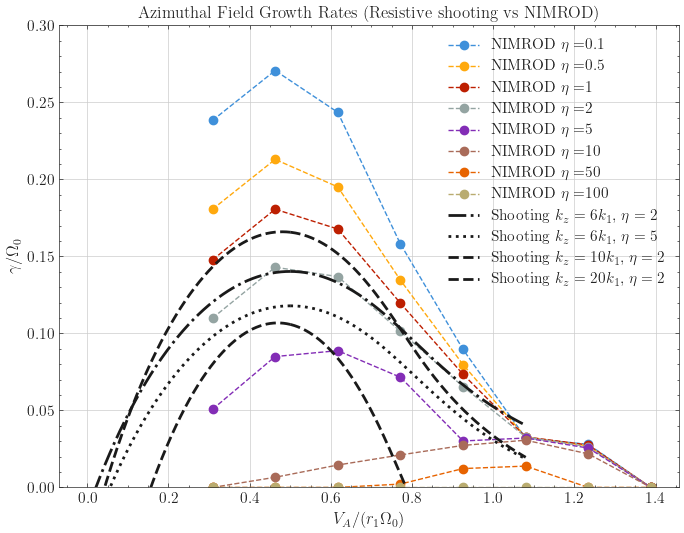

In [88]:
# %%
smrm = 1/2.0510130839719898e-07/10000/25298.2
# smrm=1
W0 = 252982
# Bs = np.asarray([   0 ,    5 ,   10 ,   15 ,   20 ,   25 ,   30 ,   35 ,   40 ,   45 ,   50 ,   55 ,   60 ,   65 ,   70 ,   75 ,   80 ])*smrm
Bs = np.asarray([   0 ,    5 ,   10 ,   15 ,   20 ,   25 ,   30 ,   35 ,   40 ,   45 ,   50 ,   55 ,   60 ,   65 ,   70 ,   75 ,   80 ])/(r1*Omega0*np.sqrt(rho*mu_0)*10000)

gs = [   0 ,    0 ,1.02e4,2.24e4,2.99e4,3.32e4,3.28e4,2.93e4,2.40e4,1.85e4,0.76e4,0.82e4,0.80e4,0.61e4,0.25e4,    0 ,    0 ]

### IMPORT MY DATA
r1_AR1 = 0.1
r2_AR1 = 0.5

## Get Alfven via input data
magB = [10, 20, 30, 40, 50, 60, 70, 80, 90]
vA = magB/np.sqrt(rho*mu_0)/10000

## AR1 Data
eta = ['0.1', '0.5', '1', '2', '5']
eta = ['0.1', '0.5', '1', '2', '5', '10', '50', '100']

### REVISION 3 WITH DTMS DATA
gr_10g = [44016.9, 28334.8, 19181.1,8262.29, 0, 0, 0, 0] ## WAITING ON 10 ETA 5
gr_20g = [75370.2, 57125.3, 46733.3,34777.3, 16046.7, 0, 0,0 ]
gr_30g = [85609.5, 67360.8, 57130.9,45215.5, 26877.8, 2088.13, 0,0]
gr_40g = [77029.5, 61718.3, 53070,43300.4, 28089.2, 4607.29, 0,0]
gr_50g = [50007, 42576.1, 37846,32054.6, 22632.4, 6674.49, 695.382, 0]
gr_60g = [28348.8, 25225.8, 23233.5,20705.8, 9544, 8632.65, 3878.04, 0]
gr_70g = [10148.7, 10339.7, 10378.7,10362, 10150.5, 9701.79, 4383.83, 0] ### OTHER ETA0.1 is 18002.2
gr_80g = [8849.72, 8520.59, 8737.85,8353.78, 8098.38, 6897.13, 0, 0]
# gr_90g = [10127.7, 9613.43, 9315.53,8896.36, 9541.62, 0, 0, 0]
gr_90g = [0, 0,0,0, 0, 0, 0, 0]

magB = [10, 20, 30, 40, 50, 60, 70, 80,90]
vA = magB/np.sqrt(rho*mu_0)/10000

gr_tot = [gr_10g, gr_20g, gr_30g, gr_40g, gr_50g, gr_60g, gr_70g, gr_80g,gr_90g]

etaplot_AR1 = []
for i in range(0, len(eta)):
    etai = np.zeros(len(gr_tot))
    for j in range(0, len(gr_tot)):
        etai[j] = gr_tot[j][i]
    etaplot_AR1.append(etai)

# fig = plt.figure()
fig = plt.figure(figsize = (8,6))
color_arr = ['#3F90DA', '#FFA90E', '#BD1F01', '#94A4A2', '#832DB6', '#A96B59', '#E76300', '#B9AC70', '#92DADD']

for i in range(0, len(etaplot_AR1)):
    ## Note 8/10 because of scaling w/ bb of other sims
    plt.plot(vA[1:len(vA)]/(r1_AR1*Omega0), etaplot_AR1[i][1:len(vA)]/(Omega0), 'o', linestyle = '--', label=r'NIMROD $\eta =$' + str(eta[i]), color = color_arr[i])
## PLOT SHOOTING DATA

print(etaplot_AR1)
# color_arr = ['dodgerblue', 'mediumorchid', 'midnightblue', 'springgreen', 'tomato', 'k']

### MCI 
# plt.plot(VA_h_MCI1,gr_1k1_MCI_l, color = 'k', label=r'Shooting $k_z = 1k_1$ (c)', linewidth=2) 
# plt.plot(VA_l_MCI1,gr_1k1_MCI_h, color = 'k', linewidth=2) 

# plt.plot(VA_l_MCI1_Az_ETA1_divr_q2mag9,gr_1k1_MCI_l_Az_ETA1_divr_q2mag9, 'k', label =f'Shooting $k_z = 1k_1$ (c), $\eta = 1$', linewidth=2, linestyle = '--') 
# plt.plot(VA_h_MCI1_Az_ETA1_divr_q2mag9,gr_1k1_MCI_h_Az_ETA1_divr_q2mag9, 'k', linewidth=2, linestyle = '--')    

# plt.plot(VA_l_MCI1_Az_ETA5_divr_q2mag9,gr_1k1_MCI_l_Az_ETA5_divr_q2mag9, 'k', linestyle = '--', label =f'Shooting $k_z = 1k_1$ (c), $\eta = 5, q^2 \sim 9$', linewidth=2)
# plt.plot(VA_h_MCI1_Az_ETA5_divr_q2mag9,gr_1k1_MCI_h_Az_ETA5_divr_q2mag9, 'k', linestyle = '--', linewidth=2)    

# plt.plot(VA_l_MCI1_Az_ETA10_divr_q2mag9,gr_1k1_MCI_l_Az_ETA10_divr_q2mag9, 'k', linestyle = '-.', label =f'Shooting $k_z = 1k_1$ (c), $\eta = 10$', linewidth=2)
# plt.plot(VA_h_MCI1_Az_ETA10_divr_q2mag9,gr_1k1_MCI_h_Az_ETA10_divr_q2mag9, 'k', linestyle = '-.', linewidth=2)    

# plt.plot(VA_l_MCI1_Az_ETA50_divr_q2mag9,gr_1k1_MCI_l_Az_ETA50_divr_q2mag9, 'k', linestyle = ':', label =f'Shooting $k_z = 1k_1$ (c), $\eta = 50$', linewidth=2)
# plt.plot(VA_h_MCI1_Az_ETA50_divr_q2mag9,gr_1k1_MCI_h_Az_ETA50_divr_q2mag9, 'k', linestyle = ':', linewidth=2)    

# # qmag 4
# plt.plot(VA_l_MCI1_Az_ETA50_divr_q2mag16,gr_1k1_MCI_l_Az_ETA50_divr_q2mag16, 'k', linestyle = ':', label =f'Shooting $k_z = 1k_1$ (c), $\eta = 50, q^2 \sim 9$', linewidth=2)
# plt.plot(VA_h_MCI1_Az_ETA50_divr_q2mag16,gr_1k1_MCI_h_Az_ETA50_divr_q2mag16, 'k', linestyle = ':', linewidth=2)    

### WKB
# plt.plot(VA_l_MRI6_Az_ETA1_divr_WKB_div4,gr_6k1_MRI_l_Az_ETA5_divr_WKB_div4, 'k', linestyle = '--', label =f'Shooting $k_z = 6k_1$, $\eta = 1$', linewidth=2)
# plt.plot(VA_h_MRI6_Az_ETA1_divr_WKB_div4,gr_6k1_MRI_h_Az_ETA5_divr_WKB_div4, 'k', linestyle = '--', linewidth=2)    

plt.plot(VA_l_MRI6_Az_ETA2_divr_WKB_div4,gr_6k1_MRI_l_Az_ETA2_divr_WKB_div4, 'k', linestyle = '-.', label =f'Shooting $k_z = 6k_1$, $\eta = 2$', linewidth=2)
plt.plot(VA_h_MRI6_Az_ETA2_divr_WKB_div4,gr_6k1_MRI_h_Az_ETA2_divr_WKB_div4, 'k', linestyle = '-.', linewidth=2)    

plt.plot(VA_l_MRI6_Az_ETA5_divr_WKB_div4,gr_6k1_MRI_l_Az_ETA5_divr_WKB_div4, 'k', linestyle = ':', label =f'Shooting $k_z = 6k_1$, $\eta = 5$', linewidth=2)
plt.plot(VA_h_MRI6_Az_ETA5_divr_WKB_div4,gr_6k1_MRI_h_Az_ETA5_divr_WKB_div4, 'k', linestyle = ':', linewidth=2)    

plt.plot(VA_l_MRI10_Az_ETA2_divr_WKB_div4,gr_10k1_MRI_l_Az_ETA2_divr_WKB_div4, 'k', linestyle = '--', label =f'Shooting $k_z = 10k_1$, $\eta = 2$', linewidth=2)
plt.plot(VA_h_MRI10_Az_ETA2_divr_WKB_div4,gr_10k1_MRI_h_Az_ETA2_divr_WKB_div4, 'k', linestyle = '--', linewidth=2)    

plt.plot(VA_l_MRI20_Az_ETA2_divr_WKB_div4,gr_20k1_MRI_l_Az_ETA2_divr_WKB_div4, 'k', linestyle = '--', label =f'Shooting $k_z = 20k_1$, $\eta = 2$', linewidth=2)
plt.plot(VA_h_MRI20_Az_ETA2_divr_WKB_div4,gr_20k1_MRI_h_Az_ETA2_divr_WKB_div4, 'k', linestyle = '--', linewidth=2)    


###### MRI

VA_shoot = [1.157*8/10] ## ETA0.1
ETAp1 = [0.02283895391150039]
ETAp5 = [0.01718854743963384]
ETA1 = [0.01717910905775954]
ETA2 = [0.018524447015573035]
ETA5 = [0.020554535400139143]

plt.plot()
plt.xlabel(r'${V_A}/(r_1\Omega_0)$')
plt.ylabel(r'$\gamma/\Omega_0$')
plt.title('Azimuthal Field Growth Rates (Resistive shooting vs NIMROD)')
plt.legend()
# ax.legend()
# plt.savefig('GRvsAlfvenSpeed-NIMROD-q2mag9-1divr.png', bbox_inches='tight')
# plt.ylim(0,0.05)
# plt.xlim(.2,1.1)
plt.ylim(0,0.3)
plt.show()
plt.close()

In [89]:
print(gr_1k1_MCI_h_Az_ETA50_divr_WKB_div4[0])

0.012970256124813027


# Frequency

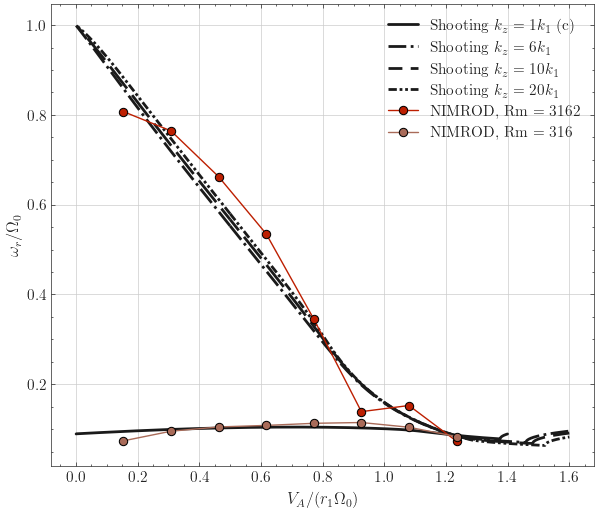

In [49]:

# fig = plt.figure()
fig = plt.figure(figsize=(7,6))



### SHOOTING

### MCI 
plt.plot(VA_h_MCI1,freq_1k1_MCI_l, color = 'k', label=r'Shooting $k_z = 1k_1$ (c)', linewidth=2)
plt.plot(VA_l_MCI1,freq_1k1_MCI_h, color = 'k', linewidth=2)

###### MRI

plt.plot(VA_l_MRI6,freq_6k1_MRI_l, label=r'Shooting $k_z = 6k_1$', color = 'k', linestyle = '-.', linewidth=2)
plt.plot(VA_h_MRI6,freq_6k1_MRI_h, color = 'k', linestyle = '-.', linewidth=2)

plt.plot(VA_l_MRI10,freq_10k1_MRI_l, label=r'Shooting $k_z = 10k_1$', color = 'k', linestyle = (5, (10, 3)), linewidth=2)
plt.plot(VA_h_MRI10,freq_10k1_MRI_h, color = 'k', linestyle = (5, (10, 3)), linewidth=2)

plt.plot(VA_l_MRI20,freq_20k1_MRI_l, label=r'Shooting $k_z = 20k_1$', color = 'k',linestyle = (0, (3, 1, 1, 1, 1, 1)), linewidth=2)
plt.plot(VA_h_MRI20,freq_20k1_MRI_h, color = 'k', linestyle = (0, (3, 1, 1, 1, 1, 1)), linewidth=2)

ETA1_freq = [0.7947670612636882, 0.6479079303780066,0.6891891490662979,0.5519215703220056, 0.3010481292665485, 0.2536490621054323,0.09645231326015632,0.10277160274961485 ]
ETA1_freq = [0.8221728219969188, 0.7012650540561954, 0.6623058843864067, 0.5259487905421465, 0.29803764797388305, 0.27094331633989366,0.10277160274961485 ,0.10277160274961485]
ETA1_freq = [0.8071852965959332, 0.7641990973689308, 0.6623058843864067, 0.5349393681582516, 0.34524455675461635, 0.13887058866166593,0.15255007574018656 ,0.07306577372234381]
ETA10_freq = [	0.07386310978287064, 0.0952958107030801, 0.10479523487126687, .10821991574941284, 0.11289304847495568, 0.11468500162535179, 0.10413614534377463, 0.08339633381570703] 
VA1 = np.array([10, 20, 30, 40, 50, 60, 70,80])/10000/ np.sqrt(rho*mu_0)/(r1*Omega0)

VA5 = np.array([20, 30, 40, 50, 60, 70,80])/10000/ np.sqrt(rho*mu_0)/(r1*Omega0)
ETA5_freq = [0.607429111108676, 0.5916923893599149, 0.32962689176834986, 0.2189664352461181, 0.09461512634091525, 0.08545882379179442, 0.0917038916842717]
plt.plot(VA1, ETA1_freq, marker = 'o', label = 'NIMROD, Rm $= 3162$', color = color_arr[2], markeredgecolor='black', markeredgewidth = 0.75)  
plt.plot(VA1, ETA10_freq, marker = 'o', label = 'NIMROD, Rm $= 316$', color = color_arr[5], markeredgecolor='black', markeredgewidth = 0.75)  
# plt.plot(VA5, ETA5_freq, marker = 'o', label = '$\eta = 10$')
plt.xlabel('$V_A/(r_1 \Omega_0)$',fontsize=12)
plt.ylabel(r'$\omega_r/\Omega_0$',fontsize=12)
plt.legend()
# plt.title('Azimuthal field frequencies \n (Shooting vs NIMROD)',fontsize=15)

plt.savefig('Shooting-NIMROD-comp/FreqvsAlfvenSpeed-NIMROD-Az-v2.png', bbox_inches='tight', dpi = 400)
plt.savefig('Shooting-NIMROD-comp/FreqvsAlfvenSpeed-NIMROD-Az-v2.svg', bbox_inches='tight', format = 'svg')

plt.show()

# Error

0
1.0796958976918347
1.0796958976918347
318
1.2339381687906683
1.2329741545963007
index = 
0
1.0796958976918347
1.0796958976918347
index = 
318
1.2339381687906683
1.2329741545963007


C:\Users\Alex\AppData\Local\Temp\ipykernel_58336\2850082065.py:29: RuntimeWarning: divide by zero encountered in divide
  error_bz80 = np.abs((GRS_bz80/Omega0-gr_temp)/(GRS_bz80/Omega0))
C:\Users\Alex\AppData\Local\Temp\ipykernel_58336\2850082065.py:58: RuntimeWarning: divide by zero encountered in divide
  error_bz80_WKB = np.abs((GRS_bz80/Omega0-gr_temp)/(GRS_bz80/Omega0))
C:\Users\Alex\AppData\Local\Temp\ipykernel_58336\2850082065.py:65: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


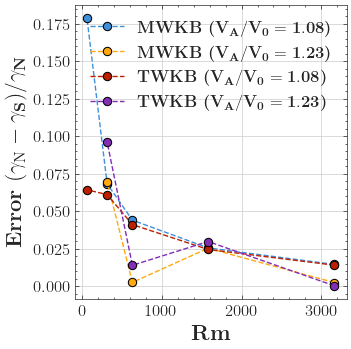

In [42]:
fig = plt.figure(figsize=(3.5,3.5))
ax = plt.subplot(111)
color_arr = ['#3F90DA', '#FFA90E', '#BD1F01', '#94A4A2', '#832DB6', '#A96B59', '#E76300', '#B9AC70', '#92DADD']
####################################### qmagpi
ETA_ARR = [1,2,5,10,50]
# First VA_N_Arr[8]
tol = 1E-3
i2 = 6
ii = np.where(np.abs(VA_h_MCI1_Az_ETA1_divr_q2magpisq-(vA/(r1*Omega0))[6]) < tol)[0][0]

print(ii)
print(vA[i2]/(r1*Omega0))
print(VA_h_MCI1_Az_ETA5_divr_q2magpisq[ii])
di = 0
gr_temp = np.array([gr_1k1_MCI_h_Az_ETA1_divr_q2magpisq[ii], gr_1k1_MCI_h_Az_ETA2_divr_q2magpisq[ii], gr_1k1_MCI_h_Az_ETA5_divr_q2magpisq[ii], gr_1k1_MCI_h_Az_ETA10_divr_q2magpisq[ii], gr_1k1_MCI_h_Az_ETA50_divr_q2magpisq[ii]])
GRS_bz70 = np.array(gr_70g[2:len(gr_70g)-1])
error_bz70 = np.abs((GRS_bz70/Omega0-gr_temp)/(GRS_bz70/Omega0))

# First VA_N_Arr[9]
tol = 1E-3
i2 = 7
di = 0
ii = np.where(np.abs(VA_h_MCI1_Az_ETA1_divr_q2magpisq-(vA/(r1*Omega0))[i2]) < tol)[0][0]
print(ii)
print(vA[i2]/(r1*Omega0))
print(VA_h_MCI1_Az_ETA5_divr_q2magpisq[ii])
gr_temp = np.array([gr_1k1_MCI_h_Az_ETA1_divr_q2magpisq[ii], gr_1k1_MCI_h_Az_ETA2_divr_q2magpisq[ii], gr_1k1_MCI_h_Az_ETA5_divr_q2magpisq[ii], gr_1k1_MCI_h_Az_ETA10_divr_q2magpisq[ii], gr_1k1_MCI_h_Az_ETA50_divr_q2magpisq[ii]])
GRS_bz80 = np.array(gr_80g[2:len(gr_80g)-1])
error_bz80 = np.abs((GRS_bz80/Omega0-gr_temp)/(GRS_bz80/Omega0))

####################################### WKB
ETA_ARR = [1,2,5,10,50]
# First VA_N_Arr[8]
tol = 1E-3
i2 = 6
ii = np.where(np.abs(VA_h_MCI1_Az_ETA1_divr_q2magpisq-(vA/(r1*Omega0))[6]) < tol)[0][0]

print('index = ')
print(ii)
print(vA[i2]/(r1*Omega0))
print(VA_h_MCI1_Az_ETA5_divr_q2magpisq[ii])
di = 0
gr_temp = np.array([gr_1k1_MCI_h_Az_ETA1_divr_WKB_div4[ii], gr_1k1_MCI_h_Az_ETA2_divr_WKB_div4[ii], gr_1k1_MCI_h_Az_ETA5_divr_WKB_div4[ii], gr_1k1_MCI_h_Az_ETA10_divr_WKB_div4[ii], gr_1k1_MCI_h_Az_ETA50_divr_WKB_div4[ii]])
GRS_bz70 = np.array(gr_70g[2:len(gr_70g)-1])
error_bz70_WKB = np.abs((GRS_bz70/Omega0-gr_temp)/(GRS_bz70/Omega0))

# First VA_N_Arr[9]
tol = 1E-3
i2 = 7
di = 0
ii = np.where(np.abs(VA_h_MCI1_Az_ETA1_divr_q2magpisq-(vA/(r1*Omega0))[i2]) < tol)[0][0]
print('index = ')
print(ii)
print(vA[i2]/(r1*Omega0))
print(VA_h_MCI1_Az_ETA5_divr_q2magpisq[ii])
gr_temp = np.array([gr_1k1_MCI_h_Az_ETA1_divr_WKB_div4[ii], gr_1k1_MCI_h_Az_ETA2_divr_WKB_div4[ii], gr_1k1_MCI_h_Az_ETA5_divr_WKB_div4[ii], gr_1k1_MCI_h_Az_ETA10_divr_WKB_div4[ii], gr_1k1_MCI_h_Az_ETA50_divr_WKB_div4[ii]])
GRS_bz80 = np.array(gr_80g[2:len(gr_80g)-1])
error_bz80_WKB = np.abs((GRS_bz80/Omega0-gr_temp)/(GRS_bz80/Omega0))



box = ax.get_position()
# ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])
# ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax.legend()
Rm = r1**2*Omega0/ETA_ARR


plt.plot(Rm, error_bz70, label = r'\textbf{MWKB ($\mathbf{V_A/V_0 = 1.08}$)}', color = color_arr[0], marker = 'o', linestyle = '--', markeredgecolor='black', markeredgewidth = 0.75)  
plt.plot(Rm, error_bz80, label = r'\textbf{MWKB ($\mathbf{V_A/V_0 = 1.23}$)}', color = color_arr[1], marker = 'o',  linestyle = '--',markeredgecolor='black', markeredgewidth = 0.75)  
plt.plot(Rm, error_bz70_WKB, label = r'\textbf{TWKB ($\mathbf{V_A/V_0 = 1.08}$)}', color = color_arr[2], marker = 'o', linestyle = '--', markeredgecolor='black', markeredgewidth = 0.75)  
plt.plot(Rm, error_bz80_WKB, label = r'\textbf{TWKB ($\mathbf{V_A/V_0 = 1.23}$)}', color = color_arr[4], marker = 'o',  linestyle = '--',markeredgecolor='black', markeredgewidth = 0.75)  
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.legend(fontsize=12)
plt.ylabel(r'\textbf{Error} ($\mathbf{\gamma_{\mathrm{N}}-\gamma_{S})/\gamma_N}$', fontsize = 16)
plt.xlabel(r'\textbf{Rm}', fontsize = 16)
# plt.savefig('Shooting-NIMROD-comp/GRvsAlfvenSpeed-NIMROD-Bz-divrpi.png', bbox_inches='tight')
plt.savefig('Shooting-NIMROD-comp/Shooting_Error_Az.png', bbox_inches='tight', dpi = 500)
plt.savefig('Shooting-NIMROD-comp/Shooting_Error_Az.svg', bbox_inches='tight', format = 'svg')
plt.savefig('Shooting-NIMROD-comp/Shooting_Error_Az.pdf', bbox_inches='tight', dpi = 500)

plt.show()
plt.close()

In [ ]:

plt.plot(Rm, error_bz70, label = r'MWKB (70G)', color = color_arr[0], marker = 'o', linestyle = '--', markeredgecolor='black', markeredgewidth = 0.75)  
plt.plot(Rm, error_bz80, label = r'MWKB (80G)', color = color_arr[1], marker = 'o',  linestyle = '--',markeredgecolor='black', markeredgewidth = 0.75)  
plt.plot(Rm, error_bz70_WKB, label = r'TWKB (70G)', color = color_arr[2], marker = 'o', linestyle = '--', markeredgecolor='black', markeredgewidth = 0.75)  
plt.plot(Rm, error_bz80_WKB, label = r'TWKB (80G)', color = color_arr[4], marker = 'o',  linestyle = '--',markeredgecolor='black', markeredgewidth = 0.75)  

In [ ]:
print(error_bz70)
print(error_bz80)
print(error_bz70_WKB)
print(error_bz80_WKB)

# Error Diff AR

In [44]:
# fig = plt.figure(figsize=(4,4))
# ax = plt.subplot(111)
# color_arr = ['#3F90DA', '#FFA90E', '#BD1F01', '#94A4A2', '#832DB6', '#A96B59', '#E76300', '#B9AC70', '#92DADD']
# ####################################### qmagpi
# # ETA_ARR = [0.1,0.5,1,2,5]
# ETA_ARR = [1,2,5]
# # First VA_N_Arr[8]
# tol = 1E-3
# i2 = 2
# print(vA[i2]/(r1*Omega0*10000))
# print(vA[2]/(r1*Omega0*10000))
# # print(VA_l_MCI1_AR0_ETA1)
# # print(VA_h_MCI1_AR0_ETA1)
# ii = np.where(np.abs(VA_l_MCI1_AR0_ETA1-(vA[i2]/(r1*Omega0*10000))) < tol)[0][0]

# print(ii)
# print(vA[i2]/(r1*Omega0))
# print(VA_l_MCI1_AR0_ETA1[ii])
# di = 0
# gr_temp = np.array([gr_1k1_MCI_l_AR0_ETA1[ii], gr_1k1_MCI_l_AR0_ETA2[ii], gr_1k1_MCI_l_AR0_ETA5[ii]])
# ij = np.where(gr_temp < 0)
# gr_temp[ij[:]] = 0

# GRS_bz70 = np.array([(etaplot_AR0[2]/(Omega0))[i2],(etaplot_AR0[3]/(Omega0))[i2],(etaplot_AR0[4]/(Omega0))[i2]])
# error_bz30_AR0 = np.abs((GRS_bz70-gr_temp)/(GRS_bz70))

# ###########
# tol = 1E-3
# i2 = 1
# print(vA[i2]/(r1*Omega0*10000))
# print(vA[1]/(r1*Omega0*10000))
# # print(VA_l_MCI1_AR0_ETA1)
# # print(VA_h_MCI1_AR0_ETA1)
# ii = np.where(np.abs(VA_l_MCI1_AR0_ETA1-(vA[i2]/(r1*Omega0*10000))) < tol)[0][0]

# print(ii)
# print(vA[i2]/(r1*Omega0))
# print(VA_l_MCI1_AR0_ETA1[ii])
# di = 0
# gr_temp = np.array([gr_1k1_MCI_l_AR0_ETA1[ii], gr_1k1_MCI_l_AR0_ETA2[ii], gr_1k1_MCI_l_AR0_ETA5[ii]])
# ij = np.where(gr_temp < 0)
# gr_temp[ij[:]] = 0

# GRS_bz70 = np.array([(etaplot_AR0[2]/(Omega0))[i2],(etaplot_AR0[3]/(Omega0))[i2],(etaplot_AR0[4]/(Omega0))[i2]])
# error_bz20_AR0 = np.abs((GRS_bz70-gr_temp)/(GRS_bz70))
# #####################
# tol = 1E-3
# i2 = 3
# print(vA[i2]/(r1*Omega0*10000))
# print(vA[3]/(r1*Omega0*10000))
# # print(VA_l_MCI1_AR0_ETA1)
# # print(VA_h_MCI1_AR0_ETA1)
# ii = np.where(np.abs(VA_l_MCI1_AR0_ETA1-(vA[i2]/(r1*Omega0*10000))) < tol)[0][0]

# print(ii)
# print(vA[i2]/(r1*Omega0))
# print(VA_l_MCI1_AR0_ETA1[ii])
# di = 0
# gr_temp = np.array([gr_1k1_MCI_l_AR0_ETA1[ii], gr_1k1_MCI_l_AR0_ETA2[ii], gr_1k1_MCI_l_AR0_ETA5[ii]])
# ij = np.where(gr_temp < 0)
# gr_temp[ij[:]] = 0

# GRS_bz70 = np.array([(etaplot_AR0[2]/(Omega0))[i2],(etaplot_AR0[3]/(Omega0))[i2],(etaplot_AR0[4]/(Omega0))[i2]])
# error_bz40_AR0 = np.abs((GRS_bz70-gr_temp)/(GRS_bz70))



# ######################### WKB gr_1k1_MCI_l_AR0_ETA1_WKB
# # First VA_N_Arr[8]
# tol = 1E-3
# i2 = 2
# print(vA[i2]/(r1*Omega0*10000))
# print(vA[2]/(r1*Omega0*10000))
# # print(VA_l_MCI1_AR0_ETA1)
# # print(VA_h_MCI1_AR0_ETA1)
# ii = np.where(np.abs(VA_l_MCI1_AR0_ETA1-(vA[i2]/(r1*Omega0*10000))) < tol)[0][0]

# print(ii)
# print(vA[i2]/(r1*Omega0))
# print(VA_l_MCI1_AR0_ETA1[ii])
# di = 0
# gr_temp = np.array([gr_1k1_MCI_l_AR0_ETA1_WKB[ii], gr_1k1_MCI_l_AR0_ETA2_WKB[ii], gr_1k1_MCI_l_AR0_ETA5_WKB[ii]])
# ij = np.where(gr_temp < 0)
# gr_temp[ij[:]] = 0

# GRS_bz70 = np.array([(etaplot_AR0[2]/(Omega0))[i2],(etaplot_AR0[3]/(Omega0))[i2],(etaplot_AR0[4]/(Omega0))[i2]])
# error_bz30_WKB_AR0 = np.abs((GRS_bz70-gr_temp)/(GRS_bz70))

# ###########
# tol = 1E-3
# i2 = 1
# print(vA[i2]/(r1*Omega0*10000))
# print(vA[1]/(r1*Omega0*10000))
# # print(VA_l_MCI1_AR0_ETA1)
# # print(VA_h_MCI1_AR0_ETA1)
# ii = np.where(np.abs(VA_l_MCI1_AR0_ETA1-(vA[i2]/(r1*Omega0*10000))) < tol)[0][0]

# print(ii)
# print(vA[i2]/(r1*Omega0))
# print(VA_l_MCI1_AR0_ETA1[ii])
# di = 0
# gr_temp = np.array([gr_1k1_MCI_l_AR0_ETA1_WKB[ii], gr_1k1_MCI_l_AR0_ETA2_WKB[ii], gr_1k1_MCI_l_AR0_ETA5_WKB[ii]])
# ij = np.where(gr_temp < 0)
# gr_temp[ij[:]] = 0

# GRS_bz70 = np.array([(etaplot_AR0[2]/(Omega0))[i2],(etaplot_AR0[3]/(Omega0))[i2],(etaplot_AR0[4]/(Omega0))[i2]])
# error_bz20_WKB_AR0 = np.abs((GRS_bz70-gr_temp)/(GRS_bz70))
# #####################
# tol = 1E-3
# i2 = 3
# print(vA[i2]/(r1*Omega0*10000))
# print(vA[3]/(r1*Omega0*10000))
# # print(VA_l_MCI1_AR0_ETA1)
# # print(VA_h_MCI1_AR0_ETA1)
# ii = np.where(np.abs(VA_l_MCI1_AR0_ETA1-(vA[i2]/(r1*Omega0*10000))) < tol)[0][0]

# print(ii)
# print(vA[i2]/(r1*Omega0))
# print(VA_l_MCI1_AR0_ETA1[ii])
# di = 0
# gr_temp = np.array([gr_1k1_MCI_l_AR0_ETA1_WKB[ii], gr_1k1_MCI_l_AR0_ETA2_WKB[ii], gr_1k1_MCI_l_AR0_ETA5_WKB[ii]])
# ij = np.where(gr_temp < 0)
# gr_temp[ij[:]] = 0

# GRS_bz70 = np.array([(etaplot_AR0[2]/(Omega0))[i2],(etaplot_AR0[3]/(Omega0))[i2],(etaplot_AR0[4]/(Omega0))[i2]])
# error_bz40_WKB_AR0 = np.abs((GRS_bz70-gr_temp)/(GRS_bz70))

# ###################################################
# box = ax.get_position()
# # ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])
# # ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
# ax.legend()
# Rm = r1**2*Omega0/ETA_ARR



C:\Users\Alex\AppData\Local\Temp\ipykernel_54680\339166104.py:29: RuntimeWarning: divide by zero encountered in divide
  error_bz80 = np.abs((GRS_bz80/Omega0-gr_temp)/(GRS_bz80/Omega0))
C:\Users\Alex\AppData\Local\Temp\ipykernel_54680\339166104.py:58: RuntimeWarning: divide by zero encountered in divide
  error_bz80_WKB = np.abs((GRS_bz80/Omega0-gr_temp)/(GRS_bz80/Omega0))
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


0
1.0796958976918347
1.0796958976918347
318
1.2339381687906683
1.2329741545963007
index = 
0
1.0796958976918347
1.0796958976918347
index = 
318
1.2339381687906683
1.2329741545963007


NameError: name 'error_bz20_AR0' is not defined

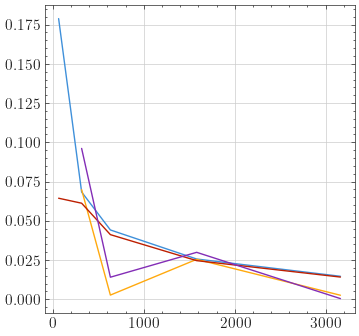

In [45]:
fig = plt.figure(figsize=(4,4))
ax = plt.subplot(111)
color_arr = ['#3F90DA', '#FFA90E', '#BD1F01', '#94A4A2', '#832DB6', '#A96B59', '#E76300', '#B9AC70', '#92DADD']
####################################### qmagpi
ETA_ARR = [1,2,5,10,50]
# First VA_N_Arr[8]
tol = 1E-3
i2 = 6
ii = np.where(np.abs(VA_h_MCI1_Az_ETA1_divr_q2magpisq-(vA/(r1*Omega0))[6]) < tol)[0][0]

print(ii)
print(vA[i2]/(r1*Omega0))
print(VA_h_MCI1_Az_ETA5_divr_q2magpisq[ii])
di = 0
gr_temp = np.array([gr_1k1_MCI_h_Az_ETA1_divr_q2magpisq[ii], gr_1k1_MCI_h_Az_ETA2_divr_q2magpisq[ii], gr_1k1_MCI_h_Az_ETA5_divr_q2magpisq[ii], gr_1k1_MCI_h_Az_ETA10_divr_q2magpisq[ii], gr_1k1_MCI_h_Az_ETA50_divr_q2magpisq[ii]])
GRS_bz70 = np.array(gr_70g[2:len(gr_70g)-1])
error_bz70 = np.abs((GRS_bz70/Omega0-gr_temp)/(GRS_bz70/Omega0))

# First VA_N_Arr[9]
tol = 1E-3
i2 = 7
di = 0
ii = np.where(np.abs(VA_h_MCI1_Az_ETA1_divr_q2magpisq-(vA/(r1*Omega0))[i2]) < tol)[0][0]
print(ii)
print(vA[i2]/(r1*Omega0))
print(VA_h_MCI1_Az_ETA5_divr_q2magpisq[ii])
gr_temp = np.array([gr_1k1_MCI_h_Az_ETA1_divr_q2magpisq[ii], gr_1k1_MCI_h_Az_ETA2_divr_q2magpisq[ii], gr_1k1_MCI_h_Az_ETA5_divr_q2magpisq[ii], gr_1k1_MCI_h_Az_ETA10_divr_q2magpisq[ii], gr_1k1_MCI_h_Az_ETA50_divr_q2magpisq[ii]])
GRS_bz80 = np.array(gr_80g[2:len(gr_80g)-1])
error_bz80 = np.abs((GRS_bz80/Omega0-gr_temp)/(GRS_bz80/Omega0))

####################################### WKB
ETA_ARR = [1,2,5,10,50]
# First VA_N_Arr[8]
tol = 1E-3
i2 = 6
ii = np.where(np.abs(VA_h_MCI1_Az_ETA1_divr_q2magpisq-(vA/(r1*Omega0))[6]) < tol)[0][0]

print('index = ')
print(ii)
print(vA[i2]/(r1*Omega0))
print(VA_h_MCI1_Az_ETA5_divr_q2magpisq[ii])
di = 0
gr_temp = np.array([gr_1k1_MCI_h_Az_ETA1_divr_WKB_div4[ii], gr_1k1_MCI_h_Az_ETA2_divr_WKB_div4[ii], gr_1k1_MCI_h_Az_ETA5_divr_WKB_div4[ii], gr_1k1_MCI_h_Az_ETA10_divr_WKB_div4[ii], gr_1k1_MCI_h_Az_ETA50_divr_WKB_div4[ii]])
GRS_bz70 = np.array(gr_70g[2:len(gr_70g)-1])
error_bz70_WKB = np.abs((GRS_bz70/Omega0-gr_temp)/(GRS_bz70/Omega0))

# First VA_N_Arr[9]
tol = 1E-3
i2 = 7
di = 0
ii = np.where(np.abs(VA_h_MCI1_Az_ETA1_divr_q2magpisq-(vA/(r1*Omega0))[i2]) < tol)[0][0]
print('index = ')
print(ii)
print(vA[i2]/(r1*Omega0))
print(VA_h_MCI1_Az_ETA5_divr_q2magpisq[ii])
gr_temp = np.array([gr_1k1_MCI_h_Az_ETA1_divr_WKB_div4[ii], gr_1k1_MCI_h_Az_ETA2_divr_WKB_div4[ii], gr_1k1_MCI_h_Az_ETA5_divr_WKB_div4[ii], gr_1k1_MCI_h_Az_ETA10_divr_WKB_div4[ii], gr_1k1_MCI_h_Az_ETA50_divr_WKB_div4[ii]])
GRS_bz80 = np.array(gr_80g[2:len(gr_80g)-1])
error_bz80_WKB = np.abs((GRS_bz80/Omega0-gr_temp)/(GRS_bz80/Omega0))



box = ax.get_position()
# ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])
# ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax.legend()
Rm = r1**2*Omega0/ETA_ARR


plt.plot(Rm, error_bz70, label = r'WKB-like (70G, AR1)', color = color_arr[0])
plt.plot(Rm, error_bz80, label = r'WKB-like (80G, AR1)', color = color_arr[1])
plt.plot(Rm, error_bz70_WKB, label = r'WKB (70G, AR1)', color = color_arr[2])
plt.plot(Rm, error_bz80_WKB, label = r'WKB (80G, AR1)', color = color_arr[4])

plt.plot(Rm, error_bz20_AR0, label = r'WKB-like (20G, AR0)', color = color_arr[0])
plt.plot(Rm, error_bz30_AR0, label = r'WKB-like (30G, AR0)', color = color_arr[1])
plt.plot(Rm, error_bz40_AR0, label = r'WKB-like (40G, AR0)', color = color_arr[2])
plt.plot(Rm, error_bz20_WKB_AR0, label = r'WKB (20G, AR0)', color = color_arr[0], linestyle = 'dashed')
plt.plot(Rm, error_bz30_WKB_AR0, label = r'WKB (30G, AR0)', color = color_arr[1], linestyle = 'dashdot')
plt.plot(Rm, error_bz40_WKB_AR0, label = r'WKB (40G, AR0)', color = color_arr[2], linestyle = 'dotted')

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.legend()
plt.ylabel(r'Error ($\gamma_{\mathrm{N}}-\gamma_{S})/\gamma_N$')
plt.xlabel('Magnetic Reynolds Number (Rm)')
# plt.savefig('Shooting-NIMROD-comp/GRvsAlfvenSpeed-NIMROD-Bz-divrpi.png', bbox_inches='tight')
plt.savefig('Shooting-NIMROD-comp/Shooting_Error_Az_AR.png', bbox_inches='tight', dpi = 500)
plt.savefig('Shooting-NIMROD-comp/Shooting_Error_Az_AR.svg', bbox_inches='tight', format = 'svg')

plt.show()
plt.close()

# Contour qmagpi

## initialization

In [ ]:
import os

path_home = os.getcwd()
b = os.listdir()
# print(b)
# os.chdir('Shooting-AlfvenSweep-Scaled-Data/')
# b = os.listdir()
# os.chdir(path_home)


# print(b)
dt = 1
eta_arr = np.arange(dt, 100 + dt, dt)
r1 = 0.1 # cm to m
V0 = r1*Omega0
Rm = r1*V0/eta_arr
print(eta_arr)
# e = []
# f1 = []
# diff_modes = ['MCI_1k1'] ### ad 10k1 when done
diff_modes = ['MCI_1k1'] ### ad 10k1 when done
diff_modes = ['MCI_1k1', 'MCI_2k1', 'MRI_6k1', 'MRI_8k1', 'MRI_10k1'] ### ad 10k1 when done
diff_modes = ['MCI_1k1', 'MCI_2k1', 'MRI_6k1','MRI_8k1', 'MRI_10k1'] ### ad 10k1 when done
diff_modes = ['MRI_2k1']
diff_modes = ['MRI_3k1']
diff_modes = ['MRI_4k1']
diff_modes = ['MRI_5k1']
diff_modes = ['MCI_3k1']

diff_modes = ['MCI_1k1', 'MCI_2k1','MCI_3k1','MRI_4k1', 'MRI_6k1','MRI_8k1','MRI_10k1'] ### ad 10k1 when done
print(len(diff_modes))
print(len(diff_modes))

# str_fit = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[0] + '_guessesu_'
# print(len(str_fit))
# # print(b)
# matches = [int(x[50:]) for x in b if x[:50] == str_fit]
# print(matches)

e = []
f1 = []
for k in range(0,len(diff_modes)):
    d = []
    d1 = []

    if(diff_modes[k] ==  'MCI_2k1'):
        eta_arr = np.arange(1, 43 + dt, dt)
    elif(diff_modes[k] ==  'MCI_3k1'):
        eta_arr = np.arange(1, 100 + dt, dt)
    elif(diff_modes[k] ==  'MRI_4k1'):
        eta_arr = np.arange(1, 100 + dt, dt)
    elif(diff_modes[k] ==  'MRI_6k1'):
        eta_arr = np.arange(1, 100 + dt, dt)
    elif(diff_modes[k] ==  'MRI_8k1'):
        eta_arr = np.arange(1, 98 + dt, dt)
    elif(diff_modes[k] ==  'MRI_10k1'):
        eta_arr = np.arange(1, 94 + dt, dt)
    else:
        eta_arr = np.arange(dt, 100 + dt, dt)
        
        
    for l in eta_arr:
        # print(l)
        elecd_str = f'{l}'
    
        guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesu_' + elecd_str + '-kep-Az-res-divr-qmagpi.pkl'
        guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesd_' + elecd_str + '-kep-Az-res-divr-qmagpi.pkl'
        VA_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANUP_' + elecd_str + '-kep-Az-res-divr-qmagpi.pkl'
        VA_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANDOWN_' + elecd_str + '-kep-Az-res-divr-qmagpi.pkl'

    
        with open(guesses_str_d, 'rb') as f:
            guesses_1k1_MCI_l = pickle.load(f)    
        with open(guesses_str_u, 'rb') as f:
            guesses_1k1_MCI_h = pickle.load(f)    
        
        with open(VA_d, 'rb') as f:
            VA_l_MCI1_Bz_ETA1_divr_WKB_div4 = pickle.load(f)    
        with open(VA_u, 'rb') as f:
            VA_h_MCI1_Bz_ETA1_divr_WKB_div4 = pickle.load(f)   
            
        gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4= []
        gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4 = []
        for j in range(0,len(guesses_1k1_MCI_l)):
            gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_l[j].imag)
        for j in range(0,len(guesses_1k1_MCI_h) ):
            gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_h[j].imag)    
        freq_1k1_MCI_l_Bz_ETA1_divr_WKB_div4 = []
        freq_1k1_MCI_h_Bz_ETA1_divr_WKB_div4 = []
        for j in range(0,len(guesses_1k1_MCI_l)):
            freq_1k1_MCI_l_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_l[j].real)
            
        for j in range(0,len(guesses_1k1_MCI_h)):
            freq_1k1_MCI_h_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_h[j].real)
    
        # gr_tot = np.concat((gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4[100:len(gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4)], gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4))
        # # print(len(VA_d))
        # # print(len(VA_u))
        # VA_N_total = np.concat((VA_l_MCI1_Bz_ETA1_divr_WKB_div4[100:len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)], VA_h_MCI1_Bz_ETA1_divr_WKB_div4))
    
        # gr_tot = np.concat(((gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4[1:len(gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4)]), gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4))
        # VA_N_total = np.concat(((VA_l_MCI1_Bz_ETA1_divr_WKB_div4[1:len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)]), VA_h_MCI1_Bz_ETA1_divr_WKB_div4))
    
        e12 = np.zeros(len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4) - 1)
        f12 = np.zeros(len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4) - 1)
        VA12 = np.zeros(len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4) - 1)
        # e12[0:len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)] = np.flip(gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4[:])
        # VA12[0:len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)] = np.flip(VA_l_MCI1_Bz_ETA1_divr_WKB_div4[:])
        e12[0:len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)] = np.flip(gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4[:])
        f12[0:len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)] = np.flip(freq_1k1_MCI_l_Bz_ETA1_divr_WKB_div4[:])
        VA12[0:len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)] = np.flip(VA_l_MCI1_Bz_ETA1_divr_WKB_div4[:])
    
        e12[len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4):len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)-1] = gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4[1:len(gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4)]
        f12[len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4):len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)-1] = freq_1k1_MCI_h_Bz_ETA1_divr_WKB_div4[1:len(gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4)]
        VA12[len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4):len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)-1] = VA_h_MCI1_Bz_ETA1_divr_WKB_div4[1:len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)]
    
        VA_N_total = VA12
        gr_tot = e12
        # print(len(gr_tot))
        # print(j)
        d.append(gr_tot)
        d1.append(f12)

    # print(len(d))
    e.append(d)
    f1.append(d1)
eta_arr = np.arange(dt, 100 + dt, dt)
e11 = np.zeros((len(gr_tot), len(eta_arr), len(diff_modes)))
f11 = np.zeros((len(gr_tot), len(eta_arr), len(diff_modes)))

# print(len(d))
print(np.shape(e11))
for k in range(0,len(diff_modes)):
    len_eta = len(e[k])
    for j in range(0,len_eta):
        # print(e[k][j])
        # print(k)
        # print(j)
        # # print(len(e[k][j]))
        # print(len(e[k][j]))
        # print(k)
        # print(j)
        e11[0:len(e[k][j]),j,k] = e[k][j][:]
        f11[0:len(f1[k][j]),j,k] = f1[k][j][:]

[  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100]
7
7
(3842, 100, 7)


## Freq

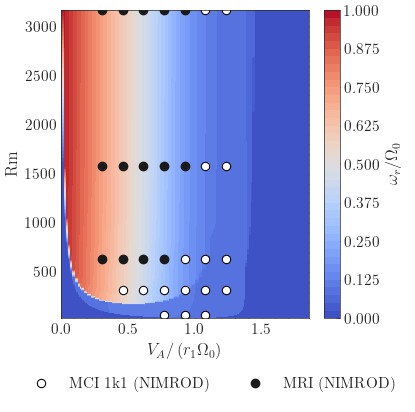

In [ ]:
e11_ii = np.where(e11 <= 0)
e11[e11_ii[:]] = 0



### Take slices of maximum gr at given freq:
gr_ijk = np.zeros((len(gr_tot), len(eta_arr)))
gr_ijk_ii = np.zeros((len(gr_tot), len(eta_arr)))
freq_ijk = np.zeros((len(gr_tot), len(eta_arr)))
for i in range(0,np.shape(e11)[0]):
    for j in range(0,np.shape(e11)[1]):
        for k in range(0,np.shape(e11)[2]):
            if(e11[i,j,k] > gr_ijk[i,j]):
                gr_ijk[i,j] = e11[i,j,k]
                gr_ijk_ii[i,j] = k+1
                freq_ijk[i,j] = f11[i,j,k]
                
fig,ax2 = plt.subplots(1)
ax2.set(xlabel=r'$V_A/(r_1\Omega_0)$', ylabel=r"Rm")
fig.set_figheight(4)
fig.set_figwidth(4)
########## MCI MODES
for i in range(2, len(etaplot_AR1)-1):
    ## Note 8/10 because of scaling w/ bb of other sims
    MCI_modes = [6,6,6,6,5,2,4]  
    ll = len(vA)-1  
    MCI_modes_h = [ll, ll, ll, ll,ll,ll,ll-1]    
    if(i == 3): 
        plt.plot(vA[MCI_modes[i]:MCI_modes_h[i]]/(r1_AR1*Omega0), r1**2*Omega0/eta_arrN[i]*np.ones(len(vA[MCI_modes[i]:MCI_modes_h[i]])), 'o', color = 'w', markeredgecolor='black', markeredgewidth = 0.75, label = 'MCI 1k1 (NIMROD)')  
    else:
        plt.plot(vA[MCI_modes[i]:MCI_modes_h[i]]/(r1_AR1*Omega0), r1**2*Omega0/eta_arrN[i]*np.ones(len(vA[MCI_modes[i]:MCI_modes_h[i]])), 'o', color = 'w', markeredgecolor='black', markeredgewidth = 0.75)  

### MRI MODES
for i in range(2, len(etaplot_AR1)-3):
    ## Note 8/10 because of scaling w/ bb of other sims
    MCI_modes = [1,1,1,1,1,1,1]  
    ll = len(vA)-1  
    MCI_modes_h = [ll-2, ll-2, ll-2, ll-2,ll-3]     
    if(i == 3):
        plt.plot(vA[MCI_modes[i]:MCI_modes_h[i]]/(r1_AR1*Omega0), r1**2*Omega0/eta_arrN[i]*np.ones(len(vA[MCI_modes[i]:MCI_modes_h[i]])), 'o', color = 'k', label = 'MRI (NIMROD)')
    else:
        plt.plot(vA[MCI_modes[i]:MCI_modes_h[i]]/(r1_AR1*Omega0), r1**2*Omega0/eta_arrN[i]*np.ones(len(vA[MCI_modes[i]:MCI_modes_h[i]])), 'o', color = 'k')


### RM 
r1 = 0.1 # cm to m
V0 = r1*Omega0
Rm = r1*V0/eta_arr


plt.contourf(VA_N_total, Rm, np.transpose((freq_ijk)),40, cmap ='coolwarm')
plt.ylabel(r'Rm')
plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
# Add a colorbar
cbar = plt.colorbar()
# Add a label to the colorbar
cbar.set_label(r'$\omega_r/\Omega_0$')
# plt.title(r'Dominant Mode at fixed Rm and $V_A$')

lines_labels = [ax2.get_legend_handles_labels() for ax2 in fig.axes]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
fig.legend(lines, labels, loc='lower center', ncol=2, 
           bbox_to_anchor=(0.5, -0.15),  # Position the legend below the plot
           frameon=False,  # Turn on the frame (border)
           edgecolor='black',  # Set the border color
           facecolor='white',  # Set the background color of the legend box
           borderpad=1,  # Padding between the legend text and the border
           borderaxespad=1)

plt.savefig('Rm-vA-Kep-freq-qmagpi-Az.png', dpi = 400)
plt.savefig('Rm-vA-Kep-freq-qmagpi-Az.svg', format = 'svg')

plt.show()

## ETA vs VA

7
[0. 1. 2. 3. 4. 5. 6. 7.]


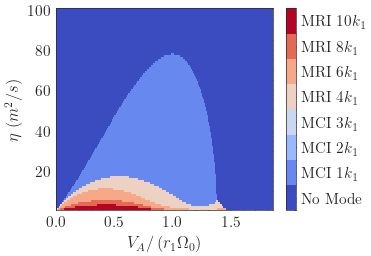

In [ ]:
from matplotlib.colors import BoundaryNorm
from matplotlib.ticker import MaxNLocator
# x and y are bounds, so z should be the value *inside* those bounds.
# Therefore, remove the last value from the z array.
gr_ijk_ii_plot = np.transpose(gr_ijk_ii)

nticks = len(diff_modes) 
levels_arr = np.zeros(len(diff_modes)+1)
ticks_arr = np.zeros(len(diff_modes)+1)
for j in range(0, len(diff_modes)+1):
    ticks_arr[j] = j
    levels_arr[j] = j
print(nticks)
print(ticks_arr)

ticks_arr = ticks_arr +0.5
# print(ti
levels = [0,1,2,3,4,5,6,7,8]
# levels = [0,1,2,3,4,5,6,7,8,9,10,11]
# pick the desired colormap, sensible levels, and define a normalization
# instance which takes data values and translates those into levels.
cmap = plt.colormaps['coolwarm']
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)

plt.figure()

contour = plt.pcolormesh(VA_N_total, eta_arr, gr_ijk_ii_plot, cmap=cmap, norm=norm)
# cbar = plt.colorbar(im, ax=ax0)
cbar = plt.colorbar(contour,  ticks=ticks_arr)
cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$', r'MCI $3k_1$', r'MRI $4k_1$', r'MRI $6k_1$', r'MRI $8k_1$', r'MRI $10k_1$'])
# cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$',  r'MCI $3k_1$',  r'MRI $2k_1$',  r'MRI $3k_1$',  r'MRI $4k_1$',  r'MRI $5k_1$', r'MRI $6k_1$', r'MRI $8k_1$', r'MRI $10k_1$'])

plt.ylabel(r'$\eta$  $(m^2/s)$')
plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
# plt.title(r'Dominant Mode at fixed $\eta$ and $V_A$')
plt.savefig('Eta-vA-Kep-dommode-qmagpi-Az.png', dpi = 400)
plt.savefig('Eta-vA-Kep-dommode-qmagpi-Az.svg', format = 'svg')

plt.show()


In [ ]:
j_mark = 0
k_mark = 0
gr_ii = np.where(gr_ijk_ii_plot == 1)
# print(gr_ii)
# print(np.where(gr_ii[0] == np.max(gr_ii[0])))
# print(gr_ii)

VA_N_total[gr_ii[1][:]]
# print(eta_arr[gr_ii[0][:]])
print(np.max((eta_arr[gr_ii[0][:]])))
jj = np.where(eta_arr[gr_ii[0][:]] == np.max(eta_arr[gr_ii[0][:]]))
# print(jj)
kk = VA_N_total[gr_ii[1][:]][jj[:]]
# print(kk)
# VAm = VA_N_total[jj[:]][0]
# VAm = VA_N_total[gr_ii[1][:]][jj[:]][0]
# VAm = VA_N_total[jj[:]][0]
VAm = kk[0]
print(VAm)
Rmm = r1**2*Omega0/np.max((eta_arr[gr_ii[0][:]]))
print(f'Minimum Rm: {Rmm}')

78
0.9820070971838548
Minimum Rm: 40.542021284209994


## Rm vs VA

### Mode Chose NIMROD

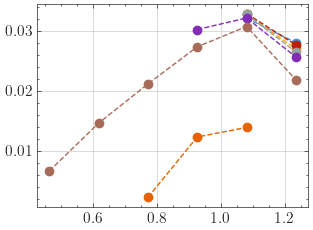

In [ ]:
plt.figure()
for i in range(0, len(etaplot_AR1)-1):
    ## Note 8/10 because of scaling w/ bb of other sims
    MCI_modes = [6,6,6,6,5,2,4]  
    ll = len(vA)-1  
    MCI_modes_h = [ll, ll, ll, ll,ll,ll,ll-1]     
    plt.plot(vA[MCI_modes[i]:MCI_modes_h[i]]/(r1_AR1*Omega0), etaplot_AR1[i][MCI_modes[i]:MCI_modes_h[i]]/(Omega0), 'o', linestyle = '--', label=r'NIMROD, Rm = ' + str(int(Rm[i])), color = color_arr[i])

plt.show()


### MRI Points
for i in range(0, len(etaplot_AR1)-1):
    ## Note 8/10 because of scaling w/ bb of other sims
    MCI_modes = [6,6,6,6,5,2,4]  
    ll = len(vA)-1  
    MCI_modes_h = [ll, ll, ll, ll,ll,ll,ll-1]     
    plt.plot(vA[MCI_modes[i]:MCI_modes_h[i]]/(r1_AR1*Omega0), r1**2*Omega0/eta_arr[i], 'o', linestyle = '--', label=r'NIMROD, Rm = ' + str(int(Rm[i])), color = color_arr[i])

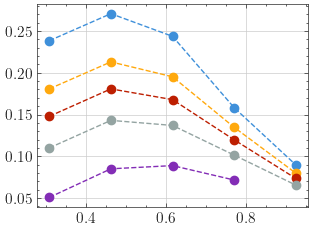

In [ ]:
plt.figure()
for i in range(0, len(etaplot_AR1)-3):
    ## Note 8/10 because of scaling w/ bb of other sims
    MCI_modes = [1,1,1,1,1,1,1]  
    ll = len(vA)-1  
    MCI_modes_h = [ll-2, ll-2, ll-2, ll-2,ll-3]     
    plt.plot(vA[MCI_modes[i]:MCI_modes_h[i]]/(r1_AR1*Omega0), etaplot_AR1[i][MCI_modes[i]:MCI_modes_h[i]]/(Omega0), 'o', linestyle = '--', label=r'NIMROD, Rm = ' + str(int(Rm[i])), color = color_arr[i])

plt.show()


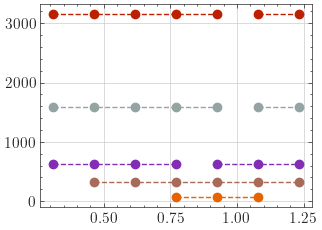

In [ ]:
eta_arrN = [0.1,0.5,1,2,5,10, 50, 100]
### MRI Points
plt.figure()
for i in range(2, len(etaplot_AR1)-1):
    ## Note 8/10 because of scaling w/ bb of other sims
    MCI_modes = [6,6,6,6,5,2,4]  
    ll = len(vA)-1  
    MCI_modes_h = [ll, ll, ll, ll,ll,ll,ll-1]     
    plt.plot(vA[MCI_modes[i]:MCI_modes_h[i]]/(r1_AR1*Omega0), r1**2*Omega0/eta_arrN[i]*np.ones(len(vA[MCI_modes[i]:MCI_modes_h[i]])), 'o', linestyle = '--', label=r'NIMROD, Rm = ' + str(int(Rm[i])), color = color_arr[i])

for i in range(2, len(etaplot_AR1)-3):
    ## Note 8/10 because of scaling w/ bb of other sims
    MCI_modes = [1,1,1,1,1,1,1]  
    ll = len(vA)-1  
    MCI_modes_h = [ll-2, ll-2, ll-2, ll-2,ll-3]     
    plt.plot(vA[MCI_modes[i]:MCI_modes_h[i]]/(r1_AR1*Omega0), r1**2*Omega0/eta_arrN[i]*np.ones(len(vA[MCI_modes[i]:MCI_modes_h[i]])), 'o', linestyle = '--', label=r'NIMROD, Rm = ' + str(int(Rm[i])), color = color_arr[i])

plt.show()


### Else

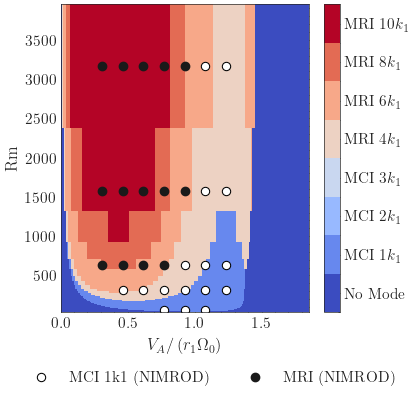

In [ ]:

### Coolwarm good cmap
# Spectral OK
# RdGy OK
fig,ax2 = plt.subplots(1)
ax2.set(xlabel=r'$V_A/(r_1\Omega_0)$', ylabel=r"Rm")
fig.set_figheight(4)
fig.set_figwidth(4)
levels = [0,1,2,3,4,5,6,7,8]

contour = plt.pcolormesh(VA_N_total, Rm, gr_ijk_ii_plot, cmap=cmap, norm=norm, rasterized=True)
plt.ylabel(r'Rm')
plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
# Add a colorbar

########## MCI MODES
for i in range(2, len(etaplot_AR1)-1):
    ## Note 8/10 because of scaling w/ bb of other sims
    MCI_modes = [6,6,6,6,5,2,4]  
    ll = len(vA)-1  
    MCI_modes_h = [ll, ll, ll, ll,ll,ll,ll-1]    
    if(i == 3): 
        plt.plot(vA[MCI_modes[i]:MCI_modes_h[i]]/(r1_AR1*Omega0), r1**2*Omega0/eta_arrN[i]*np.ones(len(vA[MCI_modes[i]:MCI_modes_h[i]])), 'o', color = 'w', markeredgecolor='black', markeredgewidth = 0.75, label = 'MCI 1k1 (NIMROD)')  
    else:
        plt.plot(vA[MCI_modes[i]:MCI_modes_h[i]]/(r1_AR1*Omega0), r1**2*Omega0/eta_arrN[i]*np.ones(len(vA[MCI_modes[i]:MCI_modes_h[i]])), 'o', color = 'w', markeredgecolor='black', markeredgewidth = 0.75)  

### MRI MODES
for i in range(2, len(etaplot_AR1)-3):
    ## Note 8/10 because of scaling w/ bb of other sims
    MCI_modes = [1,1,1,1,1,1,1]  
    ll = len(vA)-1  
    MCI_modes_h = [ll-2, ll-2, ll-2, ll-2,ll-3]     
    if(i == 3):
        plt.plot(vA[MCI_modes[i]:MCI_modes_h[i]]/(r1_AR1*Omega0), r1**2*Omega0/eta_arrN[i]*np.ones(len(vA[MCI_modes[i]:MCI_modes_h[i]])), 'o', color = 'k', label = 'MRI (NIMROD)')
    else:
        plt.plot(vA[MCI_modes[i]:MCI_modes_h[i]]/(r1_AR1*Omega0), r1**2*Omega0/eta_arrN[i]*np.ones(len(vA[MCI_modes[i]:MCI_modes_h[i]])), 'o', color = 'k')




tickss = np.array([0,1,2,3,4,5,6,7])+ 0.5
cbar = plt.colorbar(contour,  ticks=tickss) 
cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$', r'MCI $3k_1$', r'MRI $4k_1$', r'MRI $6k_1$', r'MRI $8k_1$', r'MRI $10k_1$'])

# Add a label to the colorbar
# plt.title(r'Dominant Mode (Rm vs $V_A$)')
# plt.legend()
lines_labels = [ax2.get_legend_handles_labels() for ax2 in fig.axes]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
fig.legend(lines, labels, loc='lower center', ncol=2, 
           bbox_to_anchor=(0.5, -0.15),  # Position the legend below the plot
           frameon=False,  # Turn on the frame (border)
           edgecolor='black',  # Set the border color
           facecolor='white',  # Set the background color of the legend box
           borderpad=1,  # Padding between the legend text and the border
           borderaxespad=1)

plt.savefig('Rm-vA-Kep-dommode-qmagpi-Az.png', dpi = 400)
plt.savefig('Rm-vA-Kep-dommode-qmagpi-Az.svg', format = 'svg', dpi = 300)
plt.show()


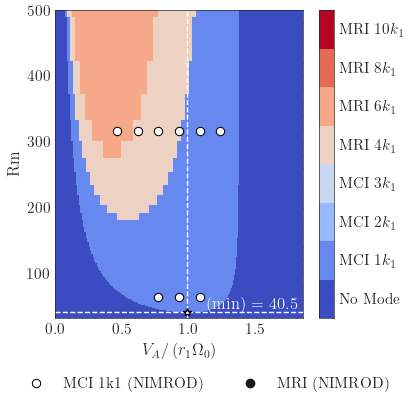

In [ ]:

################ Zoom
fig,ax2 = plt.subplots(1)
ax2.set(xlabel=r'$V_A/(r_1\Omega_0)$', ylabel=r"Rm")
fig.set_figheight(4)
fig.set_figwidth(4)
levels = [0,1,2,3,4,5,6,7,8]

contour = plt.pcolormesh(VA_N_total, Rm, gr_ijk_ii_plot, cmap=cmap, norm=norm, rasterized=True)
plt.ylabel(r'Rm')
plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
# Add a colorbar

########## MCI MODES
for i in range(2, len(etaplot_AR1)-1):
    ## Note 8/10 because of scaling w/ bb of other sims
    MCI_modes = [6,6,6,6,5,2,4]  
    ll = len(vA)-1  
    MCI_modes_h = [ll, ll, ll, ll,ll,ll,ll-1]    
    if(i == 3): 
        plt.plot(vA[MCI_modes[i]:MCI_modes_h[i]]/(r1_AR1*Omega0), r1**2*Omega0/eta_arrN[i]*np.ones(len(vA[MCI_modes[i]:MCI_modes_h[i]])), 'o', color = 'w', markeredgecolor='black', markeredgewidth = 0.75, label = 'MCI 1k1 (NIMROD)')  
    else:
        plt.plot(vA[MCI_modes[i]:MCI_modes_h[i]]/(r1_AR1*Omega0), r1**2*Omega0/eta_arrN[i]*np.ones(len(vA[MCI_modes[i]:MCI_modes_h[i]])), 'o', color = 'w', markeredgecolor='black', markeredgewidth = 0.75)  

### MRI MODES
for i in range(2, len(etaplot_AR1)-3):
    ## Note 8/10 because of scaling w/ bb of other sims
    MCI_modes = [1,1,1,1,1,1,1]  
    ll = len(vA)-1  
    MCI_modes_h = [ll-2, ll-2, ll-2, ll-2,ll-3]     
    if(i == 3):
        plt.plot(vA[MCI_modes[i]:MCI_modes_h[i]]/(r1_AR1*Omega0), r1**2*Omega0/eta_arrN[i]*np.ones(len(vA[MCI_modes[i]:MCI_modes_h[i]])), 'o', color = 'k', label = 'MRI (NIMROD)')
    else:
        plt.plot(vA[MCI_modes[i]:MCI_modes_h[i]]/(r1_AR1*Omega0), r1**2*Omega0/eta_arrN[i]*np.ones(len(vA[MCI_modes[i]:MCI_modes_h[i]])), 'o', color = 'k')


tickss = np.array([0,1,2,3,4,5,6,7])+ 0.5
cbar = plt.colorbar(contour,  ticks=tickss) 
cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$', r'MCI $3k_1$', r'MRI $4k_1$', r'MRI $6k_1$', r'MRI $8k_1$', r'MRI $10k_1$'])

# Add a label to the colorbar
# plt.title(r'Dominant Mode (Rm vs $V_A$)')
# plt.legend()
plt.ylim(np.min(Rm), 500)


plt.axvline(x = VAm, color = 'w', linestyle = 'dashed')
plt.axhline(y = Rmm, color = 'w', linestyle = 'dashed')
plt.plot(VAm, Rmm, color = 'w', marker = '*', markeredgecolor='black')
plt.text(VAm + 0.15, Rmm+5, f'(min) = {np.round(Rmm, 1)}', fontsize=12, color='w', fontweight='bold')


lines_labels = [ax2.get_legend_handles_labels() for ax2 in fig.axes]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
fig.legend(lines, labels, loc='lower center', ncol=2, 
           bbox_to_anchor=(0.5, -0.15),  # Position the legend below the plot
           frameon=False,  # Turn on the frame (border)
           edgecolor='black',  # Set the border color
           facecolor='white',  # Set the background color of the legend box
           borderpad=1,  # Padding between the legend text and the border
           borderaxespad=1)
plt.savefig('Rm-vA-Kep-dommode-qmagpi-zoom-Az.png', dpi = 400)
plt.savefig('Rm-vA-Kep-dommode-qmagpi-zoom-Az.svg', format = 'svg', dpi = 300)
plt.show()


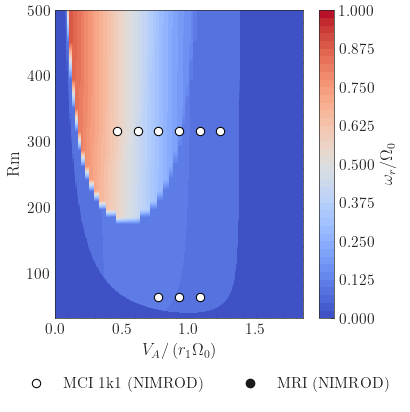

In [ ]:

################ Zoom
fig,ax2 = plt.subplots(1)
ax2.set(xlabel=r'$V_A/(r_1\Omega_0)$', ylabel=r"Rm")
fig.set_figheight(4)
fig.set_figwidth(4)
levels = [0,1,2,3,4,5,6,7,8]

contour = plt.contourf(VA_N_total, Rm, np.transpose((freq_ijk)),40, cmap ='coolwarm')

plt.ylabel(r'Rm')
plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
# Add a colorbar

########## MCI MODES
for i in range(2, len(etaplot_AR1)-1):
    ## Note 8/10 because of scaling w/ bb of other sims
    MCI_modes = [6,6,6,6,5,2,4]  
    ll = len(vA)-1  
    MCI_modes_h = [ll, ll, ll, ll,ll,ll,ll-1]    
    if(i == 3): 
        plt.plot(vA[MCI_modes[i]:MCI_modes_h[i]]/(r1_AR1*Omega0), r1**2*Omega0/eta_arrN[i]*np.ones(len(vA[MCI_modes[i]:MCI_modes_h[i]])), 'o', color = 'w', markeredgecolor='black', markeredgewidth = 0.75, label = 'MCI 1k1 (NIMROD)')  
    else:
        plt.plot(vA[MCI_modes[i]:MCI_modes_h[i]]/(r1_AR1*Omega0), r1**2*Omega0/eta_arrN[i]*np.ones(len(vA[MCI_modes[i]:MCI_modes_h[i]])), 'o', color = 'w', markeredgecolor='black', markeredgewidth = 0.75)  

### MRI MODES
for i in range(2, len(etaplot_AR1)-3):
    ## Note 8/10 because of scaling w/ bb of other sims
    MCI_modes = [1,1,1,1,1,1,1]  
    ll = len(vA)-1  
    MCI_modes_h = [ll-2, ll-2, ll-2, ll-2,ll-3]     
    if(i == 3):
        plt.plot(vA[MCI_modes[i]:MCI_modes_h[i]]/(r1_AR1*Omega0), r1**2*Omega0/eta_arrN[i]*np.ones(len(vA[MCI_modes[i]:MCI_modes_h[i]])), 'o', color = 'k', label = 'MRI (NIMROD)')
    else:
        plt.plot(vA[MCI_modes[i]:MCI_modes_h[i]]/(r1_AR1*Omega0), r1**2*Omega0/eta_arrN[i]*np.ones(len(vA[MCI_modes[i]:MCI_modes_h[i]])), 'o', color = 'k')

tickss = np.array([0,1,2,3,4,5,6,7])+ 0.5
cbar = plt.colorbar(contour) 
cbar.set_label(r'$\omega_r/\Omega_0$')
# cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$', r'MCI $3k_1$', r'MRI $4k_1$', r'MRI $6k_1$', r'MRI $8k_1$', r'MRI $10k_1$'])

# Add a label to the colorbar
# plt.title(r'Dominant Mode (Rm vs $V_A$)')
# plt.legend()
plt.ylim(np.min(Rm), 500)
# Add a label to the colorbar
# plt.title(r'Dominant Mode (Rm vs $V_A$)')
# plt.legend()
lines_labels = [ax2.get_legend_handles_labels() for ax2 in fig.axes]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
fig.legend(lines, labels, loc='lower center', ncol=2, 
           bbox_to_anchor=(0.5, -0.15),  # Position the legend below the plot
           frameon=False,  # Turn on the frame (border)
           edgecolor='black',  # Set the border color
           facecolor='white',  # Set the background color of the legend box
           borderpad=1,  # Padding between the legend text and the border
           borderaxespad=1)
plt.savefig('Rm-vA-Kep-dommode-freq-zoom-Az.png', dpi = 400)
plt.savefig('Rm-vA-Kep-dommode-freq-zoom-Az.svg', format = 'svg')

plt.show()


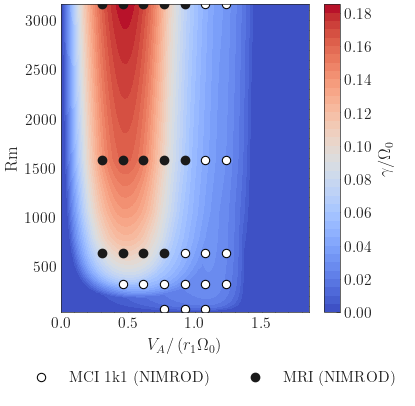

In [ ]:

################ Zoom
fig,ax2 = plt.subplots(1)
ax2.set(xlabel=r'$V_A/(r_1\Omega_0)$', ylabel=r"Rm")
fig.set_figheight(4)
fig.set_figwidth(4)
levels = [0,1,2,3,4,5,6,7,8]

########## MCI MODES
for i in range(2, len(etaplot_AR1)-1):
    ## Note 8/10 because of scaling w/ bb of other sims
    MCI_modes = [6,6,6,6,5,2,4]  
    ll = len(vA)-1  
    MCI_modes_h = [ll, ll, ll, ll,ll,ll,ll-1]    
    if(i == 3): 
        plt.plot(vA[MCI_modes[i]:MCI_modes_h[i]]/(r1_AR1*Omega0), r1**2*Omega0/eta_arrN[i]*np.ones(len(vA[MCI_modes[i]:MCI_modes_h[i]])), 'o', color = 'w', markeredgecolor='black', markeredgewidth = 0.75, label = 'MCI 1k1 (NIMROD)')  
    else:
        plt.plot(vA[MCI_modes[i]:MCI_modes_h[i]]/(r1_AR1*Omega0), r1**2*Omega0/eta_arrN[i]*np.ones(len(vA[MCI_modes[i]:MCI_modes_h[i]])), 'o', color = 'w', markeredgecolor='black', markeredgewidth = 0.75)  

### MRI MODES
for i in range(2, len(etaplot_AR1)-3):
    ## Note 8/10 because of scaling w/ bb of other sims
    MCI_modes = [1,1,1,1,1,1,1]  
    ll = len(vA)-1  
    MCI_modes_h = [ll-2, ll-2, ll-2, ll-2,ll-3]     
    if(i == 3):
        plt.plot(vA[MCI_modes[i]:MCI_modes_h[i]]/(r1_AR1*Omega0), r1**2*Omega0/eta_arrN[i]*np.ones(len(vA[MCI_modes[i]:MCI_modes_h[i]])), 'o', color = 'k', label = 'MRI (NIMROD)')
    else:
        plt.plot(vA[MCI_modes[i]:MCI_modes_h[i]]/(r1_AR1*Omega0), r1**2*Omega0/eta_arrN[i]*np.ones(len(vA[MCI_modes[i]:MCI_modes_h[i]])), 'o', color = 'k')


gr_ijk_log = np.zeros(np.shape(gr_ijk))
gr_ijk_jj = np.where(gr_ijk != 0)
gr_ijk_log[gr_ijk_jj[:]] = np.log(gr_ijk[gr_ijk_jj[:]])
contour = plt.contourf(VA_N_total, Rm, np.transpose(gr_ijk), cmap=cmap, levels = 40)
cbar = plt.colorbar()
cbar.set_label(r'$\gamma/\Omega_0$')

plt.ylabel(r'Rm')
plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
# Add a colorbar

# Add a label to the colorbar
# plt.title(r'Dominant Mode (Rm vs $V_A$)')
# plt.legend()
lines_labels = [ax2.get_legend_handles_labels() for ax2 in fig.axes]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
fig.legend(lines, labels, loc='lower center', ncol=2, 
           bbox_to_anchor=(0.5, -0.15),  # Position the legend below the plot
           frameon=False,  # Turn on the frame (border)
           edgecolor='black',  # Set the border color
           facecolor='white',  # Set the background color of the legend box
           borderpad=1,  # Padding between the legend text and the border
           borderaxespad=1)
plt.savefig('Rm-vA-Kep-Gr-qmagpi-Az.png', dpi = 400)
plt.savefig('Rm-vA-Kep-Gr-qmagpi-Az.svg', format = 'svg')

plt.show()

# WKB

In [ ]:
import os

path_home = os.getcwd()
b = os.listdir()
# print(b)
# os.chdir('Shooting-AlfvenSweep-Scaled-Data/')
# b = os.listdir()
# os.chdir(path_home)


# print(b)
dt = 1
eta_arr = np.arange(dt, 100 + dt, dt)
r1 = 0.1 # cm to m
V0 = r1*Omega0
Rm = r1*V0/eta_arr
print(eta_arr)
# e = []
# f1 = []
# diff_modes = ['MCI_1k1'] ### ad 10k1 when done
diff_modes = ['MCI_1k1'] ### ad 10k1 when done
diff_modes = ['MCI_1k1', 'MCI_2k1', 'MRI_6k1', 'MRI_8k1', 'MRI_10k1'] ### ad 10k1 when done
diff_modes = ['MCI_1k1', 'MCI_2k1', 'MRI_6k1','MRI_8k1', 'MRI_10k1'] ### ad 10k1 when done
diff_modes = ['MRI_2k1']
diff_modes = ['MRI_3k1']
diff_modes = ['MRI_4k1']
diff_modes = ['MRI_5k1']
diff_modes = ['MCI_3k1']

diff_modes = ['MCI_1k1', 'MCI_2k1','MCI_3k1','MRI_4k1', 'MRI_6k1','MRI_8k1','MRI_10k1'] ### ad 10k1 when done
print(len(diff_modes))
print(len(diff_modes))

# str_fit = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[0] + '_guessesu_'
# print(len(str_fit))
# # print(b)
# matches = [int(x[50:]) for x in b if x[:50] == str_fit]
# print(matches)

e = []
f1 = []
for k in range(0,len(diff_modes)):
    d = []
    d1 = []

    if(diff_modes[k] ==  'MCI_2k1'):
        eta_arr = np.arange(1, 43 + dt, dt)
    elif(diff_modes[k] ==  'MCI_3k1'):
        eta_arr = np.arange(1, 88 + dt, dt)
    elif(diff_modes[k] ==  'MRI_4k1'):
        eta_arr = np.arange(1, 100 + dt, dt)
    elif(diff_modes[k] ==  'MRI_6k1'):
        eta_arr = np.arange(1, 100 + dt, dt)
    elif(diff_modes[k] ==  'MRI_8k1'):
        eta_arr = np.arange(1, 98 + dt, dt)
    elif(diff_modes[k] ==  'MRI_10k1'):
        eta_arr = np.arange(1, 94 + dt, dt)
    else:
        eta_arr = np.arange(dt, 100 + dt, dt)
        
        
    for l in eta_arr:
        # print(l)
        elecd_str = f'{l}'
    
        guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesu_' + elecd_str + '-kep-Az-res-divr-WKB.pkl'
        guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesd_' + elecd_str + '-kep-Az-res-divr-WKB.pkl'
        VA_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANUP_' + elecd_str + '-kep-Az-res-divr-WKB.pkl'
        VA_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANDOWN_' + elecd_str + '-kep-Az-res-divr-WKB.pkl'

    
        with open(guesses_str_d, 'rb') as f:
            guesses_1k1_MCI_l = pickle.load(f)    
        with open(guesses_str_u, 'rb') as f:
            guesses_1k1_MCI_h = pickle.load(f)    
        
        with open(VA_d, 'rb') as f:
            VA_l_MCI1_Bz_ETA1_divr_WKB_div4 = pickle.load(f)    
        with open(VA_u, 'rb') as f:
            VA_h_MCI1_Bz_ETA1_divr_WKB_div4 = pickle.load(f)   
            
        gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4= []
        gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4 = []
        for j in range(0,len(guesses_1k1_MCI_l)):
            gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_l[j].imag)
        for j in range(0,len(guesses_1k1_MCI_h) ):
            gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_h[j].imag)    
        freq_1k1_MCI_l_Bz_ETA1_divr_WKB_div4 = []
        freq_1k1_MCI_h_Bz_ETA1_divr_WKB_div4 = []
        for j in range(0,len(guesses_1k1_MCI_l)):
            freq_1k1_MCI_l_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_l[j].real)
            
        for j in range(0,len(guesses_1k1_MCI_h)):
            freq_1k1_MCI_h_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_h[j].real)
    
        # gr_tot = np.concat((gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4[100:len(gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4)], gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4))
        # # print(len(VA_d))
        # # print(len(VA_u))
        # VA_N_total = np.concat((VA_l_MCI1_Bz_ETA1_divr_WKB_div4[100:len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)], VA_h_MCI1_Bz_ETA1_divr_WKB_div4))
    
        # gr_tot = np.concat(((gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4[1:len(gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4)]), gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4))
        # VA_N_total = np.concat(((VA_l_MCI1_Bz_ETA1_divr_WKB_div4[1:len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)]), VA_h_MCI1_Bz_ETA1_divr_WKB_div4))
    
        e12 = np.zeros(len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4) - 1)
        f12 = np.zeros(len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4) - 1)
        VA12 = np.zeros(len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4) - 1)
        # e12[0:len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)] = np.flip(gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4[:])
        # VA12[0:len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)] = np.flip(VA_l_MCI1_Bz_ETA1_divr_WKB_div4[:])
        e12[0:len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)] = np.flip(gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4[:])
        f12[0:len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)] = np.flip(freq_1k1_MCI_l_Bz_ETA1_divr_WKB_div4[:])
        VA12[0:len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)] = np.flip(VA_l_MCI1_Bz_ETA1_divr_WKB_div4[:])
    
        e12[len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4):len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)-1] = gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4[1:len(gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4)]
        f12[len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4):len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)-1] = freq_1k1_MCI_h_Bz_ETA1_divr_WKB_div4[1:len(gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4)]
        VA12[len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4):len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)-1] = VA_h_MCI1_Bz_ETA1_divr_WKB_div4[1:len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)]
    
        VA_N_total = VA12
        gr_tot = e12
        # print(len(gr_tot))
        # print(j)
        d.append(gr_tot)
        d1.append(f12)

    # print(len(d))
    e.append(d)
    f1.append(d1)
eta_arr = np.arange(dt, 100 + dt, dt)
e11 = np.zeros((len(gr_tot), len(eta_arr), len(diff_modes)))
f11 = np.zeros((len(gr_tot), len(eta_arr), len(diff_modes)))

# print(len(d))
print(np.shape(e11))
for k in range(0,len(diff_modes)):
    len_eta = len(e[k])
    for j in range(0,len_eta):
        # print(e[k][j])
        # print(k)
        # print(j)
        # # print(len(e[k][j]))
        # print(len(e[k][j]))
        # print(k)
        # print(j)
        e11[0:len(e[k][j]),j,k] = e[k][j][:]
        f11[0:len(f1[k][j]),j,k] = f1[k][j][:]

[  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100]
7
7
(3842, 100, 7)


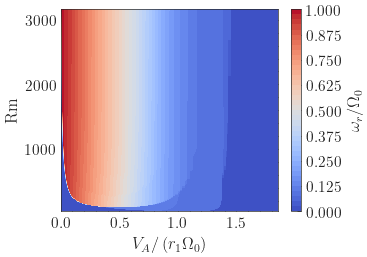

In [ ]:
e11_ii = np.where(e11 <= 0)
e11[e11_ii[:]] = 0



### Take slices of maximum gr at given freq:
gr_ijk = np.zeros((len(gr_tot), len(eta_arr)))
gr_ijk_ii = np.zeros((len(gr_tot), len(eta_arr)))
freq_ijk = np.zeros((len(gr_tot), len(eta_arr)))
for i in range(0,np.shape(e11)[0]):
    for j in range(0,np.shape(e11)[1]):
        for k in range(0,np.shape(e11)[2]):
            if(e11[i,j,k] > gr_ijk[i,j]):
                gr_ijk[i,j] = e11[i,j,k]
                gr_ijk_ii[i,j] = k+1
                freq_ijk[i,j] = f11[i,j,k]
                

### RM 
r1 = 0.1 # cm to m
V0 = r1*Omega0
Rm = r1*V0/eta_arr

fig = plt.figure()
plt.contourf(VA_N_total, Rm, np.transpose((freq_ijk)),40, cmap ='coolwarm')
plt.ylabel(r'Rm')
plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
# Add a colorbar
cbar = plt.colorbar()
# Add a label to the colorbar
cbar.set_label(r'$\omega_r/\Omega_0$')
# plt.title(r'Dominant Mode at fixed Rm and $V_A$')
plt.savefig('Rm-vA-Kep-freq-WKB-Az.png', dpi = 400)
plt.savefig('Rm-vA-Kep-freq-WKB-Az.svg', format = 'svg')

plt.show()

7
[0. 1. 2. 3. 4. 5. 6. 7.]


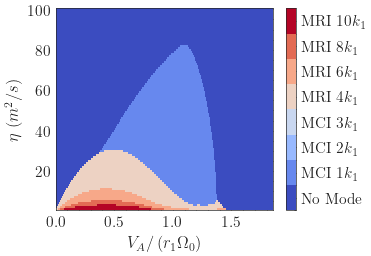

In [ ]:
from matplotlib.colors import BoundaryNorm
from matplotlib.ticker import MaxNLocator
# x and y are bounds, so z should be the value *inside* those bounds.
# Therefore, remove the last value from the z array.
gr_ijk_ii_plot = np.transpose(gr_ijk_ii)

nticks = len(diff_modes) 
levels_arr = np.zeros(len(diff_modes)+1)
ticks_arr = np.zeros(len(diff_modes)+1)
for j in range(0, len(diff_modes)+1):
    ticks_arr[j] = j
    levels_arr[j] = j
print(nticks)
print(ticks_arr)

ticks_arr = ticks_arr +0.5
# print(ti
levels = [0,1,2,3,4,5,6,7,8]
# levels = [0,1,2,3,4,5,6,7,8,9,10,11]
# pick the desired colormap, sensible levels, and define a normalization
# instance which takes data values and translates those into levels.
cmap = plt.colormaps['coolwarm']
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)

plt.figure()

contour = plt.pcolormesh(VA_N_total, eta_arr, gr_ijk_ii_plot, cmap=cmap, norm=norm)
# cbar = plt.colorbar(im, ax=ax0)
cbar = plt.colorbar(contour,  ticks=ticks_arr)
cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$', r'MCI $3k_1$', r'MRI $4k_1$', r'MRI $6k_1$', r'MRI $8k_1$', r'MRI $10k_1$'])
# cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$',  r'MCI $3k_1$',  r'MRI $2k_1$',  r'MRI $3k_1$',  r'MRI $4k_1$',  r'MRI $5k_1$', r'MRI $6k_1$', r'MRI $8k_1$', r'MRI $10k_1$'])

plt.ylabel(r'$\eta$  $(m^2/s)$')
plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
# plt.title(r'Dominant Mode at fixed $\eta$ and $V_A$')
plt.savefig('Eta-vA-Kep-dommode-WKB-Az.png', dpi = 400)
plt.savefig('Eta-vA-Kep-dommode-WKB-Az.svg', format = 'svg')

plt.show()


In [ ]:
j_mark = 0
k_mark = 0
gr_ii = np.where(gr_ijk_ii_plot == 1)
# print(gr_ii)
# print(np.where(gr_ii[0] == np.max(gr_ii[0])))
# print(gr_ii)

VA_N_total[gr_ii[1][:]]
# print(eta_arr[gr_ii[0][:]])
print(np.max((eta_arr[gr_ii[0][:]])))
jj = np.where(eta_arr[gr_ii[0][:]] == np.max(eta_arr[gr_ii[0][:]]))
# print(jj)
kk = VA_N_total[gr_ii[1][:]][jj[:]]
# print(kk)
# VAm = VA_N_total[jj[:]][0]
# VAm = VA_N_total[gr_ii[1][:]][jj[:]][0]
# VAm = VA_N_total[jj[:]][0]
VAm = kk[0]
print(VAm)
Rmm = r1**2*Omega0/np.max((eta_arr[gr_ii[0][:]]))
print(f'Minimum Rm: {Rmm}')

82
1.061538268219191
Minimum Rm: 38.56436170937048


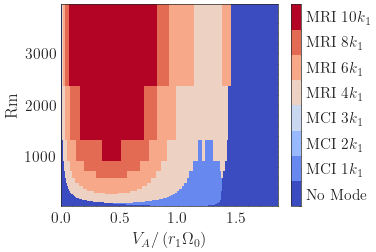

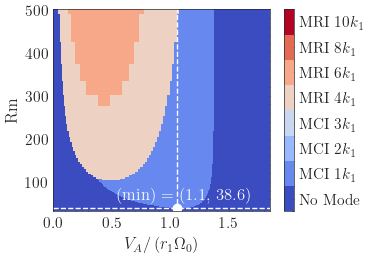

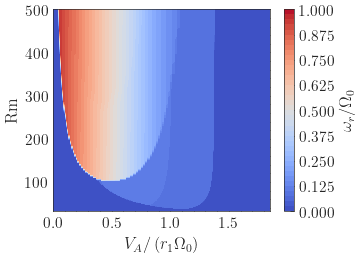

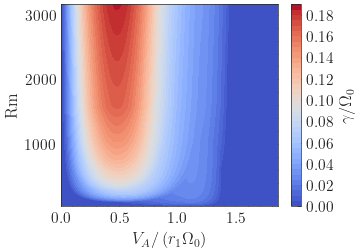

In [ ]:

### Coolwarm good cmap
# Spectral OK
# RdGy OK
fig = plt.figure()
levels = [0,1,2,3,4,5,6,7,8]

contour = plt.pcolormesh(VA_N_total, Rm, gr_ijk_ii_plot, cmap=cmap, norm=norm)
plt.ylabel(r'Rm')
plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
# Add a colorbar


tickss = np.array([0,1,2,3,4,5,6,7])+ 0.5
cbar = plt.colorbar(contour,  ticks=tickss) 
cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$', r'MCI $3k_1$', r'MRI $4k_1$', r'MRI $6k_1$', r'MRI $8k_1$', r'MRI $10k_1$'])

# Add a label to the colorbar
# plt.title(r'Dominant Mode (Rm vs $V_A$)')
# plt.legend()
plt.savefig('Rm-vA-Kep-dommode-WKB-Az.png', dpi = 400)
plt.savefig('Rm-vA-Kep-dommode-WKB-Az.svg', format = 'svg')

plt.show()

################ Zoom
fig = plt.figure()
levels = [0,1,2,3,4,5,6,7,8]

contour = plt.pcolormesh(VA_N_total, Rm, gr_ijk_ii_plot, cmap=cmap, norm=norm)
plt.ylabel(r'Rm')
plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
# Add a colorbar


tickss = np.array([0,1,2,3,4,5,6,7])+ 0.5
cbar = plt.colorbar(contour,  ticks=tickss) 
cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$', r'MCI $3k_1$', r'MRI $4k_1$', r'MRI $6k_1$', r'MRI $8k_1$', r'MRI $10k_1$'])

# Add a label to the colorbar
# plt.title(r'Dominant Mode (Rm vs $V_A$)')
# plt.legend()
plt.ylim(np.min(Rm), 500)
# plt.ylim(0, 250)
plt.axvline(x = VAm, linestyle = '--', color = 'w')
# plt.axhline(y = Rmm, linestyle = '--', color = 'k')
# plt.plot(VAm, Rmm, 'o', color = 'k')
plt.axhline(y = Rmm, linestyle = '--', color = 'w')
plt.plot(VAm, Rmm, 'o', color = 'w')
# plt.text(0.2, 50, f'Rm = {np.round(Rmm,1)}', fontsize=12, color = 'w', fontweight = 'heavy')
# plt.text(0.2, 50, r'$\mathrm{Rm}^{min}= $' +  f' {np.round(Rmm,1)}', fontsize=12, color = 'w', weight = 'extra bold')
plt.text(0.55, 60, f'(min) = ({np.round(VAm,1)}, {np.round(Rmm,1)})', fontsize=12, color = 'w', weight = 'extra bold')
# plt.text(0.2, 50, r'min(Rm) =' +  f' {np.round(Rmm,1)}', fontsize=12, color = 'w', weight = 'extra bold')

# plt.axhline(y = Rmm, linestyle = '--')
plt.savefig('Rm-vA-Kep-dommode-WKB-zoom-Az.png', dpi = 400)
plt.savefig('Rm-vA-Kep-dommode-WKB-zoom-Az.svg', format = 'svg')

plt.show()

################ Zoom
fig = plt.figure()
levels = [0,1,2,3,4,5,6,7,8]

contour = plt.contourf(VA_N_total, Rm, np.transpose((freq_ijk)),40, cmap ='coolwarm')

plt.ylabel(r'Rm')
plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
# Add a colorbar


tickss = np.array([0,1,2,3,4,5,6,7])+ 0.5
cbar = plt.colorbar(contour) 
cbar.set_label(r'$\omega_r/\Omega_0$')
# cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$', r'MCI $3k_1$', r'MRI $4k_1$', r'MRI $6k_1$', r'MRI $8k_1$', r'MRI $10k_1$'])

# Add a label to the colorbar
# plt.title(r'Dominant Mode (Rm vs $V_A$)')
# plt.legend()
plt.ylim(np.min(Rm), 500)
plt.savefig('Rm-vA-Kep-dommode-freq-WKB-zoom-Az.png', dpi = 400)
plt.savefig('Rm-vA-Kep-dommode-freq-WKB-zoom-Az.svg', format = 'svg')

plt.show()

################ Zoom
fig = plt.figure()
levels = [0,1,2,3,4,5,6,7,8]

gr_ijk_log = np.zeros(np.shape(gr_ijk))
gr_ijk_jj = np.where(gr_ijk != 0)
gr_ijk_log[gr_ijk_jj[:]] = np.log(gr_ijk[gr_ijk_jj[:]])
contour = plt.contourf(VA_N_total, Rm, np.transpose(gr_ijk), cmap=cmap, levels = 40)
cbar = plt.colorbar()
cbar.set_label(r'$\gamma/\Omega_0$')

plt.ylabel(r'Rm')
plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
# Add a colorbar


plt.savefig('Rm-vA-Kep-Gr-WKB-Az.png', dpi = 400)
plt.savefig('Rm-vA-Kep-Gr-WKB-Az.svg', format = 'svg')

plt.show()